# Fixation–Selection Correspondence Analysis (Naive Approach)

Top-to-bottom notebook. Nothing executes against real data until the **Main** section at the very end. Run all cells in order once; re-running Main alone is enough after that.

**Scope:** This notebook covers only the *naive* fixation–grab correspondence approach by Johanna B. implemented by Johanna V.

## Structure

### Sections 1–7: Pipeline definitions (no execution)
Config, raw-data loading, the six preprocessing steps, grasp
classification (`categorise_grasps`, chunk-level, called per
participant/hand), fixation classification, the unified
fixation+grab table, and the memory-safe streaming pipeline
(`run_pipeline_streaming`, `reclassify_with_current_boundaries`).

### Section 8: The naive approach itself
`naive_match_analysis`/`build_naive_group_details` — the time-order
walk that produces `group_category` (single/dual/multi_naive),
`matched`, `matched_fixation_rank`, and the accumulated fixation set per
grab group. Both accept `require_visible`/`require_calibration` flags
for the filtered variants used later.

### Section 9: Timeline visualization
`plot_naive_group_timeline` — one event at a time, for manual
inspection/sanity-checking.

### Sections 10 & 11: Statistical machinery (definitions only)
Permutation baseline (loose + strict), the logistic mixed-effects model
family (condition-only → +complexity → +calibration → +familiarity →
full model → interactions → pooled model), and the null-comparison
summary helpers.

### Section 12: Descriptive-stats + orchestration definitions
Includes `run_full_naive_analysis` (13.6) — the one-call function that
consolidates permutation tests, condition-only models, and several
descriptive plots, which Main now relies on instead of repeating them
by hand.

### Section 14: Appendix (definitions only)
Grab-classification QA, the group-level random-intercept robustness
check, and the ad-hoc single-participant raw-data reload.

### Section 15: Main (execution)
- **15.1–15.5**: load/build the pipeline, reclassify with current desk
  boundaries, visualize, build the naive tables (unfiltered +
  visibility-filtered + calibration-filtered variants), one example
  timeline.
- **15.6**: `run_full_naive_analysis` for `ALL` and `VISIBLE_ONLY` — the
  one-step consolidation described above.
- **15.7**: descriptive breakdowns *not* covered by 15.6 (complexity as
  its own axis, match rate split by `group_category`, dwell time, raw
  grasp-type distribution, `group_category` by complexity).
- **15.8**: visibility/calibration validation (confirms condition 1 has
  zero visibility violations; violation duration is shorter than valid
  fixations).
- **15.9**: the extended model family — complexity, calibration,
  familiarity, and the full combined model, with a VISIBLE_ONLY pass and
  a model-progression comparison table.
- **15.10**: interaction models (condition×complexity, complexity×
  familiarity, condition×familiarity, the pooled `group_category` model)
  plus the group-size follow-up investigation for `multi_naive`.
- **15.11**: appendix demo — runs the Section 14 functions once so their
  output is visible without a separate pass.

## Known caveats

- Random *slopes* were not modeled (only random intercepts for
  participant/trial) — a deliberate choice given sample size limits,
  not an oversight.
- The complexity×familiarity interaction for `multi_naive` disagrees
  between strict and loose scoring, even after restricting to
  group_size 3–4 — treated as an unresolved, strictness-dependent
  result rather than a stable finding.
- `single` is excluded from several interaction models (condition×
  complexity, complexity×familiarity) due to structurally sparse cells
  at complexity=1 — not a modeling choice, a data-availability limit.

# 1. Imports & Configuration

In [86]:


for pkg in ["bambi", "arviz"]:
    if importlib.util.find_spec(pkg) is None:
        print(f"{pkg} not installed. Installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
from __future__ import annotations
import importlib.util
import subprocess
import sys
import bambi as bmb
import arviz as az
import re
import gc
import random
from collections.abc import Iterable
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle, Polygon
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection


In [20]:
#  Folder and sheet paths 
DATA_DIR = Path("../Study_project/data")
print("DATA_DIR resolves to:", DATA_DIR.resolve())

INPUT_FOLDER = DATA_DIR / "merged"   # folder with participant CSVs
OUTPUT_FOLDER = DATA_DIR / "output"  # where outputs/cache are saved
print("INPUT_FOLDER resolves to:", INPUT_FOLDER.resolve())
print("OUTPUT_FOLDER resolves to:", OUTPUT_FOLDER.resolve())

CACHE_DIR = OUTPUT_FOLDER / "cache"
print("CACHE_DIR resolves to:", CACHE_DIR.resolve())
# check if all dirs exist
for folder in [DATA_DIR, INPUT_FOLDER, OUTPUT_FOLDER, CACHE_DIR]:
    if not folder.exists():
        raise FileNotFoundError(f"Required folder does not exist: {folder.resolve()}")

# Participant exclusion / model exclusion sheets
PARTICIPANT_IDS_TO_EXCLUDE: list[str | int] = ["036", "169", "666"]
MODEL_EXCLUSION_EXCEL: Path | None = DATA_DIR / "exclusion_tables.xlsx"
MODEL_EXCLUSION_SHEET = "model-level_exclusion"
excel_file = DATA_DIR / "x_z_variable_swap.xlsx"
sheet_name = "Tabellenblatt1"

SAMPLING_RATE_HZ = 200  # synchronized data has 200 Hz

# Set to an int to only load/process the first N participant files (fast
# testing); set to None to process all participants.
PARTICIPANT_LIMIT: int | None = None

# grip_pressed is a continuous 0-1 value (window-averaged); a sample
# counts as "grabbing" when its grip value is >= this threshold.
GRIP_THRESHOLD = 0.5

TRIAL_GROUP_COLS = ['participant_id', 'condition_number', 'trial_number', 'model_name']
RESOURCE_GRAB_TYPES = {'transport', 'correction'}

print(MODEL_EXCLUSION_EXCEL, MODEL_EXCLUSION_EXCEL.exists())
print(excel_file, excel_file.exists())


DATA_DIR resolves to: C:\Users\johan\Desktop\Study_project\data
INPUT_FOLDER resolves to: C:\Users\johan\Desktop\Study_project\data\merged
OUTPUT_FOLDER resolves to: C:\Users\johan\Desktop\Study_project\data\output
CACHE_DIR resolves to: C:\Users\johan\Desktop\Study_project\data\output\cache
..\Study_project\data\exclusion_tables.xlsx True
..\Study_project\data\x_z_variable_swap.xlsx True


# 2. Loading Raw Participant Data

In [21]:
def participant_id_from_filename(filename: str) -> str:
    match = re.search(r"(\d{3})", filename)
    if not match:
        raise ValueError(f"Could not infer participant ID from filename: {filename}")
    return match.group(1)


def load_all_participant_data(folder: Path, limit: int | None = None) -> pd.DataFrame:
    """Load every participant CSV. NOTE: not used by the memory-safe
    streaming pipeline (Section 7) — kept here for ad-hoc single-file
    inspection only (e.g. load_preprocessed_participant in the appendix)."""
    csv_files = sorted(folder.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {folder}")
    if limit is not None:
        csv_files = csv_files[:limit]

    frames = []
    for csv_file in tqdm(csv_files, desc="Loading participant CSVs", unit="file"):
        frame = pd.read_csv(csv_file, low_memory=False)
        frame = frame.loc[:, ~frame.columns.duplicated()].copy()
        if "source_file" not in frame.columns:
            frame["source_file"] = csv_file.name
        if "participant_id" not in frame.columns:
            frame["participant_id"] = participant_id_from_filename(csv_file.name)
        frame["participant_id"] = frame["participant_id"].astype("string").str.zfill(3)
        frames.append(frame)

    return pd.concat(frames, ignore_index=True)


# 3. Preprocessing Functions

## 3.1 Participant Exclusion

In [22]:
def exclude_participants(
    data: pd.DataFrame,
    participant_ids_to_exclude: Iterable[str | int],
) -> pd.DataFrame:
    """Remove all rows for the provided participant IDs."""
    excluded_ids = {str(participant_id).zfill(3) for participant_id in participant_ids_to_exclude}
    participant_ids = data["participant_id"].astype("string").str.zfill(3)

    present_excluded = sorted(set(participant_ids[participant_ids.isin(excluded_ids)].unique()))
    print(f"Excluded participants found and removed: {present_excluded}")

    return data.loc[~participant_ids.isin(excluded_ids)].copy()


## 3.2 Removal of Condition 0

In [23]:
def remove_condition0(data: pd.DataFrame) -> pd.DataFrame:
    """Remove condition 0 for every participant."""
    condition_numbers = data["condition_number"].astype("string").str.strip()

    before = len(data)
    mask = condition_numbers != "0"
    data_out = data.loc[mask].copy()
    after = len(data_out)

    print(f"[remove_condition0] Removed {before - after} rows (condition 0). Remaining: {after}")
    return data_out


## 3.3 Participant-Specific Model Exclusion

In [24]:
def _find_first_existing_column(data: pd.DataFrame, possible_column_names: Iterable[str]) -> str | None:
    for column in possible_column_names:
        if column in data.columns:
            return column
    return None


def remove_specific_models_per_participant(
    data: pd.DataFrame,
    excel_path: str | Path | None,
    sheet_name: str = MODEL_EXCLUSION_SHEET,
) -> pd.DataFrame:
    """Remove participant/model combinations listed in an Excel sheet."""
    if excel_path is None:
        print("[model_exclusion] Skipped (no excel provided).")
        return data.copy()

    excel_file_path = Path(excel_path)
    if not excel_file_path.exists():
        print(f"[model_exclusion] File not found, skipped: {excel_file_path}")
        return data.copy()

    exclusions = pd.read_excel(excel_file_path, sheet_name=sheet_name, dtype="string")
    exclusions.columns = [column.strip().lower() for column in exclusions.columns]

    participant_column = _find_first_existing_column(exclusions, ["participant_id"])
    model_column = _find_first_existing_column(exclusions, ["model_name"])
    if participant_column is None or model_column is None:
        raise ValueError("Model exclusion sheet needs participant and model column.")

    exclusion_keys = set(
        zip(
            exclusions[participant_column].astype("string").str.zfill(3),
            exclusions[model_column].astype("string").str.strip(),
        )
    )

    participant_ids = data["participant_id"].astype("string").str.zfill(3)
    model_names = data["model_name"].astype("string").str.strip()
    row_keys = pd.MultiIndex.from_arrays([participant_ids, model_names])

    before = len(data)
    mask = ~row_keys.isin(exclusion_keys)
    data_out = data.loc[mask].copy()
    after = len(data_out)

    print(f"[model_exclusion] Removed {before - after} rows via participant/model exclusions.")
    return data_out


## 3.4 Removal of Non-Building Phases

In [25]:
def remove_non_building_models(data: pd.DataFrame) -> pd.DataFrame:
    """Remove TM and None model names, leaving only model-building phases."""
    model_names = data["model_name"].astype("string").str.strip()

    before = len(data)
    mask = ~model_names.isin(["TM", "None"]) & model_names.notna()
    data_out = data.loc[mask].copy()
    after = len(data_out)

    print(f"[remove_non_building_models] Removed {before - after} rows (TM/None). Remaining: {after}")
    return data_out


## 3.5 Coordinate System Correction

In [26]:
def swap_xz_columns(data: pd.DataFrame) -> pd.DataFrame:
    """Correct Unity X/Z convention based on external specification."""
    try:
        if excel_file.exists():
            spec = pd.read_excel(excel_file, sheet_name=sheet_name, dtype="string")
            spec.columns = [c.strip() for c in spec.columns]

            var_col = next((c for c in spec.columns if c.lower().startswith("var")), None)
            flag_col = next((c for c in spec.columns if c.lower().replace(" ", "_") == "x_z_swap"), None)

            if var_col and flag_col:
                to_swap = spec.loc[
                    spec[flag_col].astype(str).str.strip().str.lower().isin(["true"]),
                    var_col
                ].dropna().astype(str).str.strip().tolist()
            else:
                to_swap = []
        else:
            to_swap = []
    except Exception as e:
        print(f"[swap_xz_columns] Failed to read swap spec: {e}")
        to_swap = []

    rename_map = {}
    swapped_cols = []

    for col in to_swap:
        if col.endswith("_x"):
            partner = col[:-2] + "_z"
        elif col.endswith("_z"):
            partner = col[:-2] + "_x"
        else:
            continue

        if col.endswith("_z") and col in data.columns:
            data[col] = -data[col]

        if col in data.columns and partner in data.columns:
            rename_map[col] = partner
            rename_map[partner] = col
            swapped_cols.append(col)

    before_cols = len(data.columns)
    if rename_map:
        data = data.rename(columns=rename_map)
    after_cols = len(data.columns)

    print(f"[swap_xz_columns] Variables processed: {len(to_swap)} | "
          f"Actually swapped: {len(swapped_cols)} | Columns: {before_cols} -> {after_cols}")
    return data


## 3.6 Technical Object Renaming

In [27]:
def tech_obj_renaming(df: pd.DataFrame):
    """Replace technical Unity object labels with None."""
    targets = ['Gaze Snap Volume', 'XR Origin (XR Rig)', 'Cube_Waist']
    changed = 0

    for col in df.columns:
        if 'obj' in col.lower() or 'object' in col.lower():
            before_unique = df[col].nunique(dropna=True)
            df[col] = df[col].replace(targets, None)
            after_unique = df[col].nunique(dropna=True)
            if before_unique != after_unique:
                changed += 1

    print(f"[tech_obj_renaming] Processed object columns: {changed}")
    return df


## 3.7 Desk Area Definitions

Moved out of the general config section — these are specifically the spatial inputs grasp/fixation classification need (Sections 4-5), not generic setup.

In [28]:
#  Desk boundaries (post-swap coordinate frame) 
# work_pos: axis-aligned bbox, x-range confirmed via WorkLeft/WorkRight
# scene anchors (symmetric +-0.8 around work_desk_base's own x=0 center).
work_pos = {
    'x': (-0.8, 0.8),
    'z': (0.5, 1.4),
}

# resource_pos / model_pos: polygons (desks are angled in the scene, not
# axis-aligned rectangles). polygon_bounds() derives a bbox fallback from
# the same vertices for anything that still expects plain x/z ranges.
resource_polygon = [
    (0.85,  0.50),
    (1.45, -1.10),
    (2.3, -0.75),
    (1.65,  0.85),
]
model_polygon = [
    (-1.40, -0.15),
    (-2.00,  0.35),
    (-1.40,  1.00),
    (-0.85,  0.50),
]

def polygon_bounds(polygon):
    xs = [p[0] for p in polygon]
    zs = [p[1] for p in polygon]
    return {'x': (min(xs), max(xs)), 'z': (min(zs), max(zs))}

resource_pos = {'polygon': resource_polygon, **polygon_bounds(resource_polygon)}
model_pos = {'polygon': model_polygon, **polygon_bounds(model_polygon)}


def position_in_area(x, z, bounds) -> bool:
    """True when a post-swap X/Z point lies inside a desk area. Accepts
    either a bbox {'x': (...), 'z': (...)} or a polygon
    {'polygon': [(x, z), ...]}. THE canonical version used everywhere
    (grasp classification, fixation classification) — do not redefine
    this elsewhere, or you'll silently fall back to bbox-only checks for
    polygon-shaped desks."""
    from matplotlib.path import Path as _MplPath  # local import: avoids
    # shadowing pathlib.Path, which is used everywhere else in this notebook.
    if bounds is None:
        return False
    if 'polygon' in bounds:
        path = _MplPath([(px, pz) for px, pz in bounds['polygon']])
        return path.contains_point((x, z))
    return bounds['x'][0] <= x <= bounds['x'][1] and bounds['z'][0] <= z <= bounds['z'][1]


# 4. Grasp Classification

## 4.1 Chunking grip-pressed periods into grasps

In [29]:
def grasp_chunking(df, hand):
    """Label grasps by group ID. Both hands are processed regardless of
    the `hand` argument (kept for call-site compatibility)."""
    hands = ['Left', 'Right']

    for hand in hands:
        grip_col = f'{hand}Hand_grip_pressed'
        grasp_col = f'{hand}_chunk_id'

        # grip_pressed is continuous 0-1; threshold with GRIP_THRESHOLD
        grip = df[grip_col].fillna(0) >= GRIP_THRESHOLD

        # a new chunk starts on each rising edge (not pressed -> pressed)
        df[grasp_col] = (
            grip & ~grip.shift(1, fill_value=False)
        ).cumsum().where(grip)

    return df


def interpolate_brick_labels(df):
    """Replace inconsistent labels with the dominating 'brick_' label
    within each grip chunk."""
    left_grabs = df.groupby('Left_chunk_id')['LeftHand_grabbed_name'].agg(
        lambda x: x[x.str.contains('brick_', na=False)].mode()[0]
        if x.str.contains('brick_', na=False).any()
        else None
    )
    right_grabs = df.groupby('Right_chunk_id')['RightHand_grabbed_name'].agg(
        lambda x: x[x.str.contains('brick_', na=False)].mode()[0]
        if x.str.contains('brick_', na=False).any()
        else None
    )

    df['LeftHand_grabbed_name'] = df['Left_chunk_id'].map(left_grabs).fillna(df['LeftHand_grabbed_name'])
    df['RightHand_grabbed_name'] = df['Right_chunk_id'].map(right_grabs).fillna(df['RightHand_grabbed_name'])

    return df


## 4.2 Grasp onset/offset extraction

In [30]:
def identify_grasp_onset_offset(df, hand):
    """Extract grasp onset/offset position and time for one hand."""
    results = []
    df = df[df[f'{hand}_chunk_id'].notna()].copy()

    for model in df['model_name'].unique():
        model_df = df[df['model_name'] == model].copy()
        for chunk in model_df[f'{hand}_chunk_id'].unique():
            chunk_df = model_df[model_df[f'{hand}_chunk_id'] == chunk].copy()
            if chunk_df.empty:
                print(f'No data for {model} - {hand} - {chunk}')
                continue

            onset_time = chunk_df['raw_timestamp'].iloc[0]
            offset_time = chunk_df['raw_timestamp'].iloc[-1]

            onset_pos_x = chunk_df[f'{hand}Hand_pos_x'].iloc[0]
            onset_pos_y = chunk_df[f'{hand}Hand_pos_y'].iloc[0]
            onset_pos_z = chunk_df[f'{hand}Hand_pos_z'].iloc[0]
            offset_pos_x = chunk_df[f'{hand}Hand_pos_x'].iloc[-1]
            offset_pos_y = chunk_df[f'{hand}Hand_pos_y'].iloc[-1]
            offset_pos_z = chunk_df[f'{hand}Hand_pos_z'].iloc[-1]

            result = {
                'model_name': model,
                'hand': hand,
                'chunk_id': chunk,
                'onset_time': onset_time,
                'offset_time': offset_time,
                'onset_pos_x': onset_pos_x,
                'onset_pos_y': onset_pos_y,
                'onset_pos_z': onset_pos_z,
                'offset_pos_x': offset_pos_x,
                'offset_pos_y': offset_pos_y,
                'offset_pos_z': offset_pos_z,
                # merged data has no 'trial_condition'; source from 'condition_number'
                'trial_condition': chunk_df['condition_number'].iloc[0],
                'trial_number': chunk_df['trial_number'].iloc[0],
                'brick_type': next((v for v in chunk_df[f'{hand}Hand_grabbed_name'] if v), False),
            }
            results.append(result)

    return pd.DataFrame(results)


## 4.3 Grasp categorisation (transport / correction / building / returning)

In [31]:
def categorise_grasps(df, resource_pos=None, workplace_pos=None, hand=None):
    """Categorise grasps by comparing onset/offset positions to desk
    areas. If resource_pos/workplace_pos are None, reads current globals
    so updated desk definitions are picked up automatically (not baked in
    at call time from stale defaults)."""
    if resource_pos is None:
        resource_pos = globals().get('resource_pos')
    if workplace_pos is None:
        workplace_pos = globals().get('work_pos') or globals().get('workplace_pos')
    if resource_pos is None or workplace_pos is None:
        raise ValueError("resource_pos and workplace_pos must be provided or defined as globals")

    df = df.copy()
    df['grasp_type'] = 'unknown'
    transport_chunk_ids = []

    for cid in df['chunk_id'].unique():
        grasp_event = df[df['chunk_id'] == cid].copy()

        onset_x = grasp_event['onset_pos_x'].iloc[0]
        onset_z = grasp_event['onset_pos_z'].iloc[0]
        offset_x = grasp_event['offset_pos_x'].iloc[0]
        offset_z = grasp_event['offset_pos_z'].iloc[0]

        onset_on_resource = position_in_area(onset_x, onset_z, resource_pos)
        offset_on_resource = position_in_area(offset_x, offset_z, resource_pos)
        onset_on_work = position_in_area(onset_x, onset_z, workplace_pos)
        offset_on_work = position_in_area(offset_x, offset_z, workplace_pos)

        if onset_on_resource and offset_on_work:
            df.loc[df['chunk_id'] == cid, 'grasp_type'] = 'transport'
            transport_chunk_ids.append(cid)
        elif onset_on_resource and offset_on_resource:
            df.loc[df['chunk_id'] == cid, 'grasp_type'] = 'correction'
        elif onset_on_work and offset_on_work:
            df.loc[df['chunk_id'] == cid, 'grasp_type'] = 'building'
        elif onset_on_work and offset_on_resource:
            df.loc[df['chunk_id'] == cid, 'grasp_type'] = 'returning'

    print(f"Grasp type counts:\n{df.drop_duplicates('chunk_id')['grasp_type'].value_counts()}")
    return df, transport_chunk_ids



def diagnose_grasp_areas(grasp_events, resource_pos, workplace_pos):
    """Print onset/offset position distributions vs. the area boundaries —
    validates that work_pos/resource_pos actually line up with the data."""
    if grasp_events.empty:
        print("[diagnose_grasp_areas] No grasp events to inspect.")
        return

    def _q(series):
        return (f"q05={series.quantile(.05):.2f} q25={series.quantile(.25):.2f} "
                f"med={series.median():.2f} q75={series.quantile(.75):.2f} q95={series.quantile(.95):.2f}")

    print("[diagnose_grasp_areas] Boundaries -> "
          f"resource x{resource_pos['x']} z{resource_pos['z']} | work x{workplace_pos['x']} z{workplace_pos['z']}")

    for axis in ["onset_pos_x", "onset_pos_z", "offset_pos_x", "offset_pos_z"]:
        print(f"  {axis}: {_q(grasp_events[axis])}")

    names = grasp_events["brick_type"].astype("string").fillna("")
    res = grasp_events[names.str.contains("_res_", na=False)]
    if len(res):
        print(f"  [resource bricks n={len(res)}] pickup onset_x {_q(res['onset_pos_x'])}")
        print(f"                              pickup onset_z {_q(res['onset_pos_z'])}")
        print(f"                              placed offset_x {_q(res['offset_pos_x'])}")
        print(f"                              placed offset_z {_q(res['offset_pos_z'])}")


## 4.4 Desk plotting helpers (shared by grasp + fixation visualizations)

In [32]:
def set_equal_axis_limits(ax, x_points, z_points, padding=0.12):
    """Force equal X/Z axis scale so one unit on X equals one unit on Z."""
    x_vals = pd.Series(x_points).dropna()
    z_vals = pd.Series(z_points).dropna()
    if x_vals.empty or z_vals.empty:
        return

    x_center = (x_vals.min() + x_vals.max()) / 2
    z_center = (z_vals.min() + z_vals.max()) / 2
    half_range = max(x_vals.max() - x_vals.min(), z_vals.max() - z_vals.min()) / 2
    half_range *= (1 + padding)

    ax.set_xlim(x_center - half_range, x_center + half_range)
    ax.set_ylim(z_center - half_range, z_center + half_range)
    ax.set_aspect("equal", adjustable="box")


def desk_rectangle_corners(bounds: dict) -> tuple[list[float], list[float]]:
    """Return corner coordinates (or polygon vertices) for axis-limit calc."""
    if not bounds:
        return [], []
    if 'polygon' in bounds and bounds['polygon']:
        xs = [p[0] for p in bounds['polygon']]
        zs = [p[1] for p in bounds['polygon']]
        return xs, zs
    x0, x1 = bounds["x"]
    z0, z1 = bounds["z"]
    return [x0, x1, x0, x1], [z0, z0, z1, z1]


def draw_desk_rectangles(ax, desk_styles: list[tuple[str, dict, str, str]]):
    """Draw semi-transparent desk rectangles/polygons on a top-down X-Z axes."""
    for label, bounds, face, edge in desk_styles:
        if bounds is None:
            continue
        if 'polygon' in bounds and bounds['polygon']:
            poly_pts = [(px, pz) for px, pz in bounds['polygon']]
            ax.add_patch(
                Polygon(poly_pts, closed=True, facecolor=face, edgecolor=edge,
                        alpha=0.35, linewidth=2, label=label)
            )
        else:
            x0, x1 = bounds["x"]
            z0, z1 = bounds["z"]
            ax.add_patch(
                Rectangle((x0, z0), x1 - x0, z1 - z0, facecolor=face, edgecolor=edge,
                          alpha=0.35, linewidth=2, label=label)
            )


def build_desk_styles(resource_pos: dict, workplace_pos: dict, model_pos: dict) -> list[tuple[str, dict, str, str]]:
    """Return rectangle/polygon style tuples for resource, work, and model desks."""
    return [
        ("resource desk", resource_pos, "#ffd966", "#e69138"),
        ("work desk", workplace_pos, "#a4c2f4", "#3d85c6"),
        ("model desk", model_pos, "#b6d7a8", "#38761d"),
    ]


# 5. Fixation Classification

Turns high-frequency gaze samples into **fixation runs**: contiguous
periods where `event_type == 'fixation'`, each summarised by a dominant
looked-at object, a desk-aware category, and the median 3D position of
that object.

- **`get_object_group`** collapses raw raycast targets (`hit_obj_name`)
  into stable groups (`temp_020`, `res_019`, desks, UI, walls, ...).
- **`assign_plot_group` + `get_category`** give resource bricks a
  desk-aware label based on their object position (checked against
  `resource_pos`/`work_pos` using the canonical `position_in_area`
  from Section 1 — NOT a locally-redefined version).
- **`check_fixation_group_dominance`** builds fixation runs: contiguous
  segments (>= 50ms) with a dominant object, a dominance ratio, and a
  fixation category.
- **`run_fixation_analysis`** keeps only `template` and
  `res_on_resource_table` runs (`KEEP_FIXATION_CATEGORIES`).

In [33]:
# Object-name sets used by get_object_group to collapse raycast targets
UI_BUTTONS = {
    'ContinueButton', 'NextItemButton', 'RotationButton',
    'ValidationButtonLeft', 'ValidationButtonRight',
    'QuestionButton1', 'QuestionButton2', 'QuestionButton3',
    'QuestionButton4', 'QuestionButton5', 'QuestionButton6', 'QuestionButton7',
    'ImageFixationCross',
}
WORKSPACE = {'WorkBack', 'WorkLeft', 'WorkRight'}
ENVIRONMENT = {'Lamp_Front_Left'}
DISPLAY_SURFACES = {'ModelFront', 'ResourceFront', 'Model_plate'}
LEGO_PREFABS = {
    'Lego_1x3_Green', 'Lego_1x3_Pink', 'Lego_1x3_Pink (1)',
    'Lego_2x2_Blue_Dis', 'Lego_2x2_Orange', 'Lego_3x2_Orange_Dis',
    'Lego_4x2_Blue', 'Lego_4x2_Green', 'Lego_4x2_Green (1)',
    'Lego_4x2_Orange', 'Lego_4x2_Pink_Dis',
}

BRICK_PATTERN = re.compile(r'^(res|temp|dis)_\d+$')
BRICK_TOKEN_RE = re.compile(r'_(temp|res|dis)_')
BRICK_SIZE_RE = re.compile(r'(\d+x\d+)')

KEEP_FIXATION_CATEGORIES = {'template', 'res_on_resource_table'}
FIXATION_DOMINANCE_THRESHOLD = 0.50
FIXATION_MIN_DURATION_MS = 50


def get_object_group(name):
    """Collapse raw hit_obj_name into a stable group id (e.g. temp_059, res_025)."""
    if pd.isna(name):
        return np.nan
    name = str(name)

    if name == "model_desk_base":
        return "model_desk_base"
    if name == "resource_desk_base":
        return "resource_desk_base"
    if name == "work_desk_base":
        return "work_desk_base"

    match = re.search(r'_(res|temp|dis)_(\d+)', name)
    if match:
        return f"{match.group(1)}_{match.group(2)}"

    if re.match(r'board_stud_top_\d+', name) or name == "Lego_Board_10x10" or "Board" in name:
        return "board"
    if re.match(r'Wall_', name) or name in {"Ceiling", "Floor", "PlaneLeft", "PlaneRight"}:
        return "walls"
    if name in UI_BUTTONS:
        return "ui"
    if name in WORKSPACE:
        return "workspace"
    if name in DISPLAY_SURFACES:
        return "display_surface"
    if name in LEGO_PREFABS:
        return "lego_prefab"
    if name in ENVIRONMENT:
        return "environment"

    return f"unknown_{name}"


## 5.1 Brick-identity helpers

In [34]:
def _canonical_brick_id(name) -> str | None:
    """Strip the temp/res/dis token so a template and its matching
    resource brick reduce to the same string, e.g. 'Lego_2x2_Blue_temp_020'
    and 'Lego_2x2_Blue_res_020' -> 'Lego_2x2_Blue_020'. Used for PLOT
    LABELS only — matching logic uses _numeric_brick_id instead (below),
    since raw names can fragment across studs/scenery objects."""
    if pd.isna(name):
        return None
    return BRICK_TOKEN_RE.sub('_', str(name))


def is_brick(group):
    """True when the grouped object id is a brick body/stud (res_NNN,
    temp_NNN, dis_NNN) — operates on the COLLAPSED group id, not raw names."""
    return bool(BRICK_PATTERN.match(str(group))) if pd.notna(group) else False


def _numeric_brick_id(name) -> str | None:
    """Extract just the (status, number) core, e.g. 'temp_008' -> '8'.
    Works on dominant_group (fixation side, already rolled-up) and on
    brick_type (grab side), so both sides of the fixation<->grab
    comparison use the SAME extraction logic — this is what naive_match_
    analysis/build_naive_group_details use for matching (NOT
    _canonical_brick_id, which is display-only)."""
    if pd.isna(name):
        return None
    match = re.search(r'(?:^|_)(?:res|temp|dis)_?0*(\d+)', str(name))
    return match.group(1) if match else None


def _brick_size(name) -> str | None:
    """Extract a size token like '2x2' from a brick name, if present."""
    if pd.isna(name):
        return None
    match = BRICK_SIZE_RE.search(str(name))
    return match.group(1) if match else None


## 5.2 Desk-aware fixation categories

In [35]:
def assign_plot_group(row, resource_bounds=None, work_bounds=None):
    """For resource bricks, append desk phase based on object position.

    IMPORTANT: resource_bounds/work_bounds default to None and are
    resolved from the CURRENT resource_pos/work_pos globals at CALL time
    (not baked in as stale defaults at function-definition time) — this
    matters because the polygon desk boundaries are (re)defined after
    this function in some workflows; a naive `resource_bounds=resource_pos`
    default would silently freeze whatever resource_pos was at def time.
    """
    if resource_bounds is None:
        resource_bounds = globals().get('resource_pos')
    if work_bounds is None:
        work_bounds = globals().get('work_pos')

    group = row['hit_obj_group']
    if str(group).startswith('res_'):
        x = row['object_position_x']
        z = row['object_position_z']
        if position_in_area(x, z, resource_bounds):
            return f"{group}_resource_table"
        if position_in_area(x, z, work_bounds):
            return f"{group}_work_table"
        return f"{group}_unknown_area"
    return group


def get_category(group):
    """Map plot_group / hit_obj_group to a fixation category."""
    label = str(group)
    if label.endswith('_resource_table'):
        return 'res_on_resource_table'
    if label.endswith('_work_table'):
        return 'res_on_work_table'
    if label.startswith('temp_'):
        return 'template'
    if label.startswith('dis_'):
        return 'discarded'
    if label.startswith('res_'):
        return 'resource'
    return group


def prepare_fixation_sample_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Add hit_obj_group, plot_group, and fixation_category to gaze samples."""
    df = df.copy()
    if 'hit_obj_group' not in df.columns:
        df['hit_obj_group'] = df['hit_obj_name'].apply(get_object_group)
    df['plot_group'] = df.apply(assign_plot_group, axis=1)
    df['fixation_category'] = df['plot_group'].apply(get_category)
    return df


def extract_dominant_object_position(
    group: pd.DataFrame, dominant_group, dominant_hit_obj_name, group_col='hit_obj_group',
) -> dict[str, float | None]:
    """Median object_position of samples looking at the dominant brick."""
    position_cols = ['object_position_x', 'object_position_y', 'object_position_z']
    if not all(col in group.columns for col in position_cols):
        return {col: None for col in position_cols}

    if dominant_group is not None and group_col in group.columns:
        obj_samples = group[group[group_col].astype(str) == str(dominant_group)]
    elif dominant_hit_obj_name is not None:
        obj_samples = group[group['hit_obj_name'].astype(str) == str(dominant_hit_obj_name)]
    else:
        obj_samples = group.iloc[0:0]

    if obj_samples.empty:
        obj_samples = group

    return {col: float(obj_samples[col].median()) for col in position_cols}


## 5.3 Building fixation runs

In [36]:
def check_fixation_group_dominance(
    df_clean, dominance_threshold=FIXATION_DOMINANCE_THRESHOLD, min_duration_ms=FIXATION_MIN_DURATION_MS,
    group_col='hit_obj_group', category_col='event_type', time_col='raw_timestamp',
):
    """Merge consecutive fixation samples into runs and assign a dominant object group."""
    df = df_clean.copy().sort_values(['condition_number', 'trial_number', time_col])

    if group_col not in df.columns:
        df[group_col] = df['hit_obj_name'].apply(get_object_group)
    if 'plot_group' not in df.columns:
        df['plot_group'] = df.apply(assign_plot_group, axis=1)

    df['run_id'] = (
        (df[category_col] != df[category_col].shift()) |
        (df['condition_number'] != df['condition_number'].shift()) |
        (df['trial_number'] != df['trial_number'].shift())
    ).cumsum()

    results = []
    fixation_runs = df[df[category_col] == 'fixation'].groupby('run_id')

    for run_id, group in fixation_runs:
        duration_ms = group[time_col].max() - group[time_col].min()
        if duration_ms < min_duration_ms:
            continue

        looked_groups = group[group_col].dropna()
        n_named = len(looked_groups)

        if n_named == 0:
            dominant_group = None
            dominant_plot_group = None
            dominance = np.nan
            stable = False
            n_unique_groups = 0
            dominant_hit_obj_name = None
            fixation_category = None
        else:
            counts = looked_groups.value_counts()
            dominant_group = counts.index[0]
            dominance = counts.iloc[0] / n_named
            stable = dominance >= dominance_threshold
            n_unique_groups = looked_groups.nunique()

            plot_counts = group['plot_group'].dropna().astype(str).value_counts()
            dominant_plot_group = plot_counts.index[0] if len(plot_counts) else dominant_group
            fixation_category = get_category(dominant_plot_group)

            name_counts = group['hit_obj_name'].dropna().astype(str).value_counts()
            dominant_hit_obj_name = name_counts.index[0] if len(name_counts) else None

        positions = extract_dominant_object_position(
            group, dominant_group, dominant_hit_obj_name, group_col=group_col
        )

        result = {
            'run_id': run_id,
            'condition_number': group['condition_number'].iloc[0],
            'trial_number': group['trial_number'].iloc[0],
            'model_name': group['model_name'].iloc[0] if 'model_name' in group.columns else None,
            'start_time': group[time_col].min(),
            'end_time': group[time_col].max(),
            'duration_ms': duration_ms,
            'n_samples': len(group),
            'dominant_group': dominant_group,
            'plot_group': dominant_plot_group,
            'fixation_category': fixation_category,
            'dominant_hit_obj_name': dominant_hit_obj_name,
            'dominance_ratio': dominance,
            'n_unique_groups': n_unique_groups,
            'stable': stable,
            'object_position_x': positions['object_position_x'],
            'object_position_y': positions['object_position_y'],
            'object_position_z': positions['object_position_z'],
        }

        if 'focus_distance' in group.columns:
            result['focus_distance_mean'] = group['focus_distance'].mean()
            result['focus_distance_median'] = group['focus_distance'].median()
        if 'time_ms' in group.columns:
            result['start_time_ms'] = group['time_ms'].min()
            result['end_time_ms'] = group['time_ms'].max()
        #model visibility
        if 'model_visibility_state' in group.columns:
            visibility = group['model_visibility_state'].astype(bool)
            result['visibility_start'] = bool(visibility.iloc[0])
            result['visibility_end'] = bool(visibility.iloc[-1])
            result['visibility_ever'] = bool(visibility.any())
            result['visibility_fraction'] = float(visibility.mean())
        #calibration status
        if 'left_status' in group.columns:
            result['calibration_left_fraction'] = float((group['left_status'] == 'Tracked').mean())
        if 'right_status' in group.columns:
            result['calibration_right_fraction'] = float((group['right_status'] == 'Tracked').mean())
        if 'left_status' in group.columns and 'right_status' in group.columns:
            both_tracked = (group['left_status'] == 'Tracked') & (group['right_status'] == 'Tracked')
            result['calibration_both_fraction'] = float(both_tracked.mean())

        results.append(result)

    return pd.DataFrame(results)


def run_fixation_analysis(preprocessed_data: pd.DataFrame):
    """Build fixation runs, filter to template + resource-desk categories, save CSV."""
    fixation_runs_per_participant = []

    participant_groups = list(preprocessed_data.groupby('participant_id'))
    for participant_id, participant_df in tqdm(participant_groups, desc='Fixation analysis', unit='participant'):
        participant_df = prepare_fixation_sample_columns(participant_df)
        participant_runs = check_fixation_group_dominance(participant_df)
        if participant_runs.empty:
            continue
        participant_runs['participant_id'] = participant_id
        fixation_runs_per_participant.append(participant_runs)

    fixation_runs_df = (
        pd.concat(fixation_runs_per_participant, ignore_index=True)
        if fixation_runs_per_participant else pd.DataFrame()
    )

    if fixation_runs_df.empty:
        print('[run_fixation_analysis] No fixation runs detected.')
        return fixation_runs_df, fixation_runs_df

    saved_fixations = fixation_runs_df[
        fixation_runs_df['fixation_category'].isin(KEEP_FIXATION_CATEGORIES)
    ].copy()
    saved_fixations.sort_values(
        ['participant_id', 'condition_number', 'trial_number', 'start_time'], inplace=True,
    )

    output_path = OUTPUT_FOLDER / 'fixation_runs.csv'
    saved_fixations.to_csv(output_path, index=False)

    print(f"[run_fixation_analysis] Total fixation runs: {len(fixation_runs_df)}")
    print(f"[run_fixation_analysis] Saved runs: {len(saved_fixations)} -> {output_path}")
    print('[run_fixation_analysis] Saved category counts:')
    print(saved_fixations['fixation_category'].value_counts())

    return fixation_runs_df, saved_fixations


## 5.4 Fixation-area plot

In [37]:
def plot_fixation_areas_fast(fixation_runs, resource_pos, workplace_pos, model_pos, output_path=None):
    """Vectorized (batched scatter) fixation-position plot — safe at
    full 48-participant scale (per-row plotting hung for 55+ minutes)."""
    plot_df = fixation_runs[
        fixation_runs['fixation_category'].isin(KEEP_FIXATION_CATEGORIES)
    ].dropna(subset=['object_position_x', 'object_position_z'])

    if plot_df.empty:
        print('[plot_fixation_areas_fast] No fixation runs with valid object positions.')
        return

    category_colors = {'template': '#2ca02c', 'res_on_resource_table': '#1f77b4'}

    fig, ax = plt.subplots(figsize=(10, 8))
    draw_desk_rectangles(ax, build_desk_styles(resource_pos, workplace_pos, model_pos))

    x_points, z_points = [], []
    for bounds in [resource_pos, workplace_pos, model_pos]:
        xs, zs = desk_rectangle_corners(bounds)
        x_points.extend(xs)
        z_points.extend(zs)

    for category, group in plot_df.groupby('fixation_category'):
        color = category_colors.get(category, '#7f7f7f')
        ax.scatter(group['object_position_x'], group['object_position_z'], color=color,
                   s=40, alpha=0.65, edgecolors='white', linewidths=0.4, label=category)
        x_points.extend(group['object_position_x'].tolist())
        z_points.extend(group['object_position_z'].tolist())

    ax.set_xlabel('X (post-swap)')
    ax.set_ylabel('Z (post-swap)')
    ax.set_title('Fixation positions: template + resource-desk bricks (top-down X-Z view)')
    set_equal_axis_limits(ax, x_points, z_points)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    fig.tight_layout()

    if output_path is None:
        output_path = OUTPUT_FOLDER / 'fixation_areas_plot.png'
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f'[plot_fixation_areas_fast] Saved plot to: {output_path}')
    plt.show()


# 6. Unified Fixation + Grab Table

Combines template/resource fixations and resource-desk grabs into one table (`brick_fixation_events_df`), one row per fixation run plus one row per "orphan" grab cluster that didn't overlap any fixation. This is the table both `naive_match_analysis` and `build_naive_group_details` consume downstream.

In [38]:
def _intervals_overlap(start_a, end_a, start_b, end_b) -> bool:
    """True when two closed time intervals share at least one moment."""
    return start_a <= end_b and start_b <= end_a


def _single_dual_label(left_grab, right_grab):
    """Label a grab episode as single, dual, or missing."""
    left_present = pd.notna(left_grab)
    right_present = pd.notna(right_grab)
    if left_present and right_present:
        return 'dual'
    if left_present or right_present:
        return 'single'
    return pd.NA


def _prepare_resource_grabs(grasp_events: pd.DataFrame) -> pd.DataFrame:
    """Keep only resource-desk transport/correction grasps on resource bricks."""
    if grasp_events.empty:
        return grasp_events.copy()

    grabs = grasp_events.copy()
    if 'condition_number' not in grabs.columns and 'trial_condition' in grabs.columns:
        grabs['condition_number'] = grabs['trial_condition']

    grabs['brick_type'] = grabs['brick_type'].astype('string')
    grabs = grabs[
        grabs['grasp_type'].isin(RESOURCE_GRAB_TYPES)
        & grabs['brick_type'].str.contains('_res_', na=False)
        & grabs['brick_type'].notna()
    ].copy()
    return grabs


def _select_overlapping_grab(grabs: pd.DataFrame, start, end, hand: str):
    """Return the earliest-onset grab for one hand that overlaps [start, end]."""
    if grabs.empty:
        return None
    hand_grabs = grabs[grabs['hand'] == hand]
    overlapping = hand_grabs[
        hand_grabs.apply(
            lambda row: _intervals_overlap(start, end, row['onset_time'], row['offset_time']), axis=1,
        )
    ]
    if overlapping.empty:
        return None
    return overlapping.sort_values('onset_time').iloc[0]


def _cluster_grabs_by_time_overlap(grabs_df: pd.DataFrame) -> list[list[dict]]:
    """Group grabs whose time intervals overlap into connected clusters."""
    if grabs_df.empty:
        return []

    records = grabs_df.to_dict('records')
    n = len(records)
    parent = list(range(n))

    def find(index: int) -> int:
        while parent[index] != index:
            parent[index] = parent[parent[index]]
            index = parent[index]
        return index

    def union(left: int, right: int) -> None:
        root_left, root_right = find(left), find(right)
        if root_left != root_right:
            parent[root_right] = root_left

    for i in range(n):
        for j in range(i + 1, n):
            if _intervals_overlap(
                records[i]['onset_time'], records[i]['offset_time'],
                records[j]['onset_time'], records[j]['offset_time'],
            ):
                union(i, j)

    clusters: dict[int, list[dict]] = {}
    for i in range(n):
        clusters.setdefault(find(i), []).append(records[i])
    return list(clusters.values())


def _grab_side_from_cluster(cluster: list[dict], hand: str):
    """Pick the earliest-onset grab for one hand inside a grab cluster."""
    hand_grabs = [grab for grab in cluster if grab['hand'] == hand]
    if not hand_grabs:
        return pd.NA, pd.NA
    chosen = sorted(hand_grabs, key=lambda grab: grab['onset_time'])[0]
    return chosen['brick_type'], chosen['grasp_type']


def _build_grab_only_row(cluster: list[dict], fixation_columns: list[str]) -> dict:
    """Build one row for grabs that do not overlap any template/resource fixation."""
    row = {column: pd.NA for column in fixation_columns}
    sample = cluster[0]

    row['participant_id'] = sample['participant_id']
    row['condition_number'] = sample['condition_number']
    row['trial_number'] = sample['trial_number']
    row['model_name'] = sample['model_name']
    row['start_time'] = min(grab['onset_time'] for grab in cluster)
    row['end_time'] = max(grab['offset_time'] for grab in cluster)

    left_grab, grap_typ_left = _grab_side_from_cluster(cluster, 'Left')
    right_grab, grap_typ_right = _grab_side_from_cluster(cluster, 'Right')

    row['Left_Grab'] = left_grab
    row['Right_Grab'] = right_grab
    row['Grap_Typ_Left'] = grap_typ_left
    row['Grap_Typ_Right'] = grap_typ_right
    row['Single_Dual_Grab'] = _single_dual_label(left_grab, right_grab)
    return row


def build_unified_fixation_grab_df(
    fixation_runs_df: pd.DataFrame, grasp_events: pd.DataFrame,
) -> pd.DataFrame:
    """Combine template/resource fixations and orphan resource grabs into one table."""
    if fixation_runs_df.empty:
        empty = fixation_runs_df.copy()
        for column in ['brick_fixation', 'Left_Grab', 'Right_Grab', 'Grap_Typ_Left',
                       'Grap_Typ_Right', 'Single_Dual_Grab']:
            if column not in empty.columns:
                empty[column] = pd.NA
        return empty

    fixations = fixation_runs_df[
        fixation_runs_df['fixation_category'].isin(KEEP_FIXATION_CATEGORIES)
    ].copy()
    fixations = fixations.rename(columns={'fixation_category': 'brick_fixation'})

    grabs = _prepare_resource_grabs(grasp_events)
    fixation_columns = fixations.columns.tolist()

    for column in ['Left_Grab', 'Right_Grab', 'Grap_Typ_Left', 'Grap_Typ_Right']:
        fixations[column] = pd.NA

    grab_only_rows: list[dict] = []

    if grabs.empty:
        fixations['Single_Dual_Grab'] = pd.NA
        return fixations.sort_values(TRIAL_GROUP_COLS + ['start_time']).reset_index(drop=True)

    grouped_fixations = {key: group.copy() for key, group in fixations.groupby(TRIAL_GROUP_COLS, dropna=False)}
    grouped_grabs = {key: group.copy() for key, group in grabs.groupby(TRIAL_GROUP_COLS, dropna=False)}

    for trial_key, trial_fixations in grouped_fixations.items():
        trial_grabs = grouped_grabs.get(trial_key, pd.DataFrame(columns=grabs.columns))

        for row_idx, fixation_row in trial_fixations.iterrows():
            left_grab_row = _select_overlapping_grab(trial_grabs, fixation_row['start_time'], fixation_row['end_time'], 'Left')
            right_grab_row = _select_overlapping_grab(trial_grabs, fixation_row['start_time'], fixation_row['end_time'], 'Right')

            left_grab = left_grab_row['brick_type'] if left_grab_row is not None else pd.NA
            right_grab = right_grab_row['brick_type'] if right_grab_row is not None else pd.NA
            grap_typ_left = left_grab_row['grasp_type'] if left_grab_row is not None else pd.NA
            grap_typ_right = right_grab_row['grasp_type'] if right_grab_row is not None else pd.NA

            fixations.at[row_idx, 'Left_Grab'] = left_grab
            fixations.at[row_idx, 'Right_Grab'] = right_grab
            fixations.at[row_idx, 'Grap_Typ_Left'] = grap_typ_left
            fixations.at[row_idx, 'Grap_Typ_Right'] = grap_typ_right
            fixations.at[row_idx, 'Single_Dual_Grab'] = _single_dual_label(left_grab, right_grab)

        if trial_grabs.empty:
            continue

        orphan_grabs = []
        for _, grab_row in trial_grabs.iterrows():
            overlaps_fixation = any(
                _intervals_overlap(grab_row['onset_time'], grab_row['offset_time'],
                                    fixation_row['start_time'], fixation_row['end_time'])
                for _, fixation_row in trial_fixations.iterrows()
            )
            if not overlaps_fixation:
                orphan_grabs.append(grab_row.to_dict())

        if not orphan_grabs:
            continue

        orphan_df = pd.DataFrame(orphan_grabs)
        for cluster in _cluster_grabs_by_time_overlap(orphan_df):
            grab_only_rows.append(_build_grab_only_row(cluster, fixation_columns))

    for trial_key, trial_grabs in grouped_grabs.items():
        if trial_key in grouped_fixations:
            continue
        for cluster in _cluster_grabs_by_time_overlap(trial_grabs):
            grab_only_rows.append(_build_grab_only_row(cluster, fixation_columns))

    if grab_only_rows:
        unified = pd.concat([fixations, pd.DataFrame(grab_only_rows)], ignore_index=True, sort=False)
    else:
        unified = fixations.copy()

    return unified.sort_values(TRIAL_GROUP_COLS + ['start_time']).reset_index(drop=True)


# 7. Memory-Safe Streaming Pipeline

Processes ONE participant CSV at a time: load -> preprocess -> grasp -> fixation -> unified table -> discard the large raw frame -> next file. Never holds more than ~1 participant's raw data in memory at once (a naive "load all 50 participants, then preprocess" approach used 15GB for just 5 participants and crashed at full scale).

In [39]:
def run_grasp_analysis(data: pd.DataFrame):
    """Chunk, label and categorise grasps for every participant and both hands."""
    hands = ['Left', 'Right']
    grasp_events_per_participant = []
    transport_ids_per_participant: dict = {}

    participant_groups = list(data.groupby('participant_id'))
    for participant_id, participant_df in tqdm(participant_groups, desc="Grasp analysis", unit="participant"):
        participant_df = participant_df.copy()
        participant_df = grasp_chunking(participant_df, hand=None)
        participant_df = interpolate_brick_labels(participant_df)

        for hand in hands:
            grasp_events = identify_grasp_onset_offset(participant_df, hand)
            if grasp_events.empty:
                continue
            grasp_events, transport_ids = categorise_grasps(grasp_events, resource_pos, work_pos, hand)
            grasp_events['participant_id'] = participant_id
            grasp_events_per_participant.append(grasp_events)
            transport_ids_per_participant[(participant_id, hand)] = transport_ids

    all_grasp_events = (
        pd.concat(grasp_events_per_participant, ignore_index=True)
        if grasp_events_per_participant else pd.DataFrame()
    )
    return all_grasp_events, transport_ids_per_participant


def process_single_participant_file(csv_file: Path):
    """Run the full pipeline for ONE participant file. Returns only the
    small, aggregated outputs; the large raw/preprocessed frame is
    deleted before returning, so it can't accumulate across participants."""
    frame = pd.read_csv(csv_file, low_memory=False)
    frame = frame.loc[:, ~frame.columns.duplicated()].copy()
    if 'source_file' not in frame.columns:
        frame['source_file'] = csv_file.name
    if 'participant_id' not in frame.columns:
        frame['participant_id'] = participant_id_from_filename(csv_file.name)
    frame['participant_id'] = frame['participant_id'].astype('string').str.zfill(3)

    data = exclude_participants(frame, PARTICIPANT_IDS_TO_EXCLUDE)
    del frame
    if data.empty:
        return None

    data = remove_condition0(data)
    data = remove_specific_models_per_participant(data, MODEL_EXCLUSION_EXCEL, MODEL_EXCLUSION_SHEET)
    data = remove_non_building_models(data)
    data = swap_xz_columns(data)
    data = tech_obj_renaming(data)
    if data.empty:
        return None

    grasp_events, transport_ids = run_grasp_analysis(data)
    fixation_runs_df, saved_fixations = run_fixation_analysis(data)
    brick_fixation_events_df = build_unified_fixation_grab_df(fixation_runs_df, grasp_events)

    del data
    gc.collect()

    return {
        'grasp_events': grasp_events,
        'fixation_runs_df': fixation_runs_df,
        'saved_fixations': saved_fixations,
        'brick_fixation_events_df': brick_fixation_events_df,
    }


def run_pipeline_streaming(force_rebuild: bool = False):
    """Memory-safe pipeline entry point. Computes + SAVES everything;
    does NOT plot and does NOT reclassify with the current desk boundaries
    — that happens explicitly in Main, right after loading, so boundary
    changes never require a full re-run of this (slow) function.

    On a cache hit, if PARTICIPANT_LIMIT asks for FEWER participants than
    the cache holds, subsets deterministically to the first N (sorted by
    participant_id) — safe, since the cached tables are already correctly
    built per-participant, just filtered afterward. Multiple people
    running the same PARTICIPANT_LIMIT always get the SAME subset (not
    an arbitrary one), which matters since this notebook is shared.
    If PARTICIPANT_LIMIT asks for MORE than the cache holds, that's NOT
    silently fixable — raises, telling you to force_rebuild=True instead.
    (The on-disk cache itself is never shrunk by a smaller PARTICIPANT_LIMIT
    — only the in-memory tables returned here are subset.)"""
    cache_files = {
        'grasp_events': CACHE_DIR / 'grasp_events.csv',
        'fixation_runs_df': CACHE_DIR / 'fixation_runs_df.csv',
        'saved_fixations': CACHE_DIR / 'saved_fixations.csv',
        'brick_fixation_events_df': CACHE_DIR / 'brick_fixation_events_df.csv',
    }

    if not force_rebuild and all(p.exists() for p in cache_files.values()):
        print(f'[run_pipeline_streaming] Loading cached outputs from {CACHE_DIR}')
        loaded = {k: pd.read_csv(cache_files[k]) for k in cache_files}
        for k in loaded:
            loaded[k]['participant_id'] = loaded[k]['participant_id'].astype(str).str.zfill(3)

        cached_ids = sorted(loaded['brick_fixation_events_df']['participant_id'].unique())
        n_cached = len(cached_ids)

        if PARTICIPANT_LIMIT is not None:
            if PARTICIPANT_LIMIT > n_cached:
                raise ValueError(
                    f'[run_pipeline_streaming] PARTICIPANT_LIMIT={PARTICIPANT_LIMIT} but the cache only '
                    f'has {n_cached} participants ({cached_ids}). Cannot satisfy this from cache alone — '
                    f'set force_rebuild=True to reprocess raw data, or lower PARTICIPANT_LIMIT.'
                )
            if PARTICIPANT_LIMIT < n_cached:
                keep_ids = set(cached_ids[:PARTICIPANT_LIMIT])
                print(f'[run_pipeline_streaming] Cache has {n_cached} participants; PARTICIPANT_LIMIT='
                      f'{PARTICIPANT_LIMIT} — using first {PARTICIPANT_LIMIT} (sorted): {sorted(keep_ids)}')
                for k in loaded:
                    loaded[k] = loaded[k][loaded[k]['participant_id'].isin(keep_ids)].copy()

        return loaded['grasp_events'], loaded['fixation_runs_df'], loaded['saved_fixations'], loaded['brick_fixation_events_df']

    csv_files = sorted(INPUT_FOLDER.glob('*.csv'))
    if PARTICIPANT_LIMIT is not None:
        csv_files = csv_files[:PARTICIPANT_LIMIT]

    grasp_chunks, fixation_chunks, saved_fix_chunks, event_chunks = [], [], [], []

    for csv_file in tqdm(csv_files, desc='Processing participants', unit='participant'):
        result = process_single_participant_file(csv_file)
        if result is None:
            continue
        grasp_chunks.append(result['grasp_events'])
        fixation_chunks.append(result['fixation_runs_df'])
        saved_fix_chunks.append(result['saved_fixations'])
        event_chunks.append(result['brick_fixation_events_df'])
        del result
        gc.collect()

    grasp_events = pd.concat(grasp_chunks, ignore_index=True) if grasp_chunks else pd.DataFrame()
    fixation_runs_df = pd.concat(fixation_chunks, ignore_index=True) if fixation_chunks else pd.DataFrame()
    saved_fixations = pd.concat(saved_fix_chunks, ignore_index=True) if saved_fix_chunks else pd.DataFrame()
    brick_fixation_events_df = pd.concat(event_chunks, ignore_index=True) if event_chunks else pd.DataFrame()

    grasp_events.to_csv(cache_files['grasp_events'], index=False)
    fixation_runs_df.to_csv(cache_files['fixation_runs_df'], index=False)
    saved_fixations.to_csv(cache_files['saved_fixations'], index=False)
    brick_fixation_events_df.to_csv(cache_files['brick_fixation_events_df'], index=False)
    print(f'[run_pipeline_streaming] Cached outputs to {CACHE_DIR}')

    return grasp_events, fixation_runs_df, saved_fixations, brick_fixation_events_df


def reclassify_with_current_boundaries(grasp_events, fixation_runs_df, resource_pos, work_pos):
    """Re-derive grasp_type and fixation_category from the CACHED raw
    onset/offset/object positions using the CURRENT resource_pos/work_pos
    globals — without reloading raw CSVs or re-running the streaming
    pipeline. Needed whenever desk boundaries change after the cache was
    built, since the classifications baked into the cache reflect
    whatever boundaries were in effect at cache-build time.

    IMPORTANT: chunk_id is only unique WITHIN one (participant_id, hand)
    — it resets/recycles across different participants and hands. So
    categorise_grasps must be called per (participant_id, hand) group,
    never on the full grasp_events at once, or unrelated grasps sharing
    a recycled chunk_id number get merged and misclassified."""
    reclassified_chunks = []
    for _, group in grasp_events.groupby(['participant_id', 'hand']):
        reclassified_group, _ = categorise_grasps(group, resource_pos, work_pos)
        reclassified_chunks.append(reclassified_group)
    grasp_events = pd.concat(reclassified_chunks, ignore_index=True)

    fixation_runs_df = fixation_runs_df.copy()
    resource_mask = fixation_runs_df['dominant_group'].astype(str).str.startswith('res_', na=False)

    def _reclass(row):
        group = row['dominant_group']
        x, z = row['object_position_x'], row['object_position_z']
        if pd.isna(x) or pd.isna(z):
            return row['fixation_category']
        if position_in_area(x, z, resource_pos):
            return 'res_on_resource_table'
        if position_in_area(x, z, work_pos):
            return 'res_on_work_table'
        return 'resource'

    fixation_runs_df.loc[resource_mask, 'fixation_category'] = (
        fixation_runs_df.loc[resource_mask].apply(_reclass, axis=1)
    )

    saved_fixations = fixation_runs_df[
        fixation_runs_df['fixation_category'].isin(KEEP_FIXATION_CATEGORIES)
    ].copy()
    brick_fixation_events_df = build_unified_fixation_grab_df(fixation_runs_df, grasp_events)

    print('[reclassify_with_current_boundaries] grasp_type counts:')
    print(grasp_events['grasp_type'].value_counts())
    print('[reclassify_with_current_boundaries] fixation_category counts (resource bricks only):')
    print(fixation_runs_df.loc[resource_mask, 'fixation_category'].value_counts())

    return grasp_events, fixation_runs_df, saved_fixations, brick_fixation_events_df


## 7.1 Grasp-area plot (vectorized, with onset/offset legend)

In [40]:
def plot_grasp_areas_fast(grasp_events, resource_pos, workplace_pos, model_pos, output_path=None):
    """Vectorized (LineCollection + batched scatter) grasp-area plot —
    restricted to transport/correction (the resource-desk grabs the naive
    approach cares about). Legend documents BOTH color (grasp type) and
    marker shape (onset vs offset), built from explicit Line2D handles."""
    if grasp_events.empty:
        print('[plot_grasp_areas_fast] No grasp events to plot.')
        return

    allowed = {'correction', 'transport'}
    grasp_events = grasp_events[grasp_events['grasp_type'].isin(allowed)]

    category_colors = {
        'transport': '#1f77b4', 'building': '#2ca02c',
        'correction': '#ff7f0e', 'returning': '#9467bd', 'unknown': '#7f7f7f',
    }

    fig, ax = plt.subplots(figsize=(10, 8))
    draw_desk_rectangles(ax, build_desk_styles(resource_pos, workplace_pos, model_pos))

    x_points, z_points = [], []
    for bounds in [resource_pos, workplace_pos, model_pos]:
        xs, zs = desk_rectangle_corners(bounds)
        x_points.extend(xs)
        z_points.extend(zs)

    grasp_types_present = []
    for grasp_type, group in grasp_events.groupby('grasp_type'):
        color = category_colors.get(grasp_type, category_colors['unknown'])
        grasp_types_present.append(grasp_type)

        segments = list(zip(
            zip(group['onset_pos_x'], group['onset_pos_z']),
            zip(group['offset_pos_x'], group['offset_pos_z']),
        ))
        ax.add_collection(LineCollection(segments, colors=color, alpha=0.55, linewidths=1))
        ax.scatter(group['onset_pos_x'], group['onset_pos_z'], color=color, s=28,
                   marker='o', edgecolors='white', linewidths=0.4)
        ax.scatter(group['offset_pos_x'], group['offset_pos_z'], color=color, s=36,
                   marker='^', edgecolors='white', linewidths=0.4)

        x_points.extend(group['onset_pos_x'].tolist() + group['offset_pos_x'].tolist())
        z_points.extend(group['onset_pos_z'].tolist() + group['offset_pos_z'].tolist())

    ax.set_xlabel('X (post-swap)')
    ax.set_ylabel('Z (post-swap)')
    ax.set_title('Grasp categories and desk areas (top-down X-Z view)')
    set_equal_axis_limits(ax, x_points, z_points)
    ax.grid(True, alpha=0.25)

    color_handles = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=category_colors.get(gt, '#7f7f7f'),
               markeredgecolor='white', markersize=8, label=gt)
        for gt in grasp_types_present
    ]
    shape_handles = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor='grey',
               markeredgecolor='white', markersize=8, label='onset (grab start)'),
        Line2D([0], [0], marker='^', color='none', markerfacecolor='grey',
               markeredgecolor='white', markersize=9, label='offset (grab end)'),
    ]
    ax.legend(handles=color_handles + shape_handles, loc='upper left',
              bbox_to_anchor=(1.02, 1), borderaxespad=0, title='Color = type, shape = onset/offset')
    fig.tight_layout()

    if output_path is None:
        output_path = OUTPUT_FOLDER / 'grasp_areas_plot.png'
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f'[plot_grasp_areas_fast] Saved plot to: {output_path}')
    plt.show()


def plot_grasp_areas_all_categories(
    grasp_events, resource_pos, workplace_pos, model_pos,
    participant_id=None, category_col='grasp_type', output_path=None,
):
    """Same as plot_grasp_areas_fast but shows ALL grasp categories
    (building, transport, correction, returning, unknown), for one or all
    participants. `category_col` defaults to 'grasp_type' so this works
    standalone; pass category_col='grasp_type_detailed' after running the
    appendix's grab-content classification for the finer split."""
    if participant_id is not None:
        ids_normalized = (
            [str(p).zfill(3) for p in participant_id]
            if isinstance(participant_id, (list, tuple, set))
            else [str(participant_id).zfill(3)]
        )
        grasp_events = grasp_events[
            grasp_events['participant_id'].astype(str).str.zfill(3).isin(ids_normalized)
        ]

    if grasp_events.empty:
        print(f'[plot_grasp_areas_all_categories] No grasp events for participant(s) {participant_id}.')
        return

    category_colors = {
        'building': '#2ca02c', 'transport': '#1f77b4', 'correction': '#ff7f0e', 'returning': '#9467bd',
        'unclassified_brick': '#e377c2', 'unknown_non_brick': '#7f7f7f', 'unknown': '#7f7f7f',
    }
    draw_order = ['building', 'transport', 'correction', 'returning',
                  'unknown_non_brick', 'unknown', 'unclassified_brick']

    fig, ax = plt.subplots(figsize=(10, 8))
    draw_desk_rectangles(ax, build_desk_styles(resource_pos, workplace_pos, model_pos))

    x_points, z_points = [], []
    for bounds in [resource_pos, workplace_pos, model_pos]:
        xs, zs = desk_rectangle_corners(bounds)
        x_points.extend(xs)
        z_points.extend(zs)

    grasp_types_present = []
    all_present = list(grasp_events[category_col].dropna().unique())
    ordered = [c for c in draw_order if c in all_present] + sorted(set(all_present) - set(draw_order))

    for grasp_type in ordered:
        group = grasp_events[grasp_events[category_col] == grasp_type]
        if group.empty:
            continue
        color = category_colors.get(grasp_type, '#000000')
        grasp_types_present.append(grasp_type)

        segments = list(zip(
            zip(group['onset_pos_x'], group['onset_pos_z']),
            zip(group['offset_pos_x'], group['offset_pos_z']),
        ))
        ax.add_collection(LineCollection(segments, colors=color, alpha=0.5, linewidths=1))
        ax.scatter(group['onset_pos_x'], group['onset_pos_z'], color=color, s=28,
                   marker='o', edgecolors='white', linewidths=0.4)
        ax.scatter(group['offset_pos_x'], group['offset_pos_z'], color=color, s=36,
                   marker='^', edgecolors='white', linewidths=0.4)
        x_points.extend(group['onset_pos_x'].tolist() + group['offset_pos_x'].tolist())
        z_points.extend(group['onset_pos_z'].tolist() + group['offset_pos_z'].tolist())

    ax.set_xlabel('X (post-swap)')
    ax.set_ylabel('Z (post-swap)')
    title = 'Grasp categories and desk areas (top-down X-Z view)'
    if participant_id is not None:
        title += f' — Participant(s) {participant_id}'
    ax.set_title(title)
    set_equal_axis_limits(ax, x_points, z_points)
    ax.grid(True, alpha=0.25)

    color_handles = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=category_colors.get(gt, '#000000'),
               markeredgecolor='white', markersize=8, label=gt)
        for gt in draw_order if gt in grasp_types_present
    ]
    shape_handles = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor='grey',
               markeredgecolor='white', markersize=8, label='onset (grab start)'),
        Line2D([0], [0], marker='^', color='none', markerfacecolor='grey',
               markeredgecolor='white', markersize=9, label='offset (grab end)'),
    ]
    ax.legend(handles=color_handles + shape_handles, loc='upper left',
              bbox_to_anchor=(1.02, 1), borderaxespad=0, title='Color = type, shape = onset/offset')
    fig.tight_layout()

    if output_path is None:
        suffix = f'_p{participant_id}' if participant_id else ''
        output_path = OUTPUT_FOLDER / f'grasp_areas_all_categories{suffix}.png'
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f'[plot_grasp_areas_all_categories] Saved plot to: {output_path}')
    plt.show()


# 8. Naive Fixation–Grab Correspondence Approach

Time-order-only matching — independent of any `Match_Typ`/`event` machinery.

1. Keep only trials with >=1 template fixation AND >=1 resource-desk grab.
2. Walk the trial's fixation+grab timeline in order. Template fixations accumulate into a running "fixation set". Any run of CONSECUTIVE grabs (no fixation in between) forms one **grab group**: size 1 = `single`, size 2 = `dual`, size 3+ = `multi_naive`.
3. Each grab in the group is checked against the fixation set accumulated since the LAST grab group (loose membership, not set equality). If it matches, the position of the matching fixation is recorded, counting backward from the most recent (`matched_fixation_rank`: 1 = last fixation, 2 = second-last, ...).
4. The fixation set is cleared after each grab group and starts fresh.


In [41]:
def naive_match_analysis(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
    require_visible: bool = False,
    require_calibration: bool = False,
    calibration_column: str = 'calibration_both_fraction',
    calibration_threshold: float = 0.8,
) -> pd.DataFrame:
    """... (existing docstring) ...
    require_calibration: if True, only counts a template fixation as part
    of the accumulated fixation set when calibration_column >= threshold.
    Default checks calibration_both_fraction (both eyes tracked) at 0.8 —
    pass calibration_column='calibration_left_fraction' (or '_right_')
    and/or a different threshold for other tiers, without needing a new
    parameter each time."""
    all_grabs = _prepare_resource_grabs(grasp_events)

    template_by_trial = brick_fixation_events_df[
        brick_fixation_events_df['brick_fixation'] == 'template'
    ].groupby(TRIAL_GROUP_COLS, dropna=False)
    grabs_by_trial = all_grabs.groupby(TRIAL_GROUP_COLS, dropna=False)

    valid_trials = set(template_by_trial.groups.keys()) & set(grabs_by_trial.groups.keys())

    rows = []
    for trial_key in valid_trials:
        template_rows = template_by_trial.get_group(trial_key).copy()

        if require_visible and 'visibility_ever' in template_rows.columns:
            template_rows = template_rows[template_rows['visibility_ever'].infer_objects(copy=False).fillna(False).astype(bool)]

        if require_calibration and calibration_column in template_rows.columns:
            template_rows = template_rows[template_rows[calibration_column].fillna(0) >= calibration_threshold]

        template_rows['numeric_id'] = template_rows['dominant_group'].apply(_numeric_brick_id)


        trial_grabs = grabs_by_trial.get_group(trial_key).copy()
        trial_grabs['numeric_id'] = trial_grabs['brick_type'].apply(_numeric_brick_id)
        trial_grabs = trial_grabs.dropna(subset=['numeric_id'])

        if template_rows.empty or trial_grabs.empty:
            continue

        seq = [
            {'type': 'fixation', 'time': r['start_time'], 'numeric_id': r['numeric_id']}
            for _, r in template_rows.iterrows()
        ] + [
            {'type': 'grab', 'time': r['onset_time'], 'hand': r['hand'],
             'numeric_id': r['numeric_id'], 'brick_type': r['brick_type']}
            for _, r in trial_grabs.iterrows()
        ]
        seq.sort(key=lambda x: x['time'])

        fixation_set: list[str] = []
        group_id = 0
        i = 0
        while i < len(seq):
            item = seq[i]
            if item['type'] == 'fixation':
                fixation_set.append(item['numeric_id'])
                i += 1
                continue

            group_id += 1
            grab_group = [item]
            j = i + 1
            while j < len(seq) and seq[j]['type'] == 'grab':
                grab_group.append(seq[j])
                j += 1
            i = j

            category = {1: 'single', 2: 'dual'}.get(len(grab_group), 'multi_naive')
            snapshot = list(fixation_set)
            n_fix = len(snapshot)

            for grab in grab_group:
                match_ranks = [n_fix - idx for idx, fid in enumerate(snapshot) if fid == grab['numeric_id']]
                matched_rank = min(match_ranks) if match_ranks else None

                rows.append({
                    **dict(zip(TRIAL_GROUP_COLS, trial_key)),
                    'grab_group_id': group_id,
                    'group_size': len(grab_group),
                    'group_category': category,
                    'hand': grab['hand'],
                    'grab_time': grab['time'],
                    'grabbed_id': grab['numeric_id'],
                    'fixation_set_size': n_fix,
                    'fixation_set': snapshot,
                    'matched': matched_rank is not None,
                    'matched_fixation_rank': matched_rank,
                })

            fixation_set = []

    return pd.DataFrame(rows)


def build_naive_group_details(brick_fixation_events_df: pd.DataFrame, grasp_events: pd.DataFrame, require_visible: bool = False,
                              require_calibration: bool = False,
                              calibration_column: str = 'calibration_both_fraction',
                              calibration_threshold: float = 0.8,) -> dict:
    """Same walk as naive_match_analysis, but keeps full per-group detail
    (timestamps, brick identity, hand, raw display name) for plotting.
    Keyed by (trial_key, grab_group_id)."""
    all_grabs = _prepare_resource_grabs(grasp_events)

    template_by_trial = brick_fixation_events_df[
        brick_fixation_events_df['brick_fixation'] == 'template'
    ].groupby(TRIAL_GROUP_COLS, dropna=False)
    grabs_by_trial = all_grabs.groupby(TRIAL_GROUP_COLS, dropna=False)

    valid_trials = set(template_by_trial.groups.keys()) & set(grabs_by_trial.groups.keys())

    details: dict[tuple, dict] = {}

    for trial_key in valid_trials:
        template_rows = template_by_trial.get_group(trial_key).copy()
        if require_visible and 'visibility_ever' in template_rows.columns:
            visible_mask = template_rows['visibility_ever'].infer_objects(copy=False).fillna(False).astype(bool)
            template_rows = template_rows[visible_mask] 
        if require_calibration and calibration_column in template_rows.columns:
            template_rows = template_rows[template_rows[calibration_column].fillna(0) >= calibration_threshold]
        
        template_rows['numeric_id'] = template_rows['dominant_group'].apply(_numeric_brick_id)
        template_rows = template_rows.dropna(subset=['numeric_id'])

        trial_grabs = grabs_by_trial.get_group(trial_key).copy()
        trial_grabs['numeric_id'] = trial_grabs['brick_type'].apply(_numeric_brick_id)
        trial_grabs = trial_grabs.dropna(subset=['numeric_id'])

        if template_rows.empty or trial_grabs.empty:
            continue

        seq = [
            {'kind': 'fixation', 'time': r['start_time'], 'end_time': r['end_time'],
            'numeric_id': r['numeric_id'], 'display_name': r['dominant_hit_obj_name'],
            'calibration_both_fraction': r.get('calibration_both_fraction')}
            for _, r in template_rows.iterrows()
        ] + [
            {'kind': 'grab', 'time': r['onset_time'], 'end_time': r['offset_time'],
             'hand': r['hand'], 'numeric_id': r['numeric_id'], 'brick_type': r['brick_type'],
             'display_name': r['brick_type']}
            for _, r in trial_grabs.iterrows()
        ]
        seq.sort(key=lambda x: x['time'])

        fixation_accum: list[dict] = []
        group_id = 0
        i = 0
        while i < len(seq):
            item = seq[i]
            if item['kind'] == 'fixation':
                fixation_accum.append(item)
                i += 1
                continue

            group_id += 1
            grab_group = [item]
            j = i + 1
            while j < len(seq) and seq[j]['kind'] == 'grab':
                grab_group.append(seq[j])
                j += 1
            i = j

            snapshot = list(fixation_accum)
            snapshot_ids = [f['numeric_id'] for f in snapshot]
            n_fix = len(snapshot_ids)

            enriched_grabs = []
            for grab in grab_group:
                match_ranks = [n_fix - idx for idx, fid in enumerate(snapshot_ids) if fid == grab['numeric_id']]
                matched_rank = min(match_ranks) if match_ranks else None
                enriched_grabs.append({**grab, 'matched': matched_rank is not None, 'matched_rank': matched_rank})

            details[(trial_key, group_id)] = {
                'fixations': snapshot,
                'grabs': enriched_grabs,
                'group_size': len(grab_group),
                'group_category': {1: 'single', 2: 'dual'}.get(len(grab_group), 'multi_naive'),
            }
            fixation_accum = []

    return details


In [42]:
def compute_event_calibration(naive_group_details: dict) -> pd.DataFrame:
    """One row per (trial_key, grab_group_id): mean calibration_both_fraction
    across the fixations in that group's accumulated set. Events with an
    empty fixation set get NaN (dropped automatically when fitting, same
    handling as any other missing predictor)."""
    rows = []
    for (trial_key, grab_group_id), info in naive_group_details.items():
        calib_values = [
            f['calibration_both_fraction'] for f in info['fixations']
            if f.get('calibration_both_fraction') is not None
        ]
        mean_calib = np.mean(calib_values) if calib_values else np.nan
        rows.append({
            **dict(zip(TRIAL_GROUP_COLS, trial_key)),
            'grab_group_id': grab_group_id,
            'mean_calibration': mean_calib,
        })
    return pd.DataFrame(rows)

# 9. Naive Approach — Timeline Visualization

One event (grab group) at a time: the accumulated fixation set as a row of colored bars (green = the brick was later grabbed, grey = it was not), and each hand's grabs below, labeled MATCH/NO MATCH with the recency rank of whichever fixation matched (1 = most recent). Used throughout this notebook's development to sanity-check the naive matching logic against real timelines before trusting the aggregate statistics in later sections.

In [43]:
FIXATION_CATEGORY_COLORS = {'template': '#2ca02c', 'res_on_resource_table': '#1f77b4'}
HAND_COLORS = {'Left': '#9467bd', 'Right': '#d62728'}
# Row positions on the y-axis — spaced apart so text above/below a bar
# can't collide with a neighboring row's bar or label.
ROW_FIX, ROW_LEFT, ROW_RIGHT = 0, 2.2, 4.4


def plot_naive_group_timeline(
    trial_key: tuple, grab_group_id: int, group_details: dict, max_fixation_labels: int = 5,
) -> None:
    """Plot one naive grab-group: accumulated template fixations (row 0),
    Left/Right hand grabs (rows 1-2). Fixation labels are collapsed to ONE
    per DISTINCT brick (a model has at most 10 bricks, so this caps the
    label count regardless of how many times a brick was glanced at),
    capped at max_fixation_labels, prioritizing matched bricks first
    (most recently looked-at), then unmatched ones filling remaining slots."""
    info = group_details.get((trial_key, grab_group_id))
    if info is None:
        print(f'[plot_naive_group_timeline] No group found for trial={trial_key}, group={grab_group_id}')
        return

    fixations = info['fixations']
    grabs = info['grabs']

    all_times = [f['time'] for f in fixations] + [g['time'] for g in grabs] + [g['end_time'] for g in grabs]
    window_start = min(all_times)

    def to_rel(ts) -> float:
        return (ts - window_start) / 1000.0

    grabbed_ids = {g['numeric_id'] for g in grabs}

    fig, ax = plt.subplots(figsize=(15, 6.5))

    by_brick: dict[str, dict] = {}
    for f in fixations:
        nid = f['numeric_id']
        if nid not in by_brick:
            by_brick[nid] = {'items': [], 'display_name': f['display_name']}
        by_brick[nid]['items'].append(f)

    brick_entries = []
    for nid, data in by_brick.items():
        items = sorted(data['items'], key=lambda f: f['time'])
        brick_entries.append({
            'numeric_id': nid, 'display_name': data['display_name'], 'items': items,
            'is_match': nid in grabbed_ids, 'n_looks': len(items),
            'last_look_start_t': to_rel(items[-1]['time']),
        })

    for entry in brick_entries:
        color = FIXATION_CATEGORY_COLORS['template'] if entry['is_match'] else '#b0b0b0'
        for f in entry['items']:
            start_t, end_t = to_rel(f['time']), to_rel(f['end_time'])
            ax.barh(ROW_FIX, max(end_t - start_t, 0.02), left=start_t, height=0.6,
                    color=color, alpha=0.85, edgecolor='white', linewidth=0.5)

    matched_sorted = sorted([e for e in brick_entries if e['is_match']], key=lambda e: e['last_look_start_t'], reverse=True)
    unmatched_by_recency = sorted([e for e in brick_entries if not e['is_match']], key=lambda e: e['last_look_start_t'], reverse=True)

    labeled_entries = matched_sorted[:max_fixation_labels]
    remaining_slots = max(max_fixation_labels - len(labeled_entries), 0)
    labeled_entries += unmatched_by_recency[:remaining_slots]

    hidden_entries = [e for e in brick_entries if e not in labeled_entries]
    hidden_matched_count = sum(1 for e in hidden_entries if e['is_match'])

    fixation_annotations: list = []
    for entry in labeled_entries:
        color = FIXATION_CATEGORY_COLORS['template'] if entry['is_match'] else '#b0b0b0'
        marker = '✓' if entry['is_match'] else '·'
        size = _brick_size(entry['display_name'])
        size_label = f'({size})' if size else ''
        label_text = f"temp_{entry['numeric_id']}{size_label} {marker}"
        if entry['n_looks'] > 1:
            label_text += f" x{entry['n_looks']}"

        ann = ax.annotate(label_text, (entry['last_look_start_t'], ROW_FIX + 0.42),
                           ha='left', va='bottom', fontsize=7, color=color,
                           fontweight='bold' if entry['is_match'] else 'normal')
        fixation_annotations.append(ann)

    if hidden_entries:
        msg = f"+{len(hidden_entries)} more distinct brick(s) not shown"
        if hidden_matched_count:
            msg += f" ({hidden_matched_count} matched — raise max_fixation_labels to see)"
        ax.annotate(msg, (0.0, ROW_FIX - 0.75), ha='left', va='top', fontsize=7, color='#999999', style='italic')

    row_for_hand = {'Left': ROW_LEFT, 'Right': ROW_RIGHT}
    grabs_by_hand: dict[str, list[dict]] = {'Left': [], 'Right': []}
    for g in grabs:
        grabs_by_hand[g['hand']].append(g)

    top_annotations: dict[str, list] = {'Left': [], 'Right': []}
    bottom_annotations: dict[str, list] = {'Left': [], 'Right': []}

    for hand, hand_grabs in grabs_by_hand.items():
        y = row_for_hand[hand]
        for g in sorted(hand_grabs, key=lambda x: x['time']):
            start_t, end_t = to_rel(g['time']), to_rel(g['end_time'])
            color = HAND_COLORS[hand]
            ax.barh(y, max(end_t - start_t, 0.02), left=start_t, height=0.6,
                    color=color, alpha=0.85, edgecolor='white', linewidth=0.5)

            label = 'MATCH' if g['matched'] else 'NO MATCH'
            if g['matched']:
                label += f" (rank {g['matched_rank']})"
            top_ann = ax.annotate(label, ((start_t + end_t) / 2, y + 0.42), ha='center', va='bottom',
                                   fontsize=8, fontweight='bold', color=color)
            top_annotations[hand].append(top_ann)

            canonical_id = f"res_{g['numeric_id']}"
            size = _brick_size(g['display_name'])
            size_label = f" ({size})" if size else ''
            bottom_ann = ax.annotate(f"{canonical_id}{size_label}", (start_t, y - 0.42),
                                      ha='left', va='top', fontsize=7, color='#444')
            bottom_annotations[hand].append(bottom_ann)

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    def _declutter(annotations, y_base, push_up, pad=1.05):
        for i in range(1, len(annotations)):
            prev_ann, cur_ann = annotations[i - 1], annotations[i]
            level = 0
            while True:
                prev_bbox = prev_ann.get_window_extent(renderer=renderer).expanded(pad, pad)
                cur_bbox = cur_ann.get_window_extent(renderer=renderer).expanded(pad, pad)
                if not prev_bbox.overlaps(cur_bbox):
                    break
                level += 1
                new_y = y_base + level * 0.36 if push_up else y_base - level * 0.36
                x, _ = cur_ann.get_position()
                cur_ann.set_position((x, new_y))
                if level > 6:
                    break

    _declutter(fixation_annotations, ROW_FIX + 0.42, push_up=True)
    for hand in ('Left', 'Right'):
        y = row_for_hand[hand]
        _declutter(top_annotations[hand], y + 0.42, push_up=True)
        _declutter(bottom_annotations[hand], y - 0.42, push_up=False)

    ax.set_yticks([ROW_FIX, ROW_LEFT, ROW_RIGHT])
    ax.set_yticklabels(['Fixations (accumulated set)', 'Left hand', 'Right hand'])
    ax.set_ylim(ROW_FIX - 1.2, ROW_RIGHT + 2.8)
    ax.set_xlabel('Time (s, relative to window start)')
    ax.set_title(
        f"Naive group {grab_group_id} ({info['group_category']}, size={info['group_size']}) — "
        f"P{trial_key[0]} | cond {trial_key[1]} | trial {trial_key[2]} | model {trial_key[3]}"
    )
    ax.grid(True, axis='x', alpha=0.25)

    legend_handles = [
        mpatches.Patch(color=FIXATION_CATEGORY_COLORS['template'], label='fixation (brick later grabbed)'),
        mpatches.Patch(color='#b0b0b0', label='fixation (not grabbed)'),
        mpatches.Patch(color=HAND_COLORS['Left'], label='Left hand grab'),
        mpatches.Patch(color=HAND_COLORS['Right'], label='Right hand grab'),
    ]
    ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
    fig.tight_layout()
    plt.show()


# 10. Permutation Baseline

Evaluates whether observed fixation–selection correspondence exceeds chance, via a permutation-based null model. It relies on:

- permutations preserving **participant boundaries**,
- permutations preserving **trial boundaries**,
- **event order** maintained,
- only the **fixation-set-to-grab-group pairing** is shuffled.

A **loose** (per-grab match) and **strict** (all grabs in a group must match) version are computed, mirroring the loose/strict split used for the mixed-effects models below.


## 10.1 Loose version (per-grab match)

In [44]:
def build_permutation_records(group_details: dict) -> list[dict]:
    records = []
    for (trial_key, grab_group_id), info in group_details.items():
        records.append({
            'trial_key': trial_key,
            'grab_group_id': grab_group_id,
            'group_category': info['group_category'],
            'fixation_ids': [f['numeric_id'] for f in info['fixations']],
            'grab_ids': [g['numeric_id'] for g in info['grabs']],
        })
    return records


def permutation_test_by_category(records: list[dict], n_permutations: int = 1000, seed: int = 42) -> dict:
    """Shuffle fixation-set assignment ONLY WITHIN each (participant,
    trial). Match rates recomputed and reported SEPARATELY for single,
    dual, and multi_naive groups (per-grab, loose membership)."""
    rng = random.Random(seed)

    def match_rate(recs: list[dict], fixation_ids_override=None) -> float:
        total, matched = 0, 0
        for i, r in enumerate(recs):
            fset = set(fixation_ids_override[i] if fixation_ids_override else r['fixation_ids'])
            for gid in r['grab_ids']:
                total += 1
                if gid in fset:
                    matched += 1
        return matched / total if total else float('nan')

    by_trial: dict[tuple, list[int]] = {}
    for idx, r in enumerate(records):
        by_trial.setdefault(r['trial_key'], []).append(idx)

    n_single_group_trials = sum(1 for idxs in by_trial.values() if len(idxs) < 2)
    print(f'Trials with <2 events (no real shuffle possible within them): {n_single_group_trials} of {len(by_trial)}')

    categories = {
        'single': [i for i, r in enumerate(records) if r['group_category'] == 'single'],
        'dual': [i for i, r in enumerate(records) if r['group_category'] == 'dual'],
        'multi_naive': [i for i, r in enumerate(records) if r['group_category'] == 'multi_naive'],
    }

    results = {}
    for cat_name, cat_indices in categories.items():
        if not cat_indices:
            print(f'Skipping {cat_name}: no events in this category.')
            continue

        cat_records = [records[i] for i in cat_indices]
        observed = match_rate(cat_records)

        null_rates = []
        for _ in range(n_permutations):
            shuffled_fixation_ids = [None] * len(records)
            for trial_key, idxs in by_trial.items():
                pool = [records[i]['fixation_ids'] for i in idxs]
                rng.shuffle(pool)
                for idx, fset in zip(idxs, pool):
                    shuffled_fixation_ids[idx] = fset

            cat_shuffled = [shuffled_fixation_ids[i] for i in cat_indices]
            null_rates.append(match_rate(cat_records, fixation_ids_override=cat_shuffled))

        null_rates = np.array(null_rates)
        p_value = (np.sum(null_rates >= observed) + 1) / (n_permutations + 1)

        results[cat_name] = {
            'n_events': len(cat_records), 'observed_rate': observed,
            'null_mean': null_rates.mean(), 'null_std': null_rates.std(),
            'z_score': (observed - null_rates.mean()) / null_rates.std(),
            'p_value': p_value, 'null_rates': null_rates,
        }
    return results


## 10.2 Strict version (group-level: ALL grabs must match)

In [45]:
def build_permutation_records_strict(group_details: dict) -> list[dict]:
    """One record per GROUP (not per grab) — outcome is whether ALL
    grabs in the group matched the fixation set."""
    records = []
    for (trial_key, grab_group_id), info in group_details.items():
        fixation_ids = set(f['numeric_id'] for f in info['fixations'])
        grab_ids = [g['numeric_id'] for g in info['grabs']]
        all_matched = all(gid in fixation_ids for gid in grab_ids) if grab_ids else False

        records.append({
            'trial_key': trial_key, 'grab_group_id': grab_group_id,
            'group_category': info['group_category'],
            'fixation_ids': list(fixation_ids), 'grab_ids': grab_ids, 'all_matched': all_matched,
        })
    return records


def permutation_test_strict(records: list[dict], n_permutations: int = 1000, seed: int = 42) -> dict:
    """Same within-trial shuffling design as the loose version, but the
    outcome per group is 'ALL grabs matched' (strict)."""
    rng = random.Random(seed)

    def strict_rate(recs: list[dict], fixation_ids_override=None) -> float:
        total, matched = 0, 0
        for i, r in enumerate(recs):
            fset = set(fixation_ids_override[i] if fixation_ids_override else r['fixation_ids'])
            total += 1
            if r['grab_ids'] and all(gid in fset for gid in r['grab_ids']):
                matched += 1
        return matched / total if total else float('nan')

    by_trial: dict[tuple, list[int]] = {}
    for idx, r in enumerate(records):
        by_trial.setdefault(r['trial_key'], []).append(idx)

    categories = {
        'single': [i for i, r in enumerate(records) if r['group_category'] == 'single'],
        'dual': [i for i, r in enumerate(records) if r['group_category'] == 'dual'],
        'multi_naive': [i for i, r in enumerate(records) if r['group_category'] == 'multi_naive'],
    }

    results = {}
    for cat_name, cat_indices in categories.items():
        if not cat_indices:
            continue
        cat_records = [records[i] for i in cat_indices]
        observed = strict_rate(cat_records)

        null_rates = []
        for _ in range(n_permutations):
            shuffled_fixation_ids = [None] * len(records)
            for trial_key, idxs in by_trial.items():
                pool = [records[i]['fixation_ids'] for i in idxs]
                rng.shuffle(pool)
                for idx, fset in zip(idxs, pool):
                    shuffled_fixation_ids[idx] = fset

            cat_shuffled = [shuffled_fixation_ids[i] for i in cat_indices]
            null_rates.append(strict_rate(cat_records, fixation_ids_override=cat_shuffled))

        null_rates = np.array(null_rates)
        p_value = (np.sum(null_rates >= observed) + 1) / (n_permutations + 1)

        results[cat_name] = {
            'n_events': len(cat_records), 'observed_rate': observed,
            'null_mean': null_rates.mean(), 'null_std': null_rates.std(),
            'z_score': (observed - null_rates.mean()) / null_rates.std(),
            'p_value': p_value, 'null_rates': null_rates,
        }
    return results


## 10.3 Plotting helper for null distributions

In [46]:
def plot_permutation_null_distributions(results: dict, title_prefix: str, save_name: str) -> None:
    """Used right after a permutation test (Section 10) to visualize its
    result: one panel per group_category (single/dual/multi_naive), each
    showing the grey histogram of `null_rates` (the match rate obtained
    under 1000-10000 random within-trial shuffles) against a red vertical
    line for the real, observed match rate. A blue dashed line marks the
    null's own mean, so the "gap" between chance and reality is visible
    at a glance rather than only readable from the printed Z/p numbers."""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (cat_name, res) in zip(axes, results.items()):
        ax.hist(res['null_rates'], bins=40, color='#7f7f7f', edgecolor='white', alpha=0.8, label='permutation null')
        ax.axvline(res['observed_rate'], color='#d62728', linewidth=2, label=f"observed ({res['observed_rate']:.3f})")
        ax.axvline(res['null_mean'], color='#1f77b4', linewidth=1.5, linestyle='--', label=f"null mean ({res['null_mean']:.3f})")
        ax.set_xlabel('match rate')
        ax.set_ylabel('count')
        ax.set_title(f"{cat_name} (n={res['n_events']}, Z={res['z_score']:.1f}, p={res['p_value']:.4f})")
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.25)

    fig.suptitle(title_prefix, y=1.03, fontsize=13)
    fig.tight_layout()
    fig.savefig(OUTPUT_FOLDER / save_name, dpi=150, bbox_inches='tight')
    plt.show()


# 11. Comparison with the Null Distribution

For each category (single / dual / multi_naive), and for both the loose and strict versions: the observed correspondence rate, its percentile rank within the permutation null, z-score, and p-value.

In [47]:
def summarize_vs_null(results: dict) -> pd.DataFrame:
    """Turns a permutation-test results dict (from permutation_test_by_
    category or permutation_test_strict, Section 10) into one summary
    row per group_category: the observed rate, the null's mean/SD, a
    z-score, a p-value, and where the observed value falls as a
    percentile of the null distribution — used by Section 12 to build
    the "is this really above chance" comparison table."""
    summary_rows = []
    for cat_name, res in results.items():
        observed = res['observed_rate']
        null = res['null_rates']
        # percentile_rank: what fraction of the 1000-10000 random
        # permutations scored LOWER than the real, observed rate — a
        # more intuitive companion to the z-score for a non-technical reader.
        percentile_rank = 100 * np.mean(null < observed)

        summary_rows.append({
            'category': cat_name, 'n_events': res['n_events'], 'observed_rate': observed,
            'null_mean': res['null_mean'], 'null_std': res['null_std'],
            'z_score': res['z_score'], 'p_value': res['p_value'],
            'percentile_rank': percentile_rank, 'exceeds_chance': res['p_value'] < 0.05,
        })
    return pd.DataFrame(summary_rows)


def print_null_comparison(summary_table: pd.DataFrame, results: dict, label: str) -> None:
    """Human-readable narrative version of summarize_vs_null's table —
    one paragraph per group_category, spelling out what the permutation
    design preserved (participant/trial boundaries, event order/count,
    grab timing, selected bricks) and what the z/p/percentile numbers
    mean in plain language. Used at the end of Section 12 for both the
    loose and strict comparisons."""
    print(f'\n{"=" * 70}\n{label}\n{"=" * 70}')
    for _, row in summary_table.iterrows():
        direction = 'significantly exceeds' if row['exceeds_chance'] else 'does not significantly exceed'
        print(
            f"\n{row['category'].upper()} (n={row['n_events']}):\n"
            f"  Observed correspondence rate = {row['observed_rate']:.3f}\n"
            f"  Permutation null: mean = {row['null_mean']:.3f}, SD = {row['null_std']:.3f} "
            f"(based on {len(results[row['category']]['null_rates'])} permutations, shuffled within "
            f"participant and trial, preserving event order, event count, grab timing, and selected bricks)\n"
            f"  Observed value falls at the {row['percentile_rank']:.1f}th percentile of the null "
            f"(z = {row['z_score']:.2f}, p = {row['p_value']:.4f})\n"
            f"  --> Fixation-selection correspondence {direction} what is expected by chance."
        )


# 12. Descriptive Statistics

Complexity is derived from the model name prefix (`C1M2A` -> complexity 1, `C3M2A` -> complexity 3). Grab/event counts and match rates are broken down by condition and complexity. 

Familiarity is derived from model name. If it ends with an `F` -> familiar, if it ends with an `A` it is not familiar.

In [48]:
def add_complexity(df: pd.DataFrame, model_col: str = 'model_name') -> pd.DataFrame:
    """Adds a 'complexity' column parsed from the model_name prefix
    (e.g. 'C1M2A' -> 1). Prints a warning if any model_name fails to
    parse, rather than silently dropping it from later groupbys."""
    df = df.copy()
    df['complexity'] = df[model_col].str.extract(r'[Cc](\d+)', expand=False).astype('Int64')
    unparsed = df['complexity'].isna().sum()
    if unparsed:
        print(f'WARNING: {unparsed} rows had an unparsed {model_col}:')
        print(df.loc[df['complexity'].isna(), model_col].unique())
    return df

def add_familiarity(df: pd.DataFrame, model_col: str = 'model_name') -> pd.DataFrame:
    """Adds a 'familiar' boolean column parsed from the model_name suffix
    (ends in 'F' -> familiar, ends in 'A' -> not familiar)."""
    df = df.copy()
    last_letter = df[model_col].str[-1].str.upper()
    df['familiar'] = last_letter == 'F'

    unparsed = ~last_letter.isin(['F', 'A'])
    if unparsed.any():
        print(f'WARNING: {unparsed.sum()} rows had a model_name not ending in F or A:')
        print(df.loc[unparsed, model_col].unique())
    return df

def counts_and_pct_table(df: pd.DataFrame, group_cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """General-purpose cross-tab helper used throughout Section 13/15.9
    for "how many X per (condition, complexity)" questions — e.g. how
    many grabs, or how many fixation-grab events. Returns THREE views of
    the same cross-tab, since "percentage" is ambiguous:
      - counts: raw counts, WITH row/column totals appended
      - pct_of_grand_total: each cell as % of the entire dataset
      - pct_within_first: each cell as % of its own row (group_cols[0]) —
        usually the more useful one, e.g. "of THIS condition's events,
        what % were each complexity level"."""
    counts_no_totals = df.groupby(group_cols).size().unstack(fill_value=0)
    counts = counts_no_totals.copy()
    counts['total'] = counts.sum(axis=1)
    counts.loc['total'] = counts.sum(axis=0)

    pct_of_grand_total = (100 * counts / counts.loc['total', 'total']).round(2)
    pct_within_first = (100 * counts_no_totals.div(counts_no_totals.sum(axis=1), axis=0)).round(2)

    return counts, pct_of_grand_total, pct_within_first


def plot_grouped_bar(data: pd.DataFrame, xlabel: str, ylabel: str, title: str, legend_title: str, save_name: str):
    """Grouped (side-by-side) bar chart — one bar per column of `data`
    (typically complexity levels), grouped by index (typically
    condition). Used for raw COUNT comparisons (e.g. "number of grabs by
    condition and complexity") where absolute volume matters, not just
    relative share — see plot_stacked_pct_bar for the % version."""
    fig, ax = plt.subplots(figsize=(9, 6))
    data.plot(kind='bar', ax=ax, edgecolor='white', width=0.75)
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title=legend_title)
    ax.grid(True, axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_FOLDER / save_name, dpi=150, bbox_inches='tight')
    plt.show()


def plot_stacked_pct_bar(data: pd.DataFrame, xlabel: str, ylabel: str, title: str, legend_title: str, save_name: str):
    """Stacked bar chart where each x-position's segments sum to 100% —
    the % counterpart to plot_grouped_bar, for questions like "does the
    complexity MIX shift across conditions" (share/composition) rather
    than "how many, in total" (volume). Expects `data` to already be a
    %-within-row table, e.g. counts_and_pct_table's pct_within_first output."""
    fig, ax = plt.subplots(figsize=(9, 6))
    data.plot(kind='bar', stacked=True, ax=ax, edgecolor='white', width=0.6)
    for container in ax.containers:
        labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='white')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylim(0, 100)
    ax.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_FOLDER / save_name, dpi=150, bbox_inches='tight')
    plt.show()


## 12.1 Match rate by condition and complexity

In [49]:
def match_rate_by(df: pd.DataFrame, group_col: str, match_categories=('single', 'dual', 'multi_naive')) -> pd.Series:
    """Lower-level helper: match rate (fraction of grabs/groups matched)
    pooled across the given match_categories, grouped by one column
    (e.g. condition_number). Kept as a standalone utility for quick
    ad-hoc lookups — plot_match_rate_by_category below is the one
    actually used in Main, since it breaks the categories APART (single
    vs dual vs multi_naive) rather than pooling them, which is almost
    always the more informative view given how differently those
    categories behave (see Sections 10-12)."""
    subset = df[df['group_category'].isin(match_categories)]
    return subset.groupby(group_col)['matched'].mean()


def plot_match_rate_by_category(naive_matches_c: pd.DataFrame, group_col: str, xlabel: str, save_name: str):
    """Grouped bar chart of match rate, one bar per group_category
    (single/dual/multi_naive), split by `group_col` (condition_number or
    complexity). This is the main descriptive-stats plot for "does
    correspondence differ by condition/complexity, and does that
    difference look the same across single/dual/multi_naive grabs"."""
    category_order = ['single', 'dual', 'multi_naive']
    pivot_rate = naive_matches_c.groupby([group_col, 'group_category'])['matched'].mean().unstack()
    pivot_rate = pivot_rate[category_order]

    fig, ax = plt.subplots(figsize=(9, 6))
    pivot_rate.plot(kind='bar', ax=ax, edgecolor='white', width=0.75, color=['#7f7f7f', '#1f77b4', '#d62728'])
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', labels=[f'{v*100:.1f}%' for v in container.datavalues], fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('% matched')
    ax.set_title(f'Match rate by {xlabel} and group category')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='group_category')
    ax.grid(True, axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_FOLDER / save_name, dpi=150, bbox_inches='tight')
    plt.show()
    return pivot_rate


## 12.2 Dwell time

In [50]:
def compute_dwell_times(naive_group_details: dict) -> pd.DataFrame:
    """Time from the FIRST fixation in a group's accumulated set to the
    group's first grab — how long the 'look phase' lasted before
    committing to grab. Groups with an empty fixation set (no preceding
    fixation, e.g. trial-start grabs) are excluded — dwell time is
    undefined without a fixation to measure from."""
    rows = []
    for (trial_key, grab_group_id), info in naive_group_details.items():
        fixations = info['fixations']
        grabs = info['grabs']
        if not fixations or not grabs:
            continue

        first_fixation_time = fixations[0]['time']
        first_grab_time = min(g['time'] for g in grabs)
        dwell_time_ms = first_grab_time - first_fixation_time
        if dwell_time_ms < 0:
            continue

        rows.append({
            **dict(zip(TRIAL_GROUP_COLS, trial_key)),
            'grab_group_id': grab_group_id,
            'group_category': info['group_category'],
            'dwell_time_ms': dwell_time_ms,
        })

    dwell_df = pd.DataFrame(rows)
    dwell_df = add_complexity(dwell_df)
    print(f'Groups with computable dwell time: {len(dwell_df)}')
    print(f'Groups excluded (no preceding fixation): {len(naive_group_details) - len(dwell_df)}')
    return dwell_df


def plot_dwell_time(dwell_df: pd.DataFrame, save_name: str = 'dwell_time_naive.png'):
    """Line plot of mean dwell time (see compute_dwell_times above) by
    condition, one line per complexity level. Used together with the
    chunk-size (grabs-per-event) numbers from Section 15.9 as a
    same-pipeline analog to a colleague's independently-computed
    'dwell time' / 'chunk size' metrics — the ordering and direction
    (both rising with delay, both falling with complexity) replicated
    even though the exact magnitudes differ due to different chunk-
    boundary definitions."""
    dwell_by_cond_complexity = dwell_df.groupby(['condition_number', 'complexity'])['dwell_time_ms'].mean().unstack()
    print('Mean dwell time (ms), by condition x complexity:')
    print(dwell_by_cond_complexity.round(1))

    fig, ax = plt.subplots(figsize=(7, 5.5))
    for complexity in dwell_by_cond_complexity.columns:
        ax.plot(dwell_by_cond_complexity.index, dwell_by_cond_complexity[complexity], marker='o', label=f'Complexity {complexity}')
    ax.set_xlabel('Condition (delay)')
    ax.set_ylabel('Dwell time (ms)')
    ax.set_title('Dwell time (derived from naive fixation-grab grouping)')
    ax.set_xticks(dwell_by_cond_complexity.index)
    ax.legend()
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_FOLDER / save_name, dpi=150, bbox_inches='tight')
    plt.show()
    return dwell_by_cond_complexity


## 12.3 Model visibility by condition

Condition 1 shows the model at all times; conditions 2/3 only reveal a
brick once it has been fixated for some duration. `visibility_fraction`/
`visibility_ever`/`visibility_end` (added to `check_fixation_group_
dominance` in Section 5.3) capture how much of each TEMPLATE fixation
run actually coincided with the brick being visible — restricted here to
fixations belonging to trials that made it into the naive approach's
valid-event set (>=1 template fixation AND >=1 resource grab, the same
filter `naive_match_analysis` already applies).

In [51]:
def visibility_summary_by_condition(
    brick_fixation_events_df: pd.DataFrame,
    naive_matches: pd.DataFrame,
) -> pd.DataFrame:
    """Visibility of the model, restricted to TEMPLATE fixations belonging
    to trials that actually made it into the naive approach's valid-event
    set (>=1 template fixation AND >=1 resource grab — the same filter
    naive_match_analysis/build_naive_group_details already apply).
    Summarized per condition: mean visibility_fraction, share of runs
    where visibility was ever on, and share where it was on by the end."""
    valid_trials = set(naive_matches[TRIAL_GROUP_COLS].drop_duplicates().itertuples(index=False, name=None))

    template_rows = brick_fixation_events_df[
        brick_fixation_events_df['brick_fixation'] == 'template'
    ].copy()
    template_rows['_trial_key'] = list(
        template_rows[TRIAL_GROUP_COLS].itertuples(index=False, name=None)
    )
    valid_template_rows = template_rows[template_rows['_trial_key'].isin(valid_trials)]

    missing = {'visibility_fraction', 'visibility_ever', 'visibility_end'} - set(valid_template_rows.columns)
    if missing:
        raise KeyError(
            f'Missing visibility columns: {missing}. Did you rebuild the pipeline '
            f'(RUN_FULL_REBUILD=True) after adding them to check_fixation_group_dominance?'
        )

    summary = valid_template_rows.groupby('condition_number').agg(
        n_template_fixations=('visibility_fraction', 'size'),
        mean_visibility_fraction=('visibility_fraction', 'mean'),
        pct_visible_at_all=('visibility_ever', 'mean'),
        pct_visible_by_end=('visibility_end', 'mean'),
    )
    summary[['pct_visible_at_all', 'pct_visible_by_end']] *= 100

    print(summary.round(3))
    print('\nSanity check — condition 1 should show ~100% / fraction ~1.0 throughout (always visible):')
    print(summary.loc[summary.index == 1] if 1 in summary.index else 'condition 1 not present')

    return summary


def plot_visibility_by_condition(summary: pd.DataFrame, save_name: str = 'visibility_by_condition.png'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(summary.index.astype(str), summary['mean_visibility_fraction'], color='#1f77b4', edgecolor='white')
    for i, v in enumerate(summary['mean_visibility_fraction']):
        axes[0].annotate(f'{v:.2f}', (i, v), ha='center', va='bottom', fontsize=9)
    axes[0].set_xlabel('condition_number')
    axes[0].set_ylabel('mean visibility_fraction')
    axes[0].set_title('Mean fraction of each template fixation spent visible')
    axes[0].set_ylim(0, 1.1)
    axes[0].grid(True, axis='y', alpha=0.25)

    x = np.arange(len(summary.index))
    width = 0.35
    axes[1].bar(x - width/2, summary['pct_visible_at_all'], width, label='visible at any point', color='#2ca02c')
    axes[1].bar(x + width/2, summary['pct_visible_by_end'], width, label='visible by end', color='#ff7f0e')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(summary.index.astype(str))
    axes[1].set_xlabel('condition_number')
    axes[1].set_ylabel('% of template fixations')
    axes[1].set_title('Visibility timing, by condition')
    axes[1].set_ylim(0, 105)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, axis='y', alpha=0.25)

    fig.tight_layout()
    fig.savefig(OUTPUT_FOLDER / save_name, dpi=150, bbox_inches='tight')
    plt.show()


## 12.4 Calibration status

In [52]:
def classify_calibration_quality(row) -> str:
    """Categorizes one fixation run's tracking quality from its three
    calibration fractions. 'both' = both eyes mostly Tracked (>=80%);
    'one_eye' = exactly one eye mostly Tracked; 'compensated' = neither
    eye mostly Tracked, but tracking wasn't mostly absent either;
    'poor' = neither eye was reliably tracked or compensated during
    this look. Threshold (0.8) is a starting point — adjust if your
    data calls for a different cutoff."""
    threshold = 0.8
    left_ok = row['calibration_left_fraction'] >= threshold
    right_ok = row['calibration_right_fraction'] >= threshold

    if left_ok and right_ok:
        return 'both_tracked'
    if left_ok or right_ok:
        return 'one_eye_tracked'
    if row['calibration_left_fraction'] > 0 or row['calibration_right_fraction'] > 0:
        return 'compensated_or_partial'
    return 'poor'


def calibration_summary_for_template_fixations(
    brick_fixation_events_df: pd.DataFrame,
    naive_matches: pd.DataFrame,
) -> pd.DataFrame:
    """Same valid-event restriction as visibility_summary_by_condition:
    template fixations belonging to trials that made it into the naive
    approach's valid-event set."""
    valid_trials = set(naive_matches[TRIAL_GROUP_COLS].drop_duplicates().itertuples(index=False, name=None))

    template_rows = brick_fixation_events_df[
        brick_fixation_events_df['brick_fixation'] == 'template'
    ].copy()
    template_rows['_trial_key'] = list(template_rows[TRIAL_GROUP_COLS].itertuples(index=False, name=None))
    valid_template_rows = template_rows[template_rows['_trial_key'].isin(valid_trials)].copy()

    missing = {'calibration_left_fraction', 'calibration_right_fraction', 'calibration_both_fraction'} - set(valid_template_rows.columns)
    if missing:
        raise KeyError(f'Missing calibration columns: {missing}. Rebuild needed (RUN_FULL_REBUILD=True).')

    valid_template_rows['calibration_quality'] = valid_template_rows.apply(classify_calibration_quality, axis=1)

    print('Overall:')
    print(valid_template_rows['calibration_quality'].value_counts())
    print('\nBy condition:')
    print(pd.crosstab(valid_template_rows['condition_number'], valid_template_rows['calibration_quality']))

    return valid_template_rows

## 12.5 Naive approach: grab distributions and match rates

In [53]:
def plot_group_size_distribution(naive_matches: pd.DataFrame, save_name: str = 'all_groups_size_dist.png'):
    """Bar chart of group_size across ALL grab groups (single=1, dual=2,
    multi_naive=3+), deduplicated to one row per group (not per grab).
    Shows the full shape of how grabs cluster into bursts before any
    single/dual/multi_naive labeling is applied."""
    all_groups = naive_matches.drop_duplicates(subset=TRIAL_GROUP_COLS + ['grab_group_id'])
    size_counts_all = all_groups['group_size'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(10, 5.5))
    bars = ax.bar(size_counts_all.index.astype(str), size_counts_all.values, color='#1f77b4', edgecolor='white')
    for bar, value in zip(bars, size_counts_all.values):
        pct = 100 * value / size_counts_all.sum()
        ax.annotate(f'{value}\n({pct:.1f}%)', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xlabel('number of consecutive grabs (group_size)')
    ax.set_ylabel('number of groups')
    ax.set_title(f'Group size distribution — ALL grab groups (n={size_counts_all.sum()} groups)')
    ax.grid(True, axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_FOLDER / save_name, dpi=150, bbox_inches='tight')
    plt.show()


def plot_match_rate_per_grab_vs_group(naive_matches: pd.DataFrame, save_name: str = 'naive_match_rate_by_category.png'):
    """Side-by-side comparison, per group_category, of the LOOSE per-grab
    match rate (does each individual grab match something in the fixation
    set) vs. the STRICT group-level rate (do ALL grabs in the group
    match). For 'single' these are identical by construction (a
    group of 1 has no distinction) — a built-in sanity check that both
    aggregations agree where they should."""
    group_level = naive_matches.groupby(TRIAL_GROUP_COLS + ['grab_group_id']).agg(
        group_category=('group_category', 'first'),
        all_grabs_matched=('matched', 'all'),
    )
    group_level_rate = group_level.groupby('group_category')['all_grabs_matched'].mean()
    per_grab_rate = naive_matches.groupby('group_category')['matched'].mean()

    category_order = ['single', 'dual', 'multi_naive']
    group_level_rate = group_level_rate.reindex(category_order)
    per_grab_rate = per_grab_rate.reindex(category_order)

    x = np.arange(len(category_order))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5.5))
    bars1 = ax.bar(x - width/2, per_grab_rate.values * 100, width, color='#1f77b4',
                   edgecolor='white', label='per-grab match rate')
    bars2 = ax.bar(x + width/2, group_level_rate.values * 100, width, color='#ff7f0e',
                   edgecolor='white', label='group-level (ALL grabs matched)')

    for bars in (bars1, bars2):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}%', (bar.get_x() + bar.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(category_order)
    ax.set_ylabel('% matched')
    ax.set_title('Naive approach: match rate by group category')
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_FOLDER / save_name, dpi=150, bbox_inches='tight')
    plt.show()


def recency_rank_table(naive_matches: pd.DataFrame) -> pd.DataFrame:
    """How far back (in fixation-set recency) was the fixation that
    matched a given grab — rank 1 = the most recent fixation matched,
    rank 2 = second-most-recent, etc. Returns counts alongside two %
    views: as a share of ALL grabs (matched + unmatched), and as a share
    of MATCHED grabs only (the unmatched/NaN row is blanked in that
    column, since it isn't part of the matched population)."""
    rank_counts = naive_matches['matched_fixation_rank'].value_counts(dropna=False).sort_index()
    rank_counts = rank_counts.rename('n_grabs')

    pct_of_all = (100 * rank_counts / len(naive_matches)).round(2).rename('pct_of_all_grabs')

    n_matched = naive_matches['matched'].sum()
    pct_of_matched = (100 * rank_counts / n_matched).round(2).rename('pct_of_matched_grabs')
    pct_of_matched.loc[naive_matches.loc[~naive_matches['matched'], 'matched_fixation_rank'].unique()] = pd.NA

    rank_table = pd.concat([rank_counts, pct_of_all, pct_of_matched], axis=1)
    rank_table.index.name = 'matched_fixation_rank (NaN = no match)'

    print('=== Recency rank — exact counts and percentages ===')
    print(rank_table.to_string())
    print(f'\nTotal grabs: {len(naive_matches)}')
    print(f'Total matched: {n_matched} ({100*n_matched/len(naive_matches):.1f}%)')
    print(f'Total unmatched: {len(naive_matches) - n_matched} ({100*(len(naive_matches)-n_matched)/len(naive_matches):.1f}%)')
    return rank_table


def plot_recency_rank_distribution(naive_matches: pd.DataFrame, xlim: int = 20):
    """Bar chart of matched_fixation_rank, matched grabs only. Zoomed to
    the first `xlim` ranks by default (the common range) — pass a larger
    xlim (or None) to see the full tail, which can run into the hundreds
    for very large accumulated fixation sets."""
    matched_only = naive_matches[naive_matches['matched']]
    rank_dist = matched_only['matched_fixation_rank'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(rank_dist.index.astype(int), rank_dist.values, color='#1f77b4', edgecolor='white')
    ax.set_xlabel('matched_fixation_rank (1 = most recent fixation matched)')
    ax.set_ylabel('number of matched grabs')
    ax.set_title('How far back was the matching fixation? (naive method)')
    if xlim is not None:
        ax.set_xlim(0, xlim)
    ax.grid(True, axis='y', alpha=0.25)
    fig.tight_layout()
    plt.show()


def plot_matched_unmatched_totals(naive_matches: pd.DataFrame, save_name: str = 'naive_matched_unmatched_bar.png'):
    """Simplest possible summary: matched vs. unmatched grabs, pooled
    across all group_categories — the headline number behind all the
    finer breakdowns above."""
    total_grabs = len(naive_matches)
    n_matched = naive_matches['matched'].sum()
    n_unmatched = total_grabs - n_matched

    labels = ['Matched', 'Unmatched']
    values = [n_matched, n_unmatched]
    colors = ['#2ca02c', '#d62728']

    fig, ax = plt.subplots(figsize=(7, 5.5))
    bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.6)
    for bar, value in zip(bars, values):
        pct = 100 * value / total_grabs
        ax.annotate(f'{value}\n({pct:.1f}%)', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel('number of grabs')
    ax.set_title('Naive approach: matched vs unmatched grabs')
    ax.set_ylim(0, total_grabs * 1.15)
    ax.grid(True, axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_FOLDER / save_name, dpi=150, bbox_inches='tight')
    plt.show()


def plot_distinct_bricks_vs_fixation_size(naive_matches: pd.DataFrame, save_name: str = 'distinct_bricks_vs_fixation_size.png'):
    """For each grab group's accumulated fixation set: how many total
    fixations occurred (fixation_set_size) vs. how many DISTINCT bricks
    those fixations covered (capped at 10 — the max bricks per model).
    Reference lines (1x/2x/5x) show the average number of repeat-looks
    per brick — points well above the 1x line indicate heavy revisiting
    of the same few bricks rather than broad scanning across many."""
    naive_groups = naive_matches.drop_duplicates(subset=TRIAL_GROUP_COLS + ['grab_group_id']).copy()
    naive_groups = naive_groups[naive_groups['fixation_set_size'] > 0].copy()
    naive_groups['n_distinct_bricks'] = naive_groups['fixation_set'].apply(lambda s: len(set(s)))

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(naive_groups['n_distinct_bricks'], naive_groups['fixation_set_size'],
               s=12, alpha=0.35, color='#9467bd')
    ax.set_xlim(0, 10.5)
    ax.set_xticks(range(0, 11))
    for ref_ratio, style in [(1, ':'), (2, '--'), (5, '-.')]:
        xs = list(range(1, 11))
        ys = [ref_ratio * x for x in xs]
        ax.plot(xs, ys, linestyle=style, color='black', alpha=0.4, label=f'{ref_ratio}x avg look per brick')

    ax.set_xlabel('n_distinct_bricks (max 10)')
    ax.set_ylabel('fixation_set_size')
    ax.set_title('Distinct bricks vs total fixations')
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT_FOLDER / save_name, dpi=150, bbox_inches='tight')
    plt.show()


def match_rate_by_condition_and_complexity(
    naive_matches: pd.DataFrame,
    match_categories: list[str] = ('single', 'dual', 'multi_naive'),
):
    """Match rate broken down three ways: by condition alone, by
    complexity alone, and both combined (grouped bars). Uses the
    notebook's own add_complexity() rather than re-deriving the C<N>
    regex inline, so it stays consistent with every other complexity
    breakdown in this notebook."""
    naive_subset = naive_matches[naive_matches['group_category'].isin(match_categories)].copy()
    naive_subset = add_complexity(naive_subset)

    rate_by_condition = naive_subset.groupby('condition_number')['matched'].mean().sort_index()
    fig, ax = plt.subplots(figsize=(7, 5.5))
    bars = ax.bar(rate_by_condition.index.astype(str), rate_by_condition.values * 100, color='#1f77b4', edgecolor='white')
    for bar, val in zip(bars, rate_by_condition.values):
        ax.annotate(f'{val*100:.1f}%', (bar.get_x() + bar.get_width()/2, val*100), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xlabel('condition_number')
    ax.set_ylabel('% matched')
    ax.set_title(f'Match rate by condition ({"+".join(match_categories)})')
    ax.set_ylim(0, 100)
    ax.grid(True, axis='y', alpha=0.25)
    fig.tight_layout()
    plt.show()

    rate_by_complexity = naive_subset.groupby('complexity')['matched'].mean().sort_index()
    fig, ax = plt.subplots(figsize=(7, 5.5))
    bars = ax.bar(rate_by_complexity.index.astype(str), rate_by_complexity.values * 100, color='#ff7f0e', edgecolor='white')
    for bar, val in zip(bars, rate_by_complexity.values):
        ax.annotate(f'{val*100:.1f}%', (bar.get_x() + bar.get_width()/2, val*100), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xlabel('complexity')
    ax.set_ylabel('% matched')
    ax.set_title(f'Match rate by model complexity ({"+".join(match_categories)})')
    ax.set_ylim(0, 100)
    ax.grid(True, axis='y', alpha=0.25)
    fig.tight_layout()
    plt.show()

    combined_rate = naive_subset.groupby(['complexity', 'condition_number'])['matched'].mean().unstack()
    fig, ax = plt.subplots(figsize=(10, 6))
    combined_rate.plot(kind='bar', ax=ax, edgecolor='white', width=0.75)
    ax.set_xlabel('complexity')
    ax.set_ylabel('% matched')
    ax.set_title(f'Match rate by complexity and condition ({"+".join(match_categories)})')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='condition_number')
    ax.grid(True, axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_FOLDER / 'match_rate_by_condition_complexity.png', dpi=150, bbox_inches='tight')
    plt.show()

    return naive_subset

## 12.6 Full Analysis with/without visibility

In [54]:
def run_full_naive_analysis(
    naive_matches: pd.DataFrame,
    naive_group_details: dict,
    label: str,
    n_permutations: int = 10000,
) -> dict:
    """Runs the complete downstream naive-approach analysis — descriptive
    stats, both permutation tests, both mixed-model variants — once, for
    whichever (naive_matches, naive_group_details) pair is passed in.
    `label` is used to keep printed output and saved plot filenames
    distinguishable between runs (e.g. 'ALL' vs 'VISIBLE_ONLY')."""
    print(f"\n{'='*80}\nFULL NAIVE ANALYSIS — {label}\n{'='*80}")

    #  descriptive stats (Section 13.6 / 15.16 equivalents) 
    plot_group_size_distribution(naive_matches, save_name=f'group_size_dist_{label}.png')
    plot_match_rate_per_grab_vs_group(naive_matches, save_name=f'match_rate_per_grab_vs_group_{label}.png')
    rank_table = recency_rank_table(naive_matches)
    plot_recency_rank_distribution(naive_matches)
    plot_matched_unmatched_totals(naive_matches, save_name=f'matched_unmatched_{label}.png')
    plot_distinct_bricks_vs_fixation_size(naive_matches, save_name=f'distinct_bricks_{label}.png')
    naive_subset = match_rate_by_condition_and_complexity(naive_matches)

    #  grabs/events + group_category by condition x complexity (15.9 / 15.14 equivalents) 
    naive_matches_c = add_complexity(naive_matches)
    naive_groups_c = naive_matches_c.drop_duplicates(subset=TRIAL_GROUP_COLS + ['grab_group_id'])

    counts_cat, _, pct_within_cat = counts_and_pct_table(naive_groups_c, ['condition_number', 'group_category'])
    plot_grouped_bar(
        counts_cat.drop(index='total', errors='ignore').drop(columns='total', errors='ignore'),
        'condition_number', 'number of grab groups (events)', f'group_category by condition — {label}',
        'group_category', f'group_category_by_condition_{label}.png',
    )
    plot_stacked_pct_bar(
        pct_within_cat, 'condition_number', '% of events within condition',
        f'group_category share by condition — {label}', 'group_category', f'group_category_by_condition_pct_{label}.png',
    )

    #  permutation tests: loose + strict (Section 10 / 15.6-15.7 equivalents) 
    records = build_permutation_records(naive_group_details)
    results_loose_perm = permutation_test_by_category(records, n_permutations=n_permutations)
    plot_permutation_null_distributions(results_loose_perm, f'Permutation null — LOOSE — {label}', f'perm_null_loose_{label}.png')
    summary_loose = summarize_vs_null(results_loose_perm)
    print_null_comparison(summary_loose, results_loose_perm, f'LOOSE vs chance — {label}')

    records_strict = build_permutation_records_strict(naive_group_details)
    results_strict_perm = permutation_test_strict(records_strict, n_permutations=n_permutations)
    plot_permutation_null_distributions(results_strict_perm, f'Permutation null — STRICT — {label}', f'perm_null_strict_{label}.png')
    summary_strict = summarize_vs_null(results_strict_perm)
    print_null_comparison(summary_strict, results_strict_perm, f'STRICT vs chance — {label}')


    return {
        'rank_table': rank_table, 'naive_subset': naive_subset,
        'perm_loose': results_loose_perm, 'perm_strict': results_strict_perm,
    }

# 14. Appendix (Not necessary to execute)

Short, optional material — not required for the main analysis, but useful context:
- Grab-classification QA (what fraction of grabs are unclassified, and why — empty grips vs. non-brick objects vs. real bricks with a position mismatch).
- A group-level random-intercept robustness check for the mixed models (found to add negligible explanatory value; kept out of the main Section 11 models for parsimony).
- Loading a single participant's preprocessed raw data on demand (for ad-hoc inspection, without keeping all participants' raw data in memory).

  ## 14.1 Grab-classification QA

In [ ]:
def classify_grab_content(brick_type) -> str:
    """Three-way split, using the SAME convention as interpolate_brick_labels
    (raw grabbed-object names contain the literal substring 'brick_') —
    NOT is_brick/BRICK_PATTERN, which is for the different, already-
    collapsed hit_obj_group format."""
    if brick_type is False or pd.isna(brick_type):
        return 'empty_grip'
    if 'brick_' in str(brick_type):
        return 'real_brick'
    return 'non_brick_object'


def add_grasp_type_detailed(grasp_events: pd.DataFrame) -> pd.DataFrame:
    """Splits grasp_type=='unknown' into 'unclassified_brick' (a real
    brick whose onset/offset just didn't fit resource/work desk
    boundaries) vs. 'unknown_non_brick' (grabbed something that isn't a
    brick at all)."""
    grasp_events = grasp_events.copy()
    grasp_events['grab_content'] = grasp_events['brick_type'].apply(classify_grab_content)
    grasp_events['grasp_type_detailed'] = grasp_events['grasp_type']

    unknown_mask = grasp_events['grasp_type'] == 'unknown'
    is_real_brick = grasp_events['grab_content'] == 'real_brick'
    grasp_events.loc[unknown_mask & is_real_brick, 'grasp_type_detailed'] = 'unclassified_brick'
    grasp_events.loc[unknown_mask & ~is_real_brick, 'grasp_type_detailed'] = 'unknown_non_brick'

    print('Grab content breakdown:')
    print(grasp_events['grab_content'].value_counts())
    print('\ngrasp_type_detailed counts:')
    print(grasp_events['grasp_type_detailed'].value_counts())
    return grasp_events


def unclassified_brick_by_participant(grasp_events: pd.DataFrame) -> pd.DataFrame:
    unclassified_brick_events = grasp_events[grasp_events['grasp_type_detailed'] == 'unclassified_brick']

    by_participant = (
        unclassified_brick_events.groupby('participant_id')
        .agg(
            n_unclassified_brick_grabs=('grasp_type_detailed', 'size'),
            trials_affected=('trial_number', lambda s: sorted(s.unique())),
            models_affected=('model_name', lambda s: sorted(s.unique())),
        )
        .sort_values('n_unclassified_brick_grabs', ascending=False)
        .reset_index()
    )
    total_by_participant = grasp_events.groupby('participant_id').size().rename('n_total_grabs')
    by_participant = by_participant.merge(total_by_participant, on='participant_id')
    by_participant['pct_unclassified_brick'] = (
        100 * by_participant['n_unclassified_brick_grabs'] / by_participant['n_total_grabs']
    ).round(2)

    print(f'Total unclassified_brick grabs: {len(unclassified_brick_events)}')
    print(f'Participants affected: {len(by_participant)} of {grasp_events["participant_id"].nunique()}')
    return by_participant


# 15. Main

Everything above this point only *defines* functions.

This section actually executes the functions to perform the analysis on real data.

## 15.1 Load or build the pipeline

In [11]:
grasp_events, fixation_runs_df, saved_fixations, brick_fixation_events_df = (
    run_pipeline_streaming(force_rebuild=False)
)

# Ensure participant_id is a consistently zero-padded string everywhere —
# pd.read_csv on a cache round-trip can silently infer it as int64,
# dropping leading zeros (a recurring source of silent empty-filter bugs).
for _df in (grasp_events, fixation_runs_df, saved_fixations, brick_fixation_events_df):
    _df['participant_id'] = _df['participant_id'].astype(str).str.zfill(3)

print('Participants loaded:', brick_fixation_events_df['participant_id'].nunique())


NameError: name 'run_pipeline_streaming' is not defined

### When to rebuild the cache

`run_pipeline_streaming(force_rebuild=False)` uses the existing cache in `OUTPUT_FOLDER/cache`.

Set `force_rebuild=True` **only when**:

* this is the first run, or
* you changed preprocessing, grasp chunking, or fixation classification.

This reloads and reprocesses all raw participant CSVs one at a time, so it is memory-safe but slow (10+ minutes for 48 participants).

**Do not rebuild for desk-boundary changes.** Those are handled quickly by `reclassify_with_current_boundaries` without reloading the raw data.

`RUN_FULL_REBUILD = False` by default, so the rebuild must be enabled manually when needed. After rebuilding, switch back to the normal cached run.


In [ ]:
RUN_FULL_REBUILD = False  # flip to True only when you actually need a full rebuild

if RUN_FULL_REBUILD:
    grasp_events, fixation_runs_df, saved_fixations, brick_fixation_events_df = (
        run_pipeline_streaming(force_rebuild=True)
    )
    for _df in (grasp_events, fixation_runs_df, saved_fixations, brick_fixation_events_df):
        _df['participant_id'] = _df['participant_id'].astype(str).str.zfill(3)
    print('Participants loaded (full rebuild):', brick_fixation_events_df['participant_id'].nunique())
else:
    print('RUN_FULL_REBUILD is False — skipped. Using whatever was loaded by the cached-load cell above.')


## 15.2 Reclassify with the current desk boundaries

Recomputes `grasp_type` and `fixation_category` from the cached raw
onset/offset/object positions using the polygon-based `resource_pos` /
`work_pos` defined in Section 1 — fast (no raw-CSV reload), and always
reflects whatever boundaries are currently set above, even if you tweak
them and re-run just this cell.

In [58]:
grasp_events, fixation_runs_df, saved_fixations, brick_fixation_events_df = reclassify_with_current_boundaries(
    grasp_events, fixation_runs_df, resource_pos, work_pos
)

if 'condition_number' not in grasp_events.columns and 'trial_condition' in grasp_events.columns:
    grasp_events['condition_number'] = grasp_events['trial_condition']

for col in ['visibility_ever', 'visibility_start', 'visibility_end']:
    if col in brick_fixation_events_df.columns:
        brick_fixation_events_df[col] = brick_fixation_events_df[col].astype('boolean')


diagnose_grasp_areas(grasp_events, resource_pos, work_pos)


Grasp type counts:
grasp_type
building      71
transport     56
correction     8
unknown        1
returning      1
Name: count, dtype: int64
Grasp type counts:
grasp_type
building      97
transport     73
unknown       66
correction    10
returning      2
Name: count, dtype: int64
Grasp type counts:
grasp_type
building      73
unknown       58
transport     52
returning      6
correction     5
Name: count, dtype: int64
Grasp type counts:
grasp_type
unknown       213
building      184
transport      74
correction     44
Name: count, dtype: int64
Grasp type counts:
grasp_type
building      64
transport     61
unknown       28
correction     5
returning      3
Name: count, dtype: int64
Grasp type counts:
grasp_type
building      90
transport     69
unknown        7
correction     5
returning      2
Name: count, dtype: int64
Grasp type counts:
grasp_type
transport     57
building      45
unknown       41
correction    10
returning      3
Name: count, dtype: int64
Grasp type counts:
grasp_t

C:\Users\johan\AppData\Local\Temp\ipykernel_17872\848640967.py:193: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  unified = pd.concat([fixations, pd.DataFrame(grab_only_rows)], ignore_index=True, sort=False)


## 15.3 Visualize grasp and fixation areas

[plot_grasp_areas_fast] Saved plot to: ..\Study_project\data\output\grasp_areas_plot.png


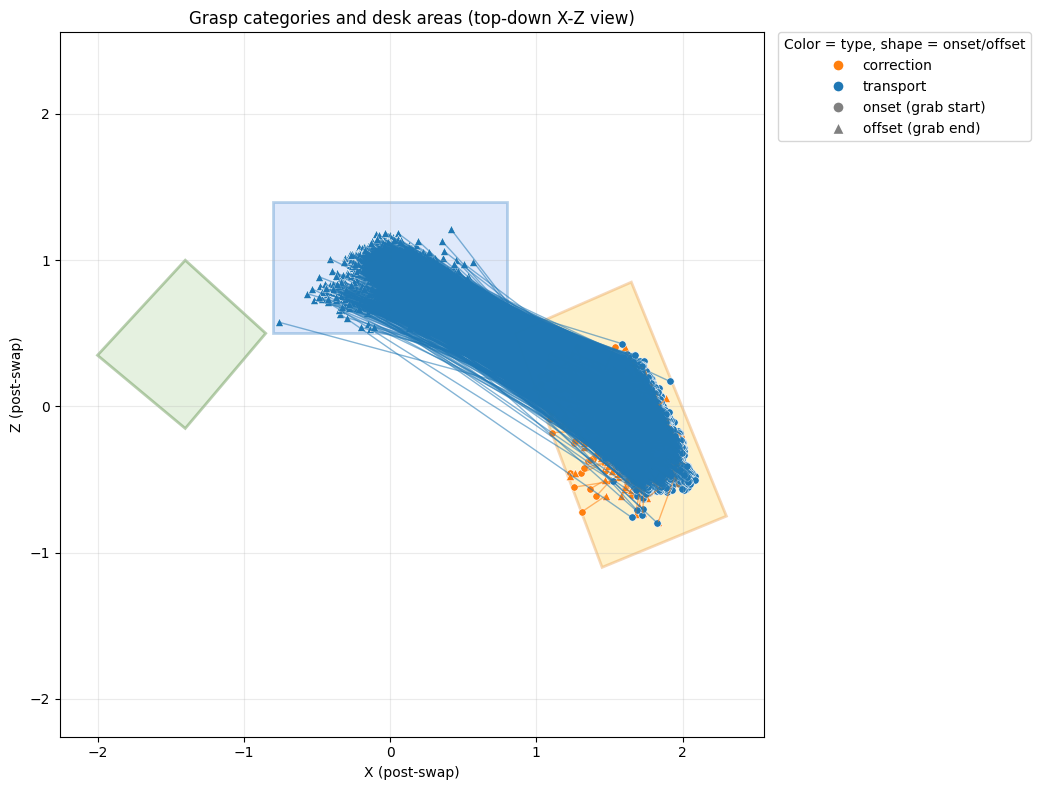

[plot_fixation_areas_fast] Saved plot to: ..\Study_project\data\output\fixation_areas_plot.png


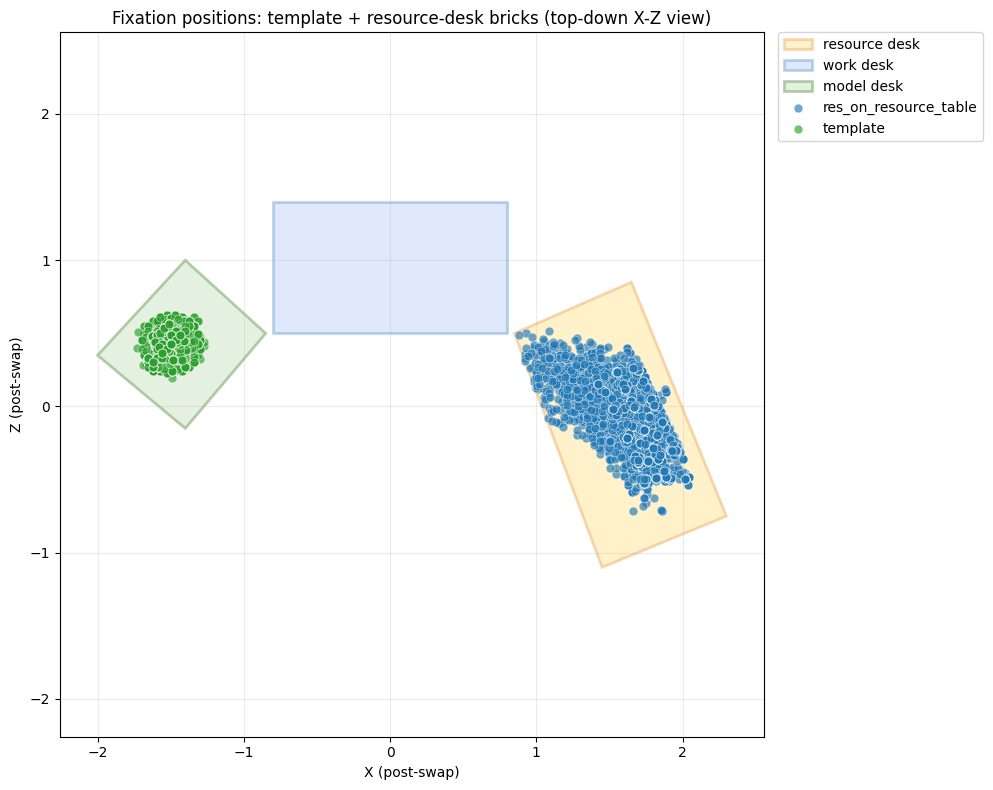

[plot_grasp_areas_all_categories] Saved plot to: ..\Study_project\data\output\grasp_areas_all_categories.png


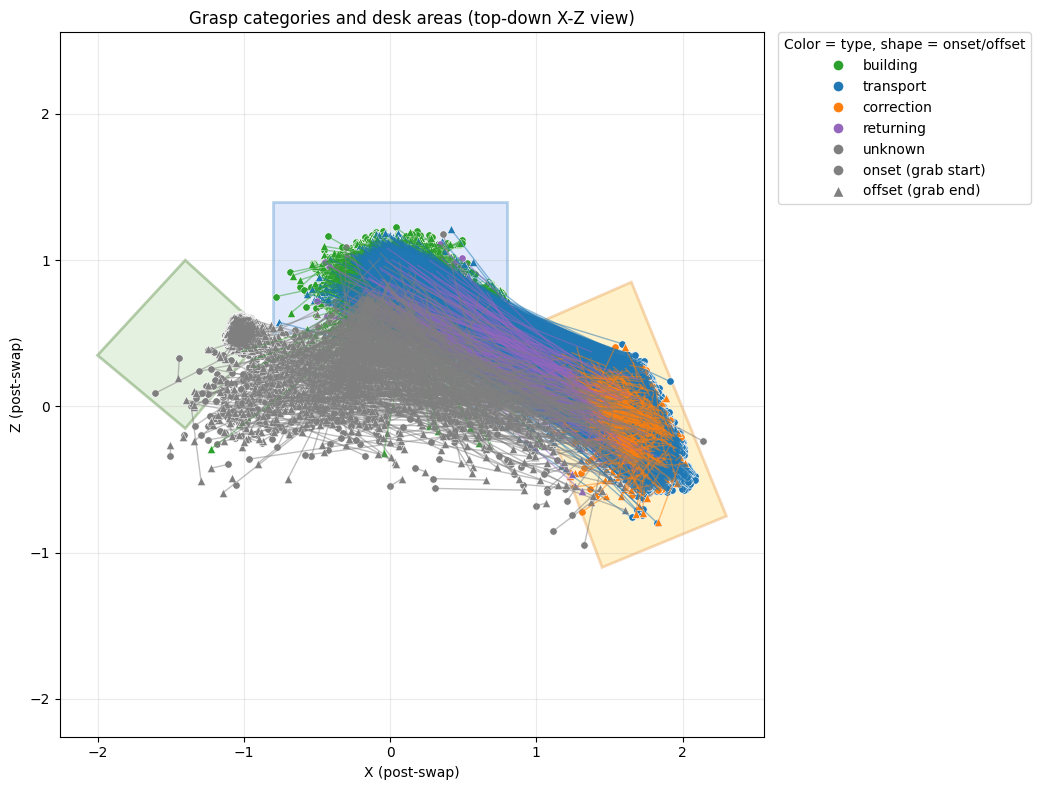

In [59]:
plot_grasp_areas_fast(grasp_events, resource_pos, work_pos, model_pos)
plot_fixation_areas_fast(saved_fixations, resource_pos, work_pos, model_pos)
plot_grasp_areas_all_categories(grasp_events, resource_pos, work_pos, model_pos)

## 15.4 Build the naive fixation-grab tables

In [60]:
naive_matches = naive_match_analysis(brick_fixation_events_df, grasp_events)
naive_matches['participant_id'] = naive_matches['participant_id'].astype(str).str.zfill(3)

naive_group_details = build_naive_group_details(brick_fixation_events_df, grasp_events)

print(naive_matches['group_category'].value_counts())
print()
print('Match rate by group category:')
print(naive_matches.groupby('group_category')['matched'].mean())

group_category
dual           3016
multi_naive    2692
single          727
Name: count, dtype: int64

Match rate by group category:
group_category
dual           0.624668
multi_naive    0.619242
single         0.570839
Name: matched, dtype: float64


In [61]:
# merge event-level mean calibration onto naive_matches, for use as a
# continuous predictor in the model (fit_logistic_mixed_with_calibration)
event_calibration = compute_event_calibration(naive_group_details)
naive_matches = naive_matches.merge(event_calibration, on=TRIAL_GROUP_COLS + ['grab_group_id'], how='left')
print('\nmean_calibration merged:', 'mean_calibration' in naive_matches.columns)
print(naive_matches['mean_calibration'].describe())

# visibility-filtered variant
naive_matches_visible_only = naive_match_analysis(brick_fixation_events_df, grasp_events, require_visible=True)
naive_matches_visible_only['participant_id'] = naive_matches_visible_only['participant_id'].astype(str).str.zfill(3)

naive_group_details_visible_only = build_naive_group_details(brick_fixation_events_df, grasp_events, require_visible=True)

print('=== Match rate WITHOUT visibility filter (current naive_matches) ===')
print(naive_matches.groupby('group_category')['matched'].mean())

print('\n=== Match rate WITH visibility filter (require_visible=True) ===')
print(naive_matches_visible_only.groupby('group_category')['matched'].mean())

naive_matches_calibration_only = naive_match_analysis(
    brick_fixation_events_df, grasp_events, require_calibration=True
)
naive_matches_calibration_only['participant_id'] = naive_matches_calibration_only['participant_id'].astype(str).str.zfill(3)

naive_group_details_calibration_only = build_naive_group_details(
    brick_fixation_events_df, grasp_events, require_calibration=True
)

print('=== Match rate WITHOUT calibration filter ===')
print(naive_matches.groupby('group_category')['matched'].mean())

print('\n=== Match rate WITH calibration filter (both eyes tracked >= 80%) ===')
print(naive_matches_calibration_only.groupby('group_category')['matched'].mean())


mean_calibration merged: True
count    6375.000000
mean        0.530050
std         0.405184
min         0.000000
25%         0.030535
50%         0.606278
75%         0.953562
max         1.000000
Name: mean_calibration, dtype: float64
=== Match rate WITHOUT visibility filter (current naive_matches) ===
group_category
dual           0.624668
multi_naive    0.619242
single         0.570839
Name: matched, dtype: float64

=== Match rate WITH visibility filter (require_visible=True) ===
group_category
dual           0.595094
multi_naive    0.598759
single         0.546089
Name: matched, dtype: float64
=== Match rate WITHOUT calibration filter ===
group_category
dual           0.624668
multi_naive    0.619242
single         0.570839
Name: matched, dtype: float64

=== Match rate WITH calibration filter (both eyes tracked >= 80%) ===
group_category
dual           0.554129
multi_naive    0.449617
single         0.509537
Name: matched, dtype: float64


In [62]:
# Event-level calibration (per fixation set) for VISIBLE_ONLY
# Same computation as for ALL: mean calibration_both_fraction over the
# template fixations in each grab group's accumulated set. Because the
# group details are visibility-filtered, only visible fixations enter the mean.
CALIB_KEYS = TRIAL_GROUP_COLS + ['grab_group_id']

event_calibration_visible = compute_event_calibration(naive_group_details_visible_only)
event_calibration_visible['participant_id'] = event_calibration_visible['participant_id'].astype(str).str.zfill(3)

# Standardize at the EVENT level (one row per grab group), not per grab —
# otherwise multi-grab groups would be over-weighted. One shared scale for
# single/dual/multi keeps the calibration coefficients comparable.
calib_mean = event_calibration_visible['mean_calibration'].mean()
calib_sd = event_calibration_visible['mean_calibration'].std()
event_calibration_visible['calibration_z'] = (
    event_calibration_visible['mean_calibration'] - calib_mean
) / calib_sd


def add_event_calibration(df: pd.DataFrame, event_calibration: pd.DataFrame) -> pd.DataFrame:
    """Merge mean_calibration + calibration_z onto a per-grab dataframe.
    Idempotent: drops any earlier calibration columns (incl. _x/_y
    leftovers) before merging, so re-running the cell is safe."""
    old_cols = [c for c in df.columns if c.startswith(('mean_calibration', 'calibration_z'))]
    out = df.drop(columns=old_cols).copy()
    out['participant_id'] = out['participant_id'].astype(str).str.zfill(3)
    out = out.merge(event_calibration, on=CALIB_KEYS, how='left', validate='many_to_one')
    assert len(out) == len(df), 'merge changed the number of rows'
    out.index = df.index
    return out


naive_matches_visible_only = add_event_calibration(naive_matches_visible_only, event_calibration_visible)

print(f'calibration reference (event level): mean = {calib_mean:.3f}, SD = {calib_sd:.3f}')
print('\nMissing calibration (empty fixation set) per group_category:')
print(naive_matches_visible_only.groupby('group_category')['mean_calibration'].apply(lambda s: s.isna().sum()))

calibration reference (event level): mean = 0.515, SD = 0.413

Missing calibration (empty fixation set) per group_category:
group_category
dual           24
multi_naive    49
single          1
Name: mean_calibration, dtype: int64


## 15.5 Example naive-group timeline

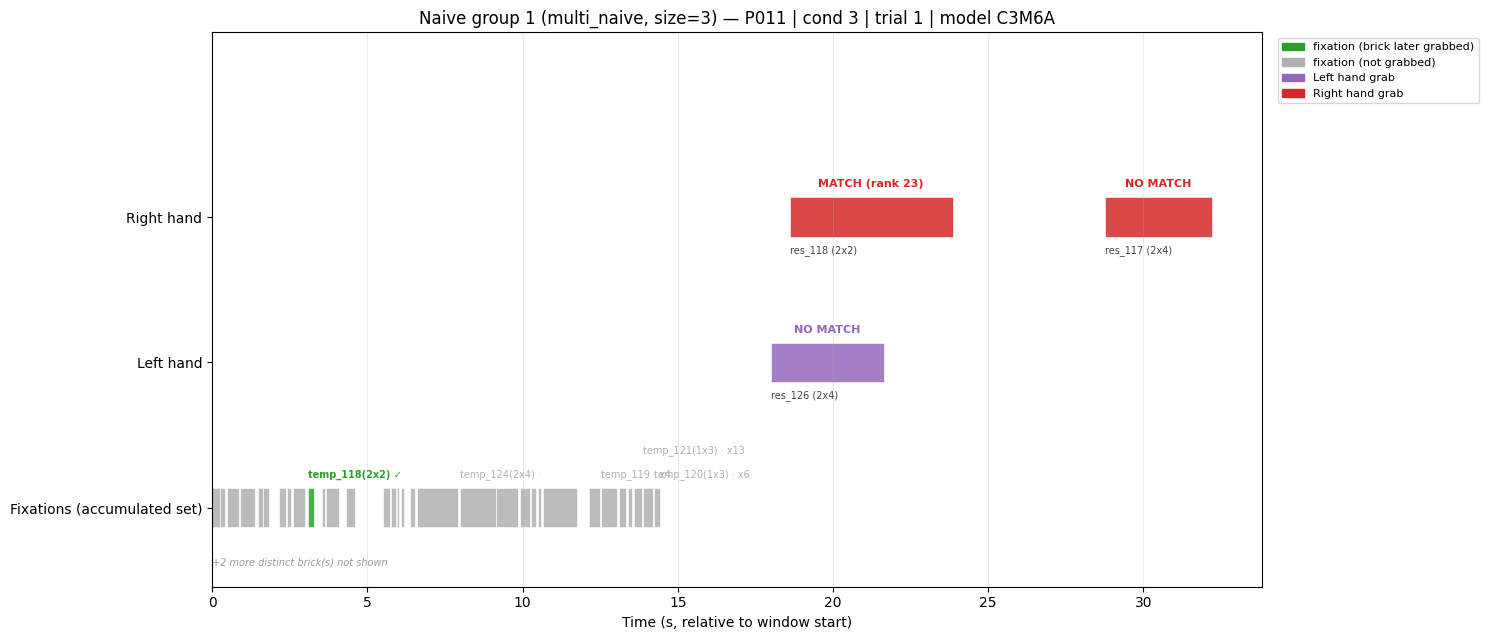

In [63]:
example_trial_key, example_group_id = next(iter(naive_group_details.keys()))
plot_naive_group_timeline(example_trial_key, example_group_id, naive_group_details)

## 15.6 Full naive analysis: permutation tests, models, core descriptive stats

One call per variant (`ALL` = unfiltered, `VISIBLE_ONLY` = visibility-filtered fixation sets). Each call runs: group-size distribution, per-grab-vs-group-level match rate, recency-rank table/plot, matched/unmatched totals, distinct-bricks-vs-fixation-size, match rate by condition/complexity (pooled across categories), grab-group category counts by condition, and the permutation baseline (loose + strict, with null-distribution plots and narrative comparison) plus the
condition-only mixed-effects models (strict + loose).

### 15.6.1 Full Naive Analysis All and Visible Only Configurations


FULL NAIVE ANALYSIS — ALL


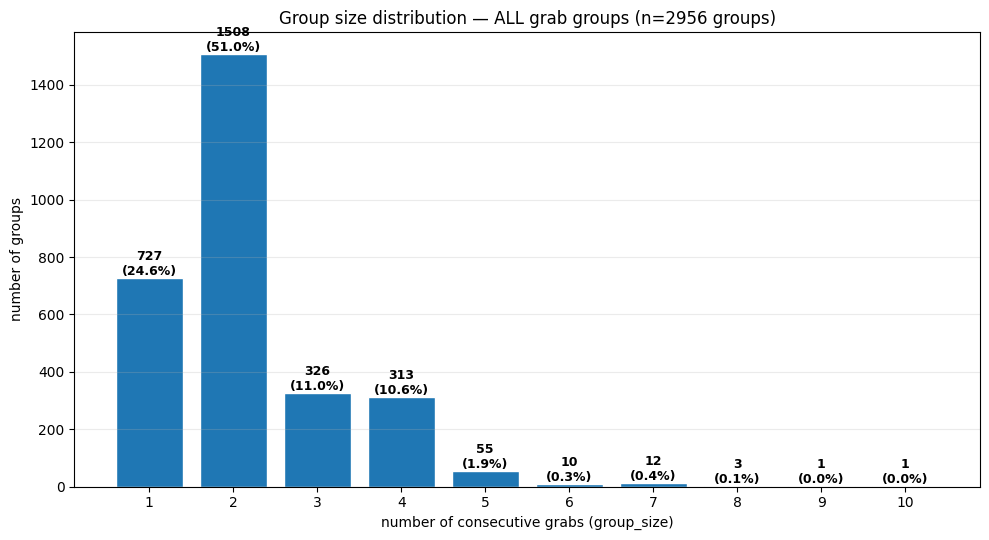

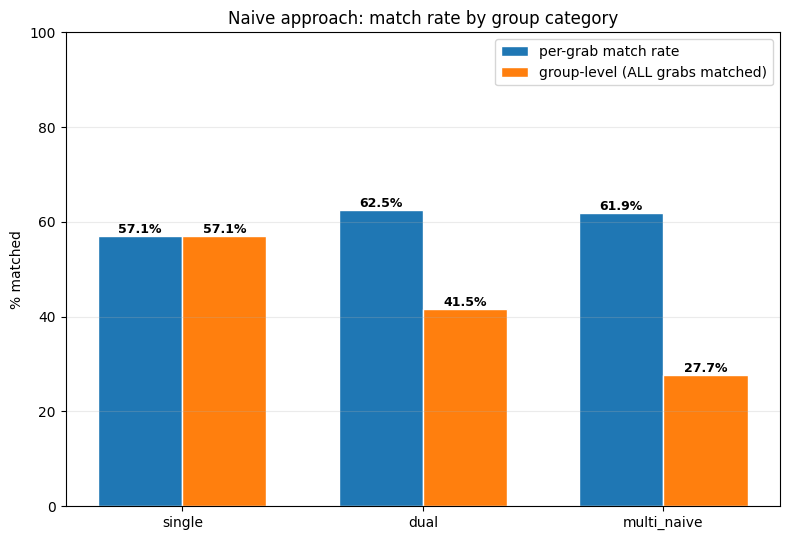

=== Recency rank — exact counts and percentages ===
                                        n_grabs  pct_of_all_grabs  pct_of_matched_grabs
matched_fixation_rank (NaN = no match)                                                 
1.0                                        1413             21.96                 35.63
2.0                                         772             12.00                 19.47
3.0                                         476              7.40                 12.00
4.0                                         323              5.02                  8.14
5.0                                         219              3.40                  5.52
6.0                                         155              2.41                  3.91
7.0                                         122              1.90                  3.08
8.0                                          78              1.21                  1.97
9.0                                          64              0.99   

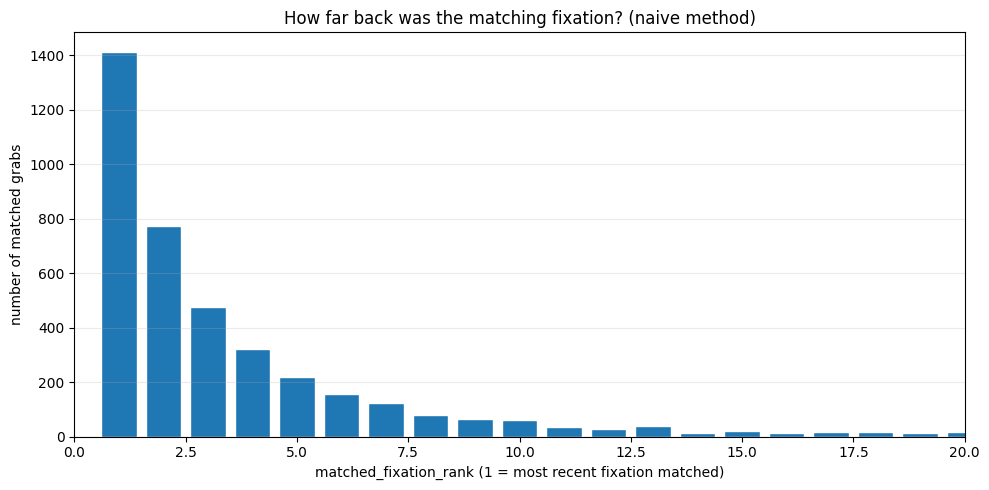

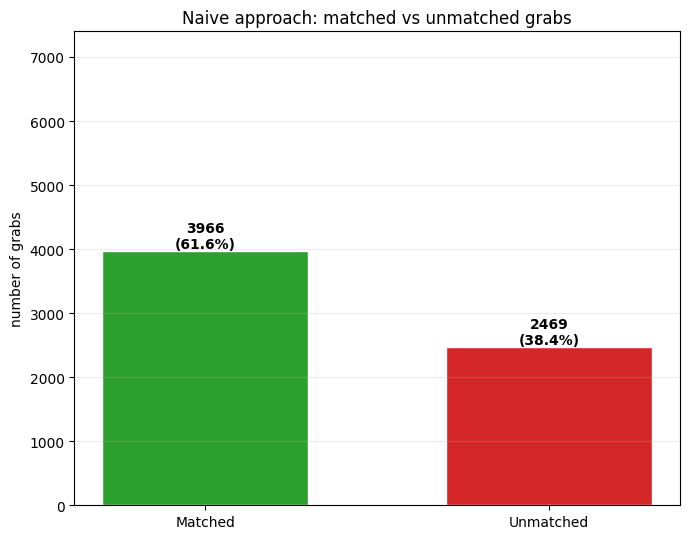

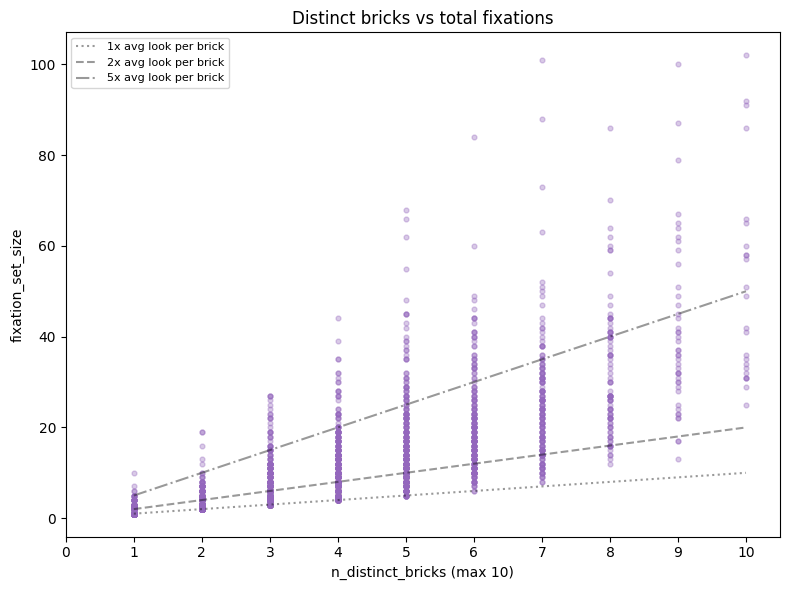

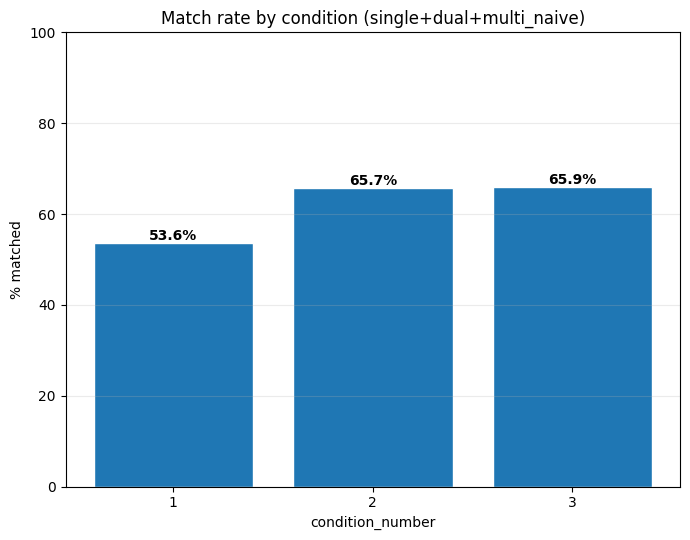

C:\Users\johan\AppData\Local\Temp\ipykernel_17872\3354789934.py:200: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate_by_complexity = naive_subset.groupby('complexity')['matched'].mean().sort_index()


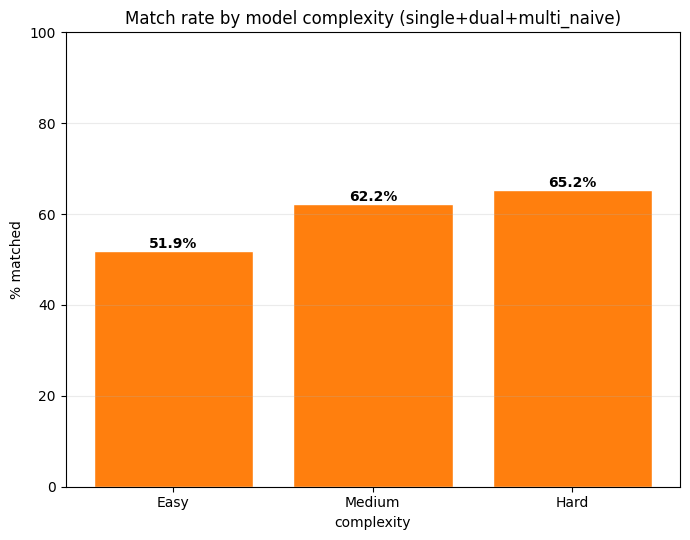

C:\Users\johan\AppData\Local\Temp\ipykernel_17872\3354789934.py:213: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_rate = naive_subset.groupby(['complexity', 'condition_number'])['matched'].mean().unstack()


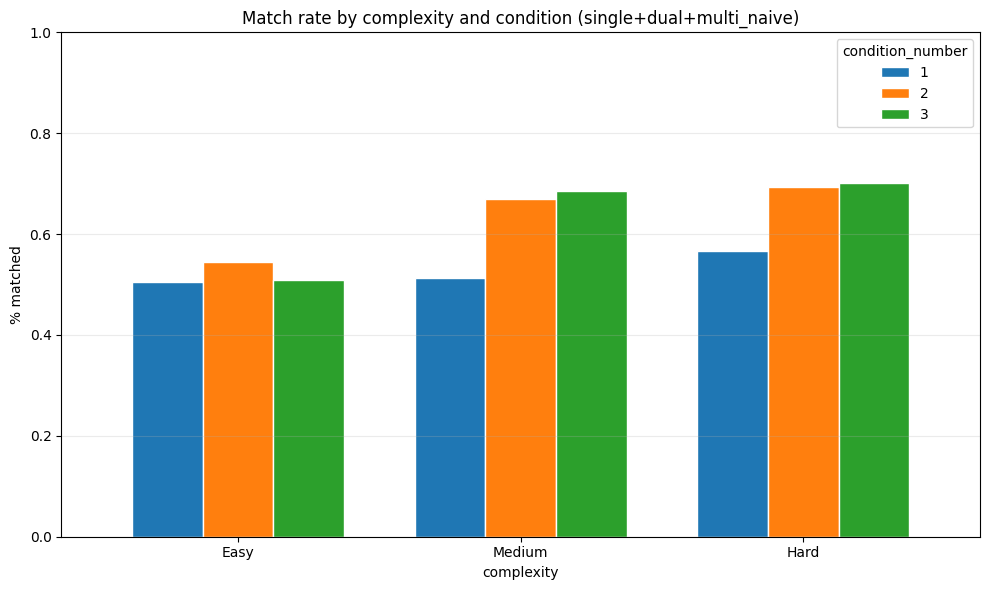

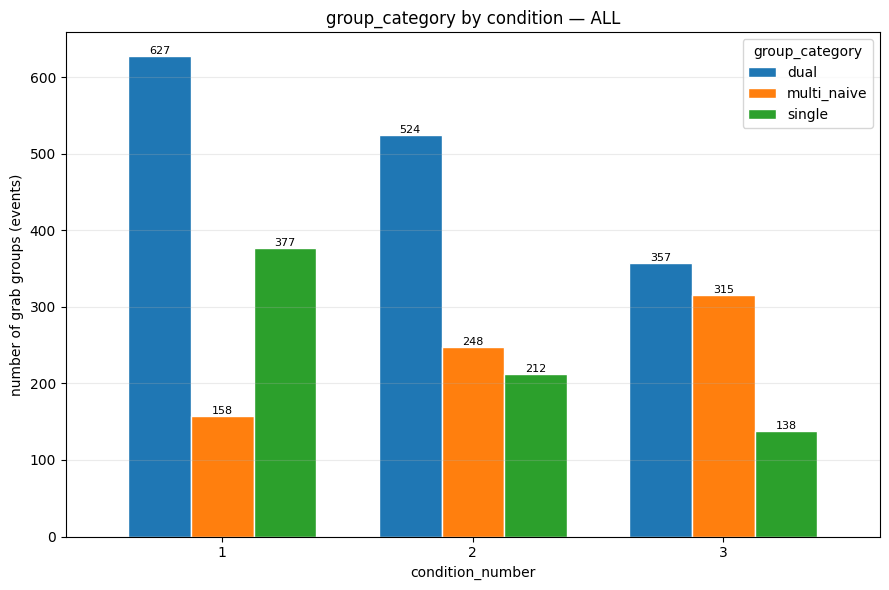

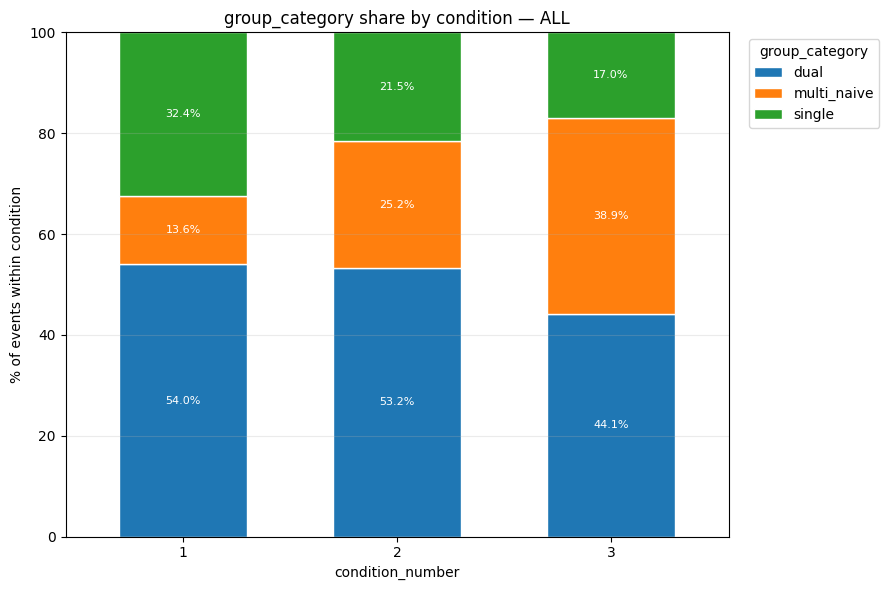

Trials with <2 events (no real shuffle possible within them): 193 of 877


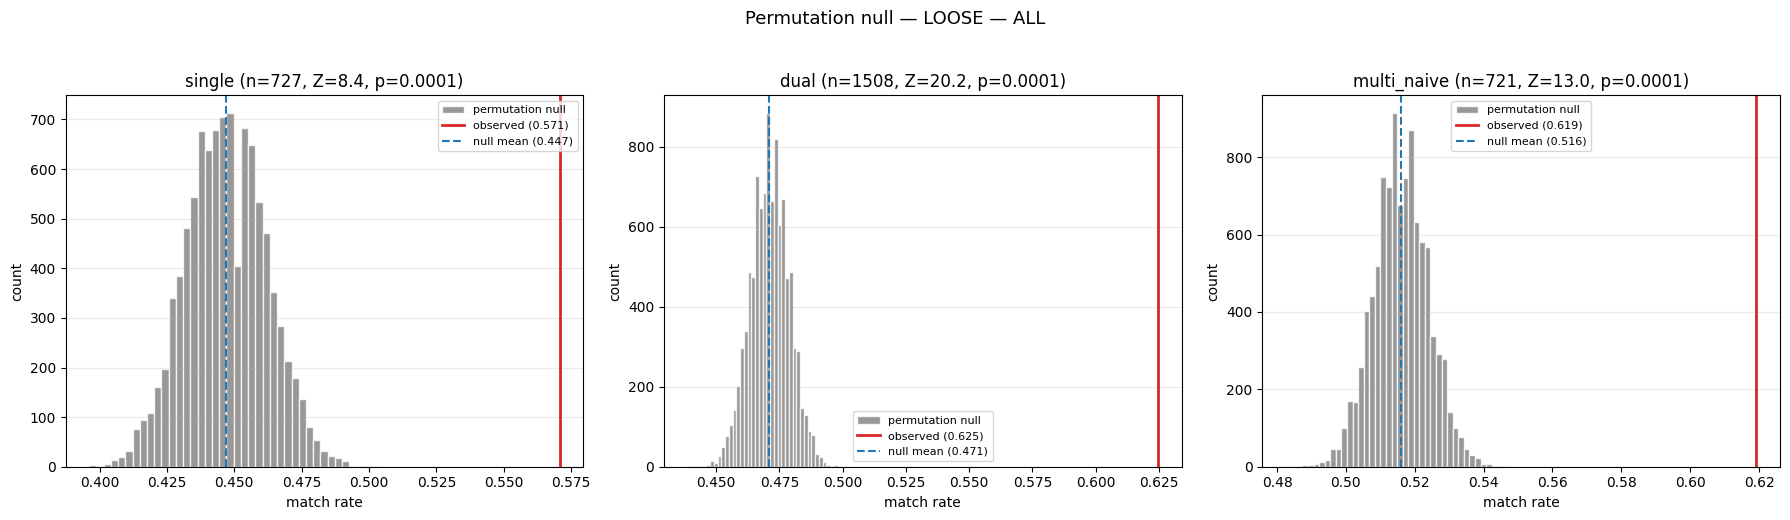


LOOSE vs chance — ALL

SINGLE (n=727):
  Observed correspondence rate = 0.571
  Permutation null: mean = 0.447, SD = 0.015 (based on 10000 permutations, shuffled within participant and trial, preserving event order, event count, grab timing, and selected bricks)
  Observed value falls at the 100.0th percentile of the null (z = 8.39, p = 0.0001)
  --> Fixation-selection correspondence significantly exceeds what is expected by chance.

DUAL (n=1508):
  Observed correspondence rate = 0.625
  Permutation null: mean = 0.471, SD = 0.008 (based on 10000 permutations, shuffled within participant and trial, preserving event order, event count, grab timing, and selected bricks)
  Observed value falls at the 100.0th percentile of the null (z = 20.20, p = 0.0001)
  --> Fixation-selection correspondence significantly exceeds what is expected by chance.

MULTI_NAIVE (n=721):
  Observed correspondence rate = 0.619
  Permutation null: mean = 0.516, SD = 0.008 (based on 10000 permutations, shuffled wi

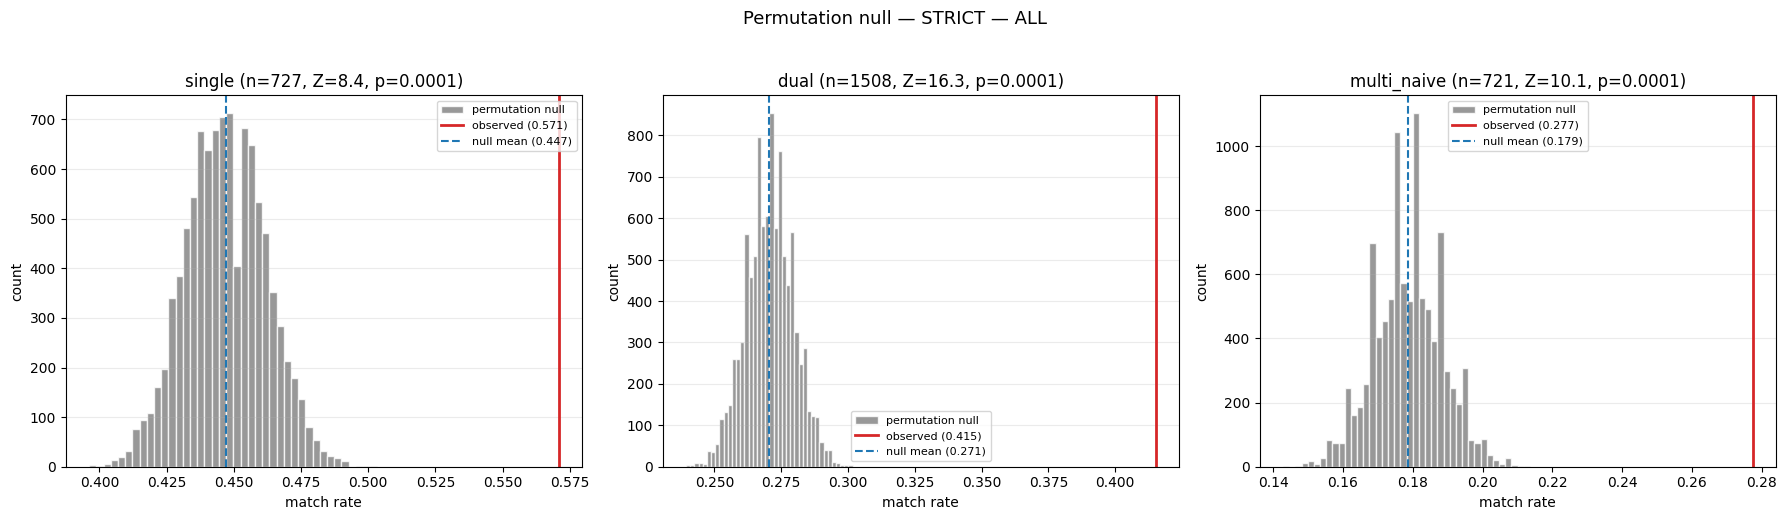


STRICT vs chance — ALL

SINGLE (n=727):
  Observed correspondence rate = 0.571
  Permutation null: mean = 0.447, SD = 0.015 (based on 10000 permutations, shuffled within participant and trial, preserving event order, event count, grab timing, and selected bricks)
  Observed value falls at the 100.0th percentile of the null (z = 8.39, p = 0.0001)
  --> Fixation-selection correspondence significantly exceeds what is expected by chance.

DUAL (n=1508):
  Observed correspondence rate = 0.415
  Permutation null: mean = 0.271, SD = 0.009 (based on 10000 permutations, shuffled within participant and trial, preserving event order, event count, grab timing, and selected bricks)
  Observed value falls at the 100.0th percentile of the null (z = 16.31, p = 0.0001)
  --> Fixation-selection correspondence significantly exceeds what is expected by chance.

MULTI_NAIVE (n=721):
  Observed correspondence rate = 0.277
  Permutation null: mean = 0.179, SD = 0.010 (based on 10000 permutations, shuffled w

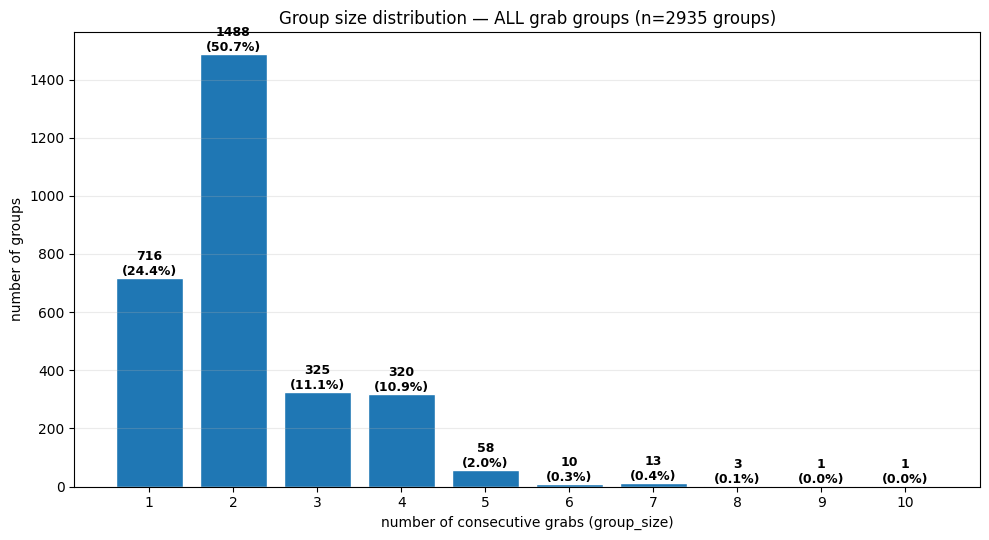

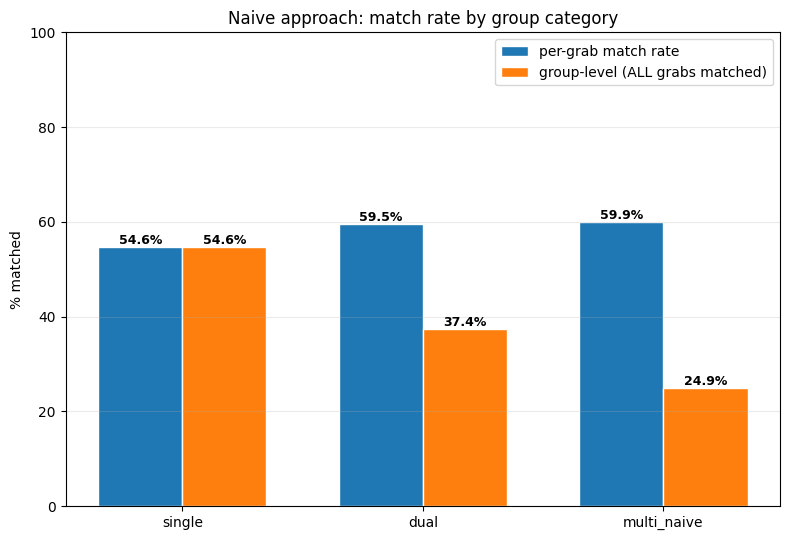

=== Recency rank — exact counts and percentages ===
                                        n_grabs  pct_of_all_grabs  pct_of_matched_grabs
matched_fixation_rank (NaN = no match)                                                 
1.0                                        1422             22.11                 37.40
2.0                                         757             11.77                 19.91
3.0                                         458              7.12                 12.05
4.0                                         307              4.77                  8.07
5.0                                         201              3.13                  5.29
6.0                                         129              2.01                  3.39
7.0                                         108              1.68                  2.84
8.0                                          61              0.95                  1.60
9.0                                          56              0.87   

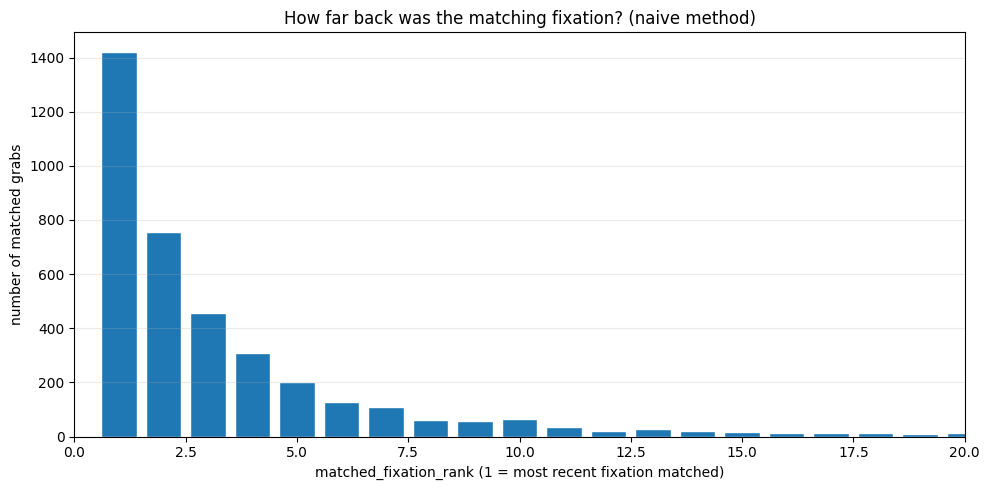

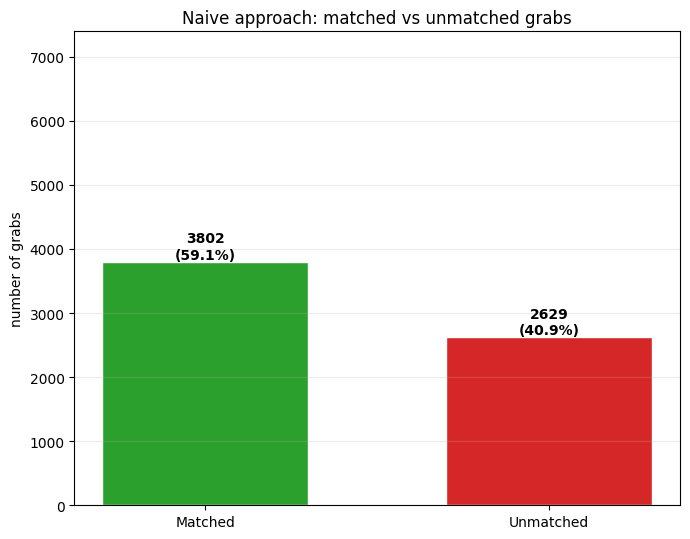

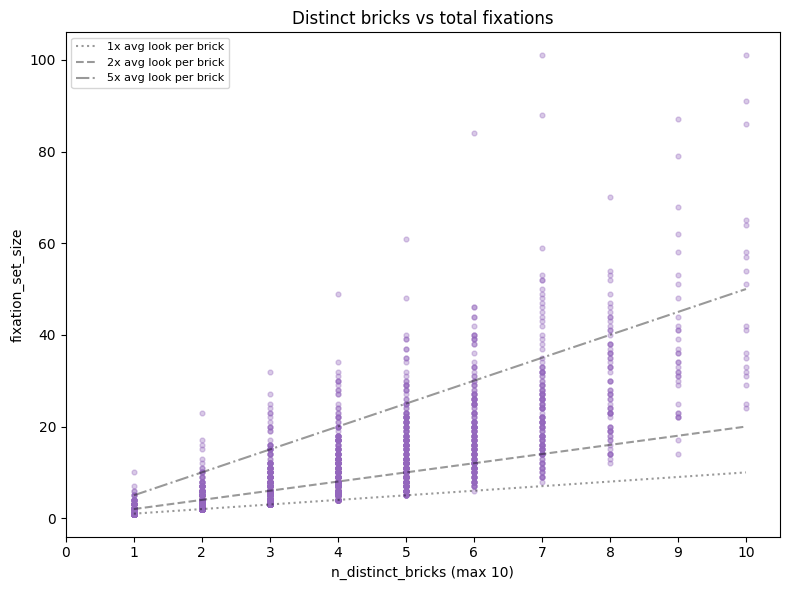

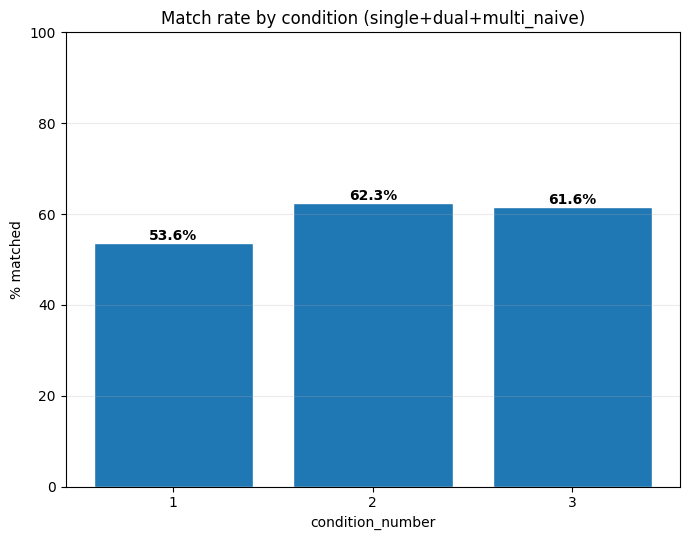

C:\Users\johan\AppData\Local\Temp\ipykernel_17872\3354789934.py:200: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate_by_complexity = naive_subset.groupby('complexity')['matched'].mean().sort_index()


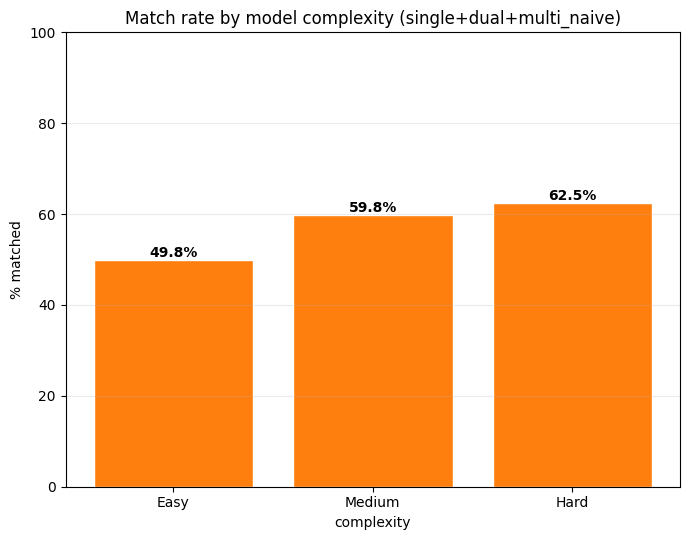

C:\Users\johan\AppData\Local\Temp\ipykernel_17872\3354789934.py:213: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_rate = naive_subset.groupby(['complexity', 'condition_number'])['matched'].mean().unstack()


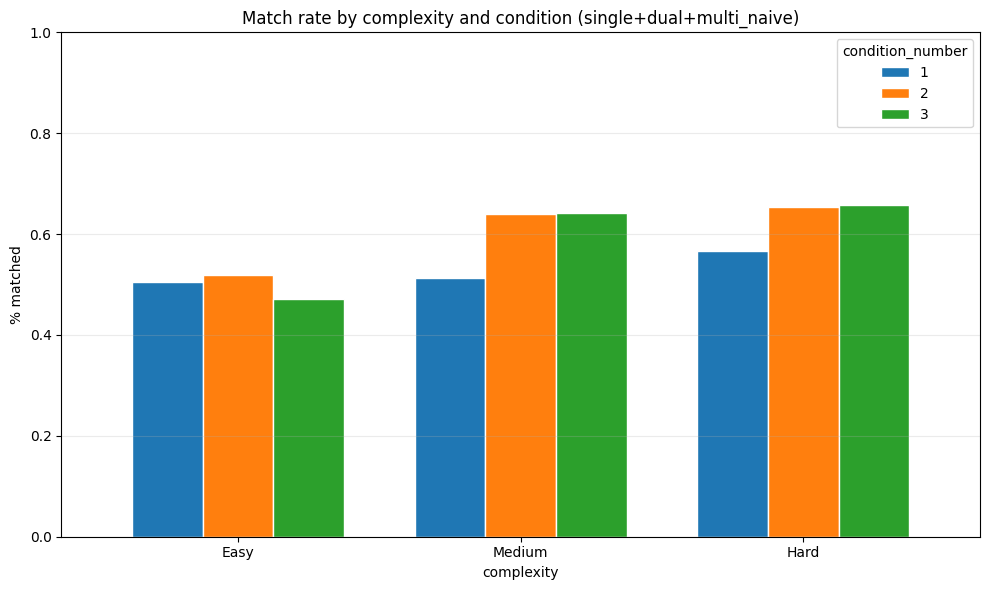

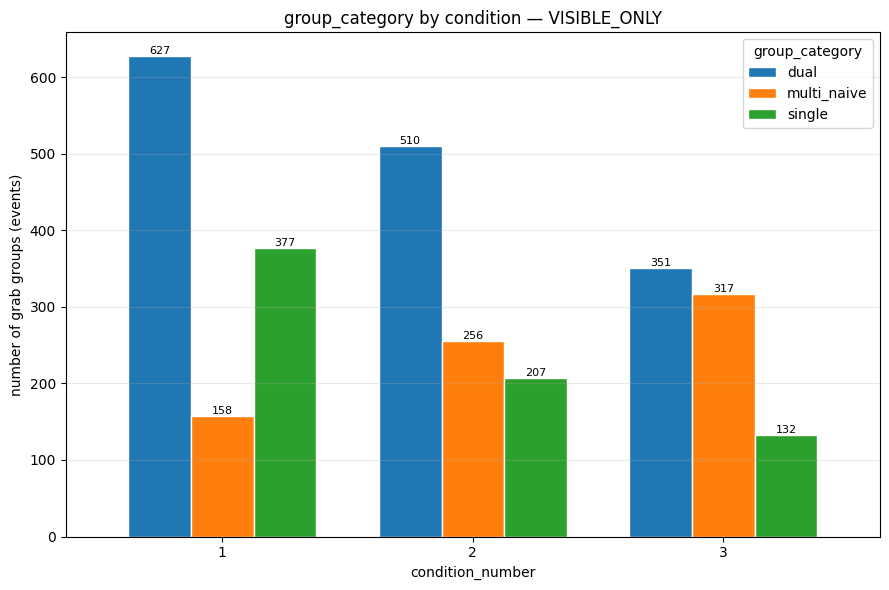

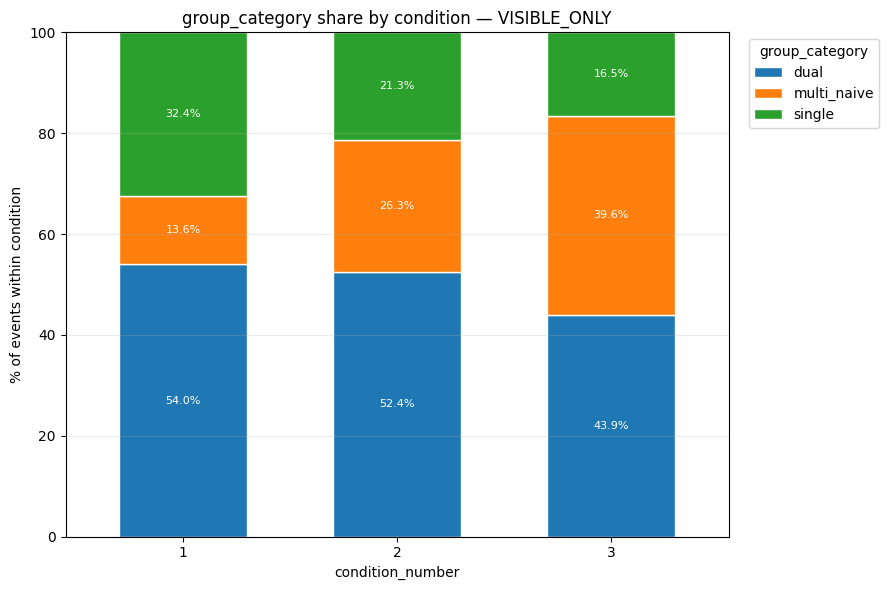

Trials with <2 events (no real shuffle possible within them): 198 of 876


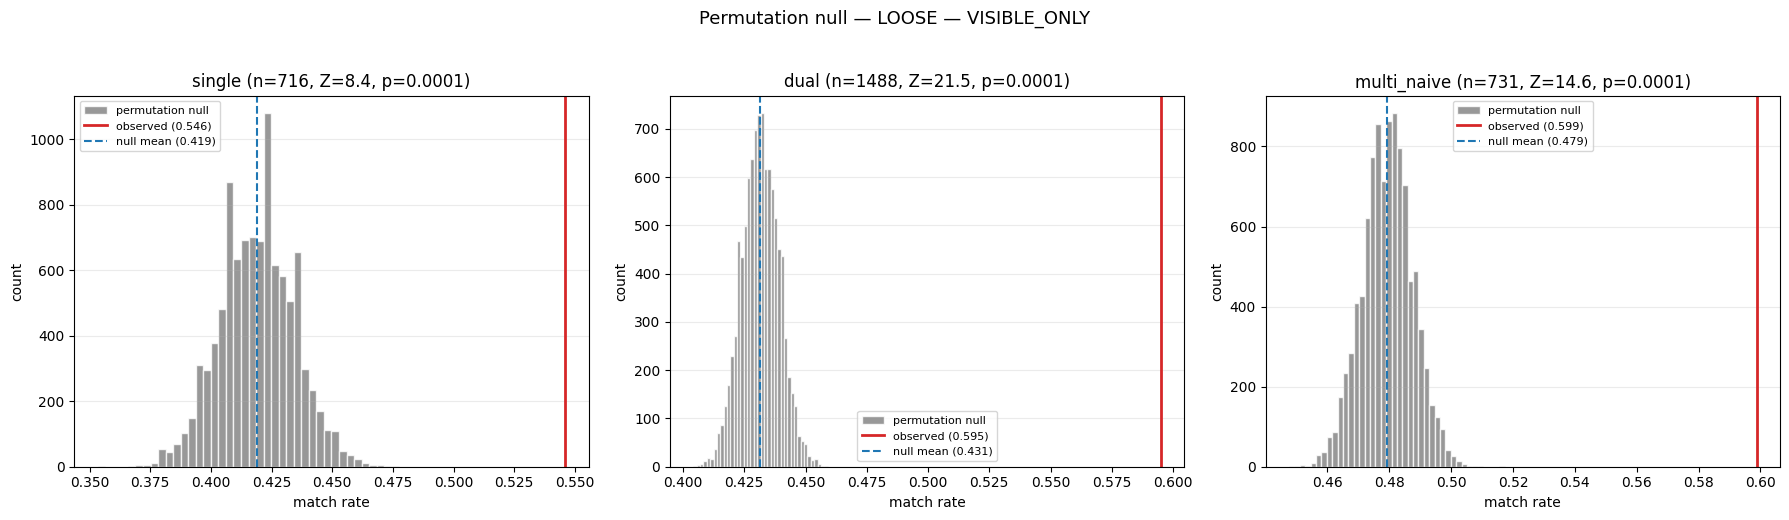


LOOSE vs chance — VISIBLE_ONLY

SINGLE (n=716):
  Observed correspondence rate = 0.546
  Permutation null: mean = 0.419, SD = 0.015 (based on 10000 permutations, shuffled within participant and trial, preserving event order, event count, grab timing, and selected bricks)
  Observed value falls at the 100.0th percentile of the null (z = 8.35, p = 0.0001)
  --> Fixation-selection correspondence significantly exceeds what is expected by chance.

DUAL (n=1488):
  Observed correspondence rate = 0.595
  Permutation null: mean = 0.431, SD = 0.008 (based on 10000 permutations, shuffled within participant and trial, preserving event order, event count, grab timing, and selected bricks)
  Observed value falls at the 100.0th percentile of the null (z = 21.47, p = 0.0001)
  --> Fixation-selection correspondence significantly exceeds what is expected by chance.

MULTI_NAIVE (n=731):
  Observed correspondence rate = 0.599
  Permutation null: mean = 0.479, SD = 0.008 (based on 10000 permutations, sh

In [ ]:
results_all = run_full_naive_analysis(naive_matches, naive_group_details, label='ALL')
results_visible_only = run_full_naive_analysis(naive_matches_visible_only, naive_group_details_visible_only, label='VISIBLE_ONLY')

### 15.6.2 Extended descriptive statistics


These break the data down along dimensions.
`run_full_naive_analysis` does NOT cover: 
* complexity as its own axis (not just pooled into the condition-only view)
* match rate split BY group_category (single/dual/multi_naive shown as separate bars, not pooled)
* dwell time
* raw grasp-type distribution (on `grasp_events`, not `naive_matches`)
* `group_category` broken down by complexity specifically (the condition-by-`group_category` breakdown is already inside 15.6 for both ALL/VISIBLE_ONLY, so only the complexity half is repeated here)

#### Grabs and events by condition x complexity

=== Grabs: counts ===
complexity           1     2     3  total
condition_number                         
1                  432   731  1043   2206
2                  411   731  1029   2171
3                  395   727   936   2058
total             1238  2189  3008   6435

=== Grabs: % of grand total ===
complexity            1      2      3   total
condition_number                             
1                  6.71  11.36  16.21   34.28
2                  6.39  11.36  15.99   33.74
3                  6.14  11.30  14.55   31.98
total             19.24  34.02  46.74  100.00

=== Grabs: % within condition ===
complexity            1      2      3
condition_number                     
1                 19.58  33.14  47.28
2                 18.93  33.67  47.40
3                 19.19  35.33  45.48


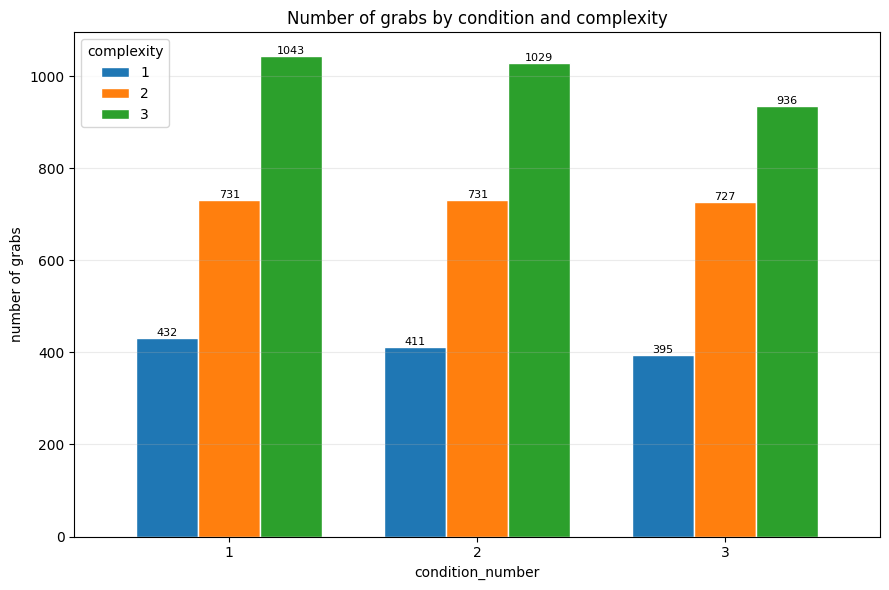

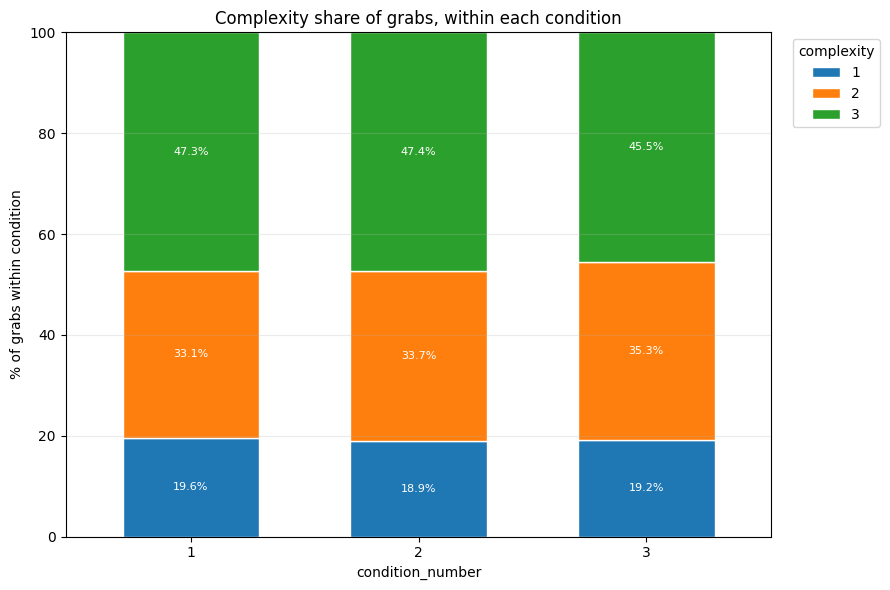

In [ ]:
naive_matches_c = add_complexity(naive_matches)

#  individual grabs 
counts, pct_total, pct_within = counts_and_pct_table(naive_matches_c, ['condition_number', 'complexity'])
print('=== Grabs: counts ===')
print(counts)
print('\n=== Grabs: % of grand total ===')
print(pct_total)
print('\n=== Grabs: % within condition ===')
print(pct_within)

plot_grouped_bar(
    counts.drop(index='total', errors='ignore').drop(columns='total', errors='ignore'),
    'condition_number', 'number of grabs', 'Number of grabs by condition and complexity',
    'complexity', 'grabs_by_condition_complexity.png',
)
plot_stacked_pct_bar(
    pct_within, 'condition_number', '% of grabs within condition',
    'Complexity share of grabs, within each condition', 'complexity', 'grabs_by_condition_complexity_pct.png',
)


=== Events: counts ===
complexity          1     2     3  total
condition_number                        
1                 156   405   601   1162
2                 128   337   519    984
3                 114   297   399    810
total             398  1039  1519   2956

=== Events: % of grand total ===
complexity            1      2      3   total
condition_number                             
1                  5.28  13.70  20.33   39.31
2                  4.33  11.40  17.56   33.29
3                  3.86  10.05  13.50   27.40
total             13.46  35.15  51.39  100.00

=== Events: % within condition ===
complexity            1      2      3
condition_number                     
1                 13.43  34.85  51.72
2                 13.01  34.25  52.74
3                 14.07  36.67  49.26


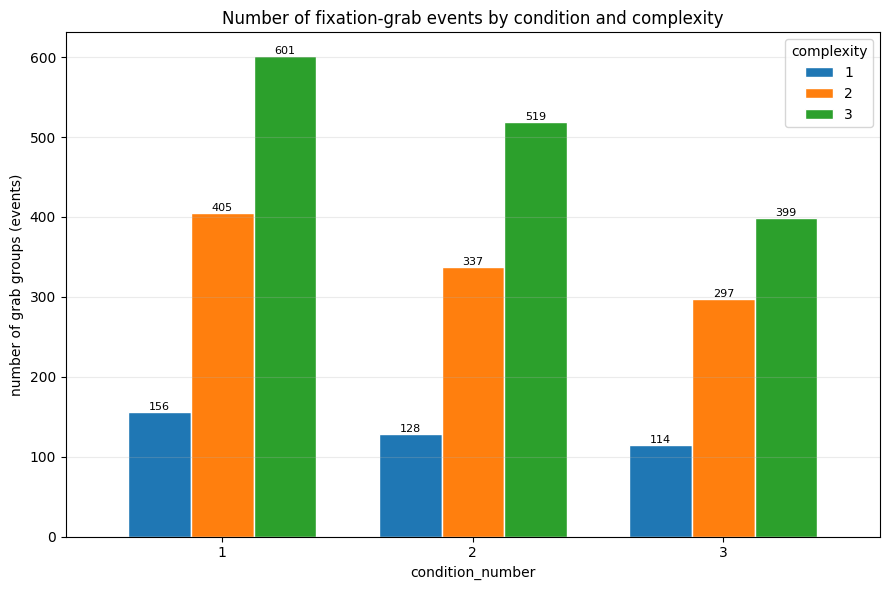

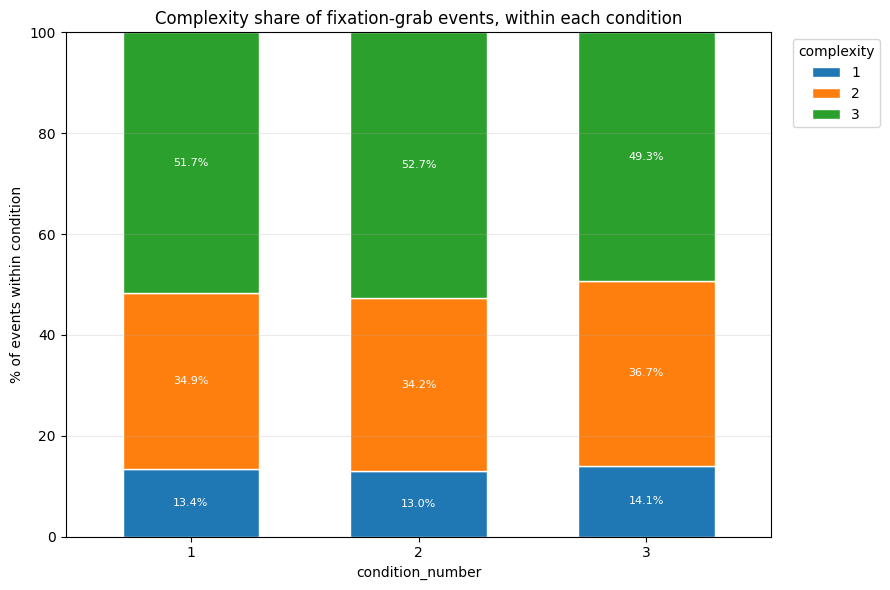

In [ ]:
# fixation-grab EVENTS (grab groups, deduplicated)
naive_groups_c = naive_matches_c.drop_duplicates(subset=TRIAL_GROUP_COLS + ['grab_group_id'])

counts_e, pct_total_e, pct_within_e = counts_and_pct_table(naive_groups_c, ['condition_number', 'complexity'])
print('=== Events: counts ===')
print(counts_e)
print('\n=== Events: % of grand total ===')
print(pct_total_e)
print('\n=== Events: % within condition ===')
print(pct_within_e)

plot_grouped_bar(
    counts_e.drop(index='total', errors='ignore').drop(columns='total', errors='ignore'),
    'condition_number', 'number of grab groups (events)',
    'Number of fixation-grab events by condition and complexity',
    'complexity', 'events_by_condition_complexity.png',
)
plot_stacked_pct_bar(
    pct_within_e, 'condition_number', '% of events within condition',
    'Complexity share of fixation-grab events, within each condition',
    'complexity', 'events_by_condition_complexity_pct.png',
)


#### Match rate by condition and by complexity, split by group_category

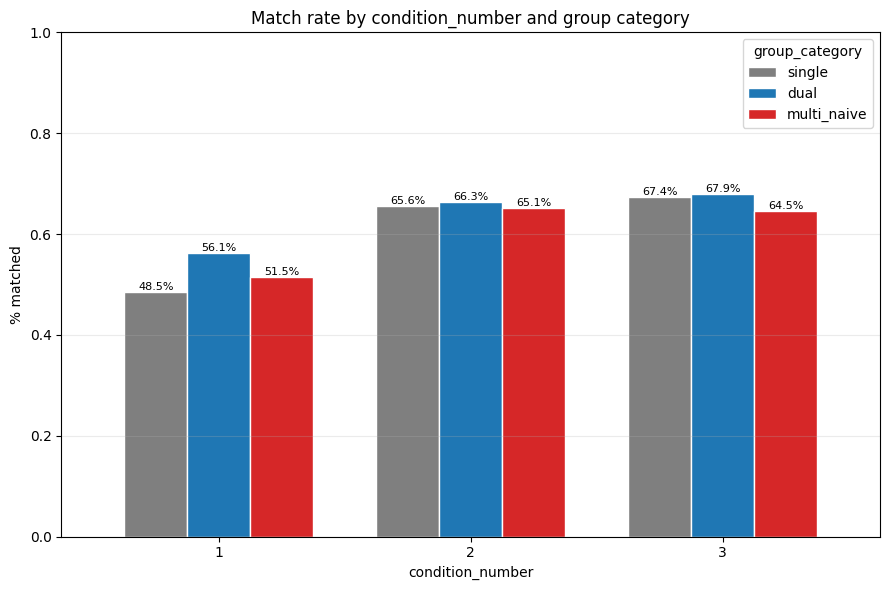

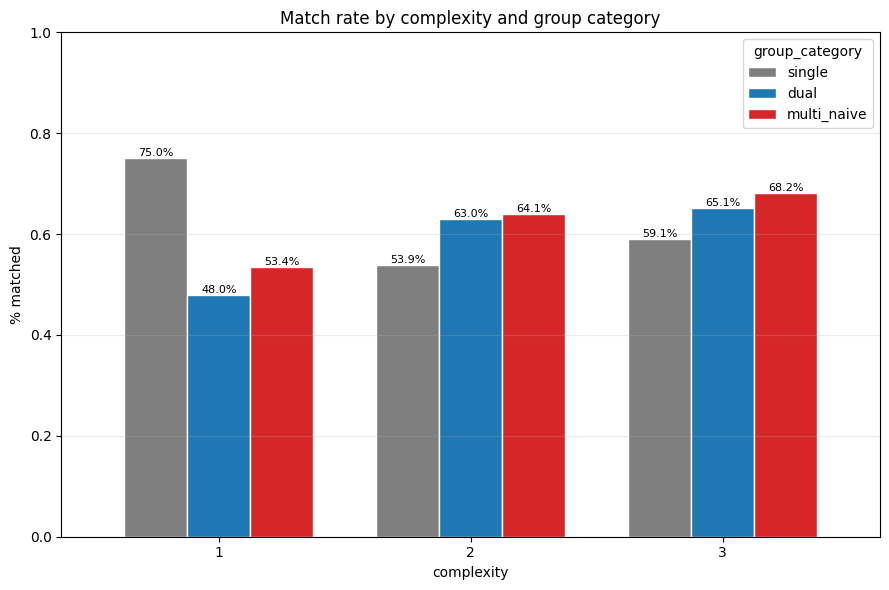

In [ ]:
_ = plot_match_rate_by_category(naive_matches_c, 'condition_number', 'condition_number', 'match_rate_by_condition_category.png')
_ = plot_match_rate_by_category(naive_matches_c, 'complexity', 'complexity', 'match_rate_by_complexity_category.png')


#### Dwell time

Groups with computable dwell time: 2936
Groups excluded (no preceding fixation): 20
Mean dwell time (ms), by condition x complexity:
complexity             1        2        3
condition_number                          
1                 7351.5   9223.7  13384.5
2                 6825.5  11566.2  15002.0
3                 7123.8  13006.3  15642.1


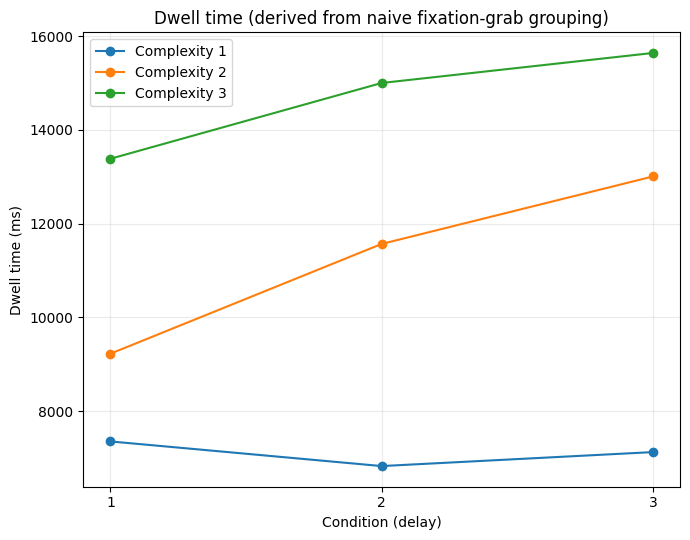

In [ ]:
dwell_df = compute_dwell_times(naive_group_details)
dwell_by_cond_complexity = plot_dwell_time(dwell_df)

#### Grasp type distribution by condition and complexity

=== Grasp type by condition: counts ===
grasp_type        building  correction  returning  transport  unknown  total
condition_number                                                            
1                     2856         297         57       2085     2522   7817
2                     2563         188         43       2098     2708   7600
3                     2306         151         27       2021     2273   6778
total                 7725         636        127       6204     7503  22195

=== Grasp type by condition: % within condition ===
grasp_type        building  correction  returning  transport  unknown
condition_number                                                     
1                    36.54        3.80       0.73      26.67    32.26
2                    33.72        2.47       0.57      27.61    35.63
3                    34.02        2.23       0.40      29.82    33.53


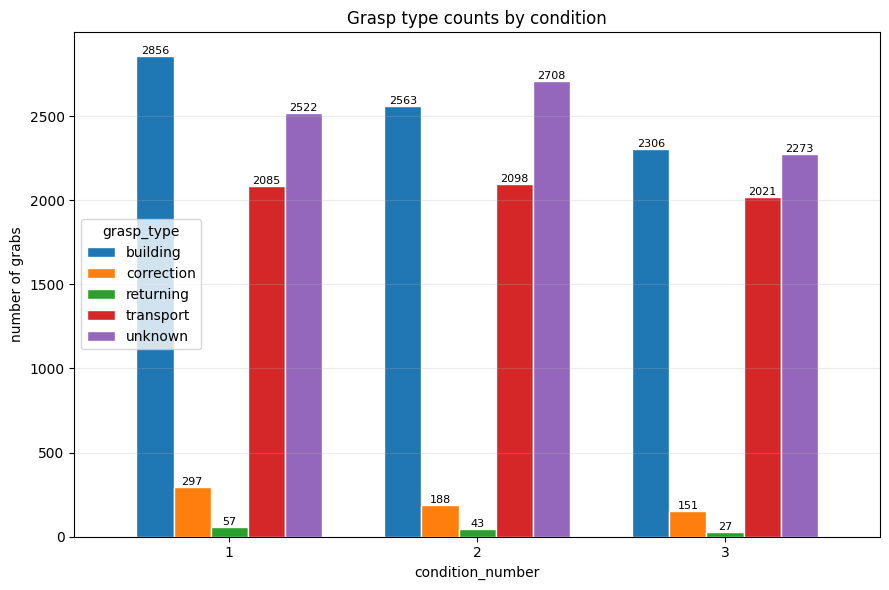

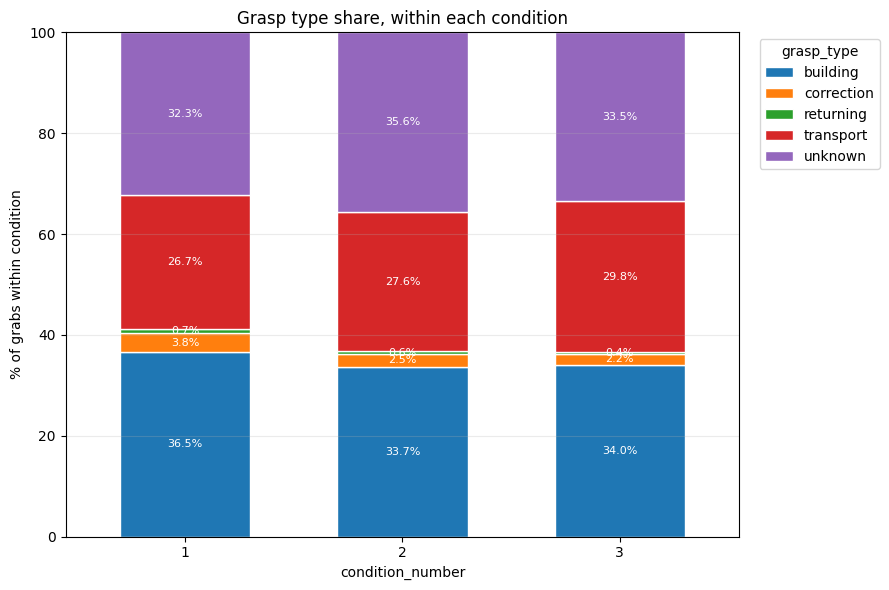

In [ ]:
grasp_events_c = add_complexity(grasp_events)

#  by condition 
counts_gt, pct_total_gt, pct_within_gt = counts_and_pct_table(grasp_events_c, ['condition_number', 'grasp_type'])
print('=== Grasp type by condition: counts ===')
print(counts_gt)
print('\n=== Grasp type by condition: % within condition ===')
print(pct_within_gt)

plot_grouped_bar(
    counts_gt.drop(index='total', errors='ignore').drop(columns='total', errors='ignore'),
    'condition_number', 'number of grabs', 'Grasp type counts by condition',
    'grasp_type', 'grasp_type_by_condition.png',
)
plot_stacked_pct_bar(
    pct_within_gt, 'condition_number', '% of grabs within condition',
    'Grasp type share, within each condition', 'grasp_type', 'grasp_type_by_condition_pct.png',
)

#### group_category by complexity (condition half already covered in 15.6)

=== group_category by complexity: counts ===
group_category  dual  multi_naive  single  total
complexity                                      
1                174          220       4    398
2                492          252     295   1039
3                842          249     428   1519
total           1508          721     727   2956

=== group_category by complexity: % within complexity ===
group_category   dual  multi_naive  single
complexity                                
1               43.72        55.28    1.01
2               47.35        24.25   28.39
3               55.43        16.39   28.18


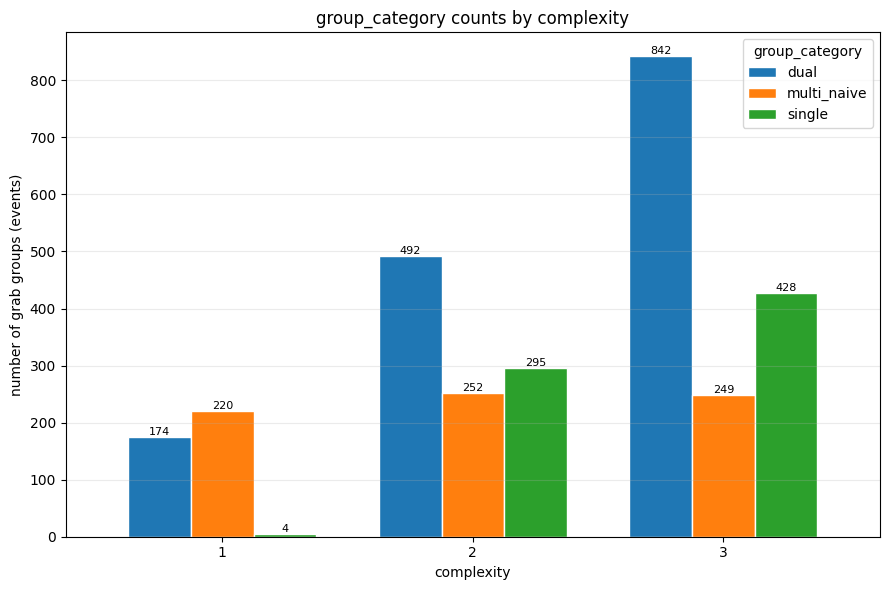

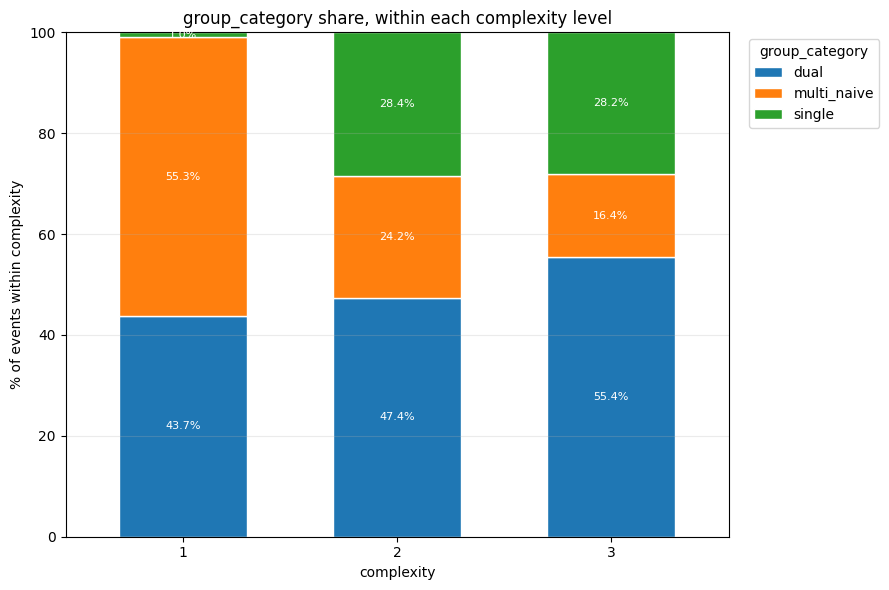

In [ ]:
# by complexity (naive_groups_c built above, in the "grabs and events" cells)
counts_cat_x, pct_total_cat_x, pct_within_cat_x = counts_and_pct_table(naive_groups_c, ['complexity', 'group_category'])
print('=== group_category by complexity: counts ===')
print(counts_cat_x)
print('\n=== group_category by complexity: % within complexity ===')
print(pct_within_cat_x)

plot_grouped_bar(
    counts_cat_x.drop(index='total', errors='ignore').drop(columns='total', errors='ignore'),
    'complexity', 'number of grab groups (events)', 'group_category counts by complexity',
    'group_category', 'group_category_by_complexity.png',
)
plot_stacked_pct_bar(
    pct_within_cat_x, 'complexity', '% of events within complexity',
    'group_category share, within each complexity level', 'group_category', 'group_category_by_complexity_pct.png',
)

### 15.6.3 Permutation Procedure for Computing p_chance of i

The goal is to compute, for each observation, the permutation‑based chance probability that the selected brick appears in a randomly permuted fixation set.

In [ ]:
def compute_p_chance(df: pd.DataFrame, smoothing: float = 0.5) -> pd.DataFrame:
    """Leave-one-out permutation baseline, computed exactly (no random draws).

    For each grab: its own group's fixation set is replaced by the set of
    every OTHER grab group from the same trial in `df`.
        k = number of those other sets containing the grabbed brick
        m = number of other groups in the trial
        p_chance = (k + smoothing) / (m + 1)

    Donors come only from `df` itself, so passing the single / dual / multi
    dataframes separately keeps the permutation separate per category.
    Each grab gets its own p_chance (k depends on the grabbed brick); grabs
    of one group share the same donor sets.

    Dropped (with a printout): grabs whose own fixation set is empty, and
    grabs in trials without any other non-empty group (m = 0).
    """
    df = df.copy()
    df['fset_'] = df['fixation_set'].apply(
        lambda s: frozenset(s) if isinstance(s, (list, tuple, set, frozenset, np.ndarray)) else frozenset()
    )
    group_keys = TRIAL_GROUP_COLS + ['grab_group_id']

    # One donor set per GROUP (not per grab), empty sets excluded from the pool
    groups = df.drop_duplicates(subset=group_keys)
    groups = groups[groups['fset_'].map(len) > 0]
    donor_sets = {
        trial_key: list(zip(g['grab_group_id'], g['fset_']))
        for trial_key, g in groups.groupby(TRIAL_GROUP_COLS, dropna=False, observed=True)
    }

    k_vals, m_vals = [], []
    for trial_key, gid, grabbed in zip(
        df[TRIAL_GROUP_COLS].itertuples(index=False, name=None),
        df['grab_group_id'],
        df['grabbed_id'],
    ):
        others = [fset for other_gid, fset in donor_sets.get(trial_key, []) if other_gid != gid]
        m_vals.append(len(others))
        k_vals.append(sum(grabbed in fset for fset in others))

    df['k_chance'] = k_vals
    df['m_chance'] = m_vals

    empty_own = df['fset_'].map(len) == 0
    no_donor = df['m_chance'] == 0
    print(f'rows in: {len(df)} | dropped empty own set: {empty_own.sum()} | '
          f'dropped m = 0 (no other group in trial): {(no_donor & ~empty_own).sum()}')

    df = df[~empty_own & ~no_donor].drop(columns='fset_')
    df['p_chance'] = (df['k_chance'] + smoothing) / (df['m_chance'] + 1)
    df['logit_chance'] = np.log(df['p_chance'] / (1 - df['p_chance']))
    print(f"rows out: {len(df)} | m_chance median = {df['m_chance'].median():.0f}, "
          f"min = {df['m_chance'].min()}, max = {df['m_chance'].max()}")
    return df

#### Permutation for ALL splitted for groups

In [ ]:
df_single_all = compute_p_chance(naive_matches[naive_matches['group_category'] == 'single'].copy())
df_dual_all   = compute_p_chance(naive_matches[naive_matches['group_category'] == 'dual'].copy())
df_multi_all  = compute_p_chance(naive_matches[naive_matches['group_category'] == 'multi_naive'].copy())

rows in: 727 | dropped empty own set: 0 | dropped m = 0 (no other group in trial): 196
rows out: 531 | m_chance median = 3, min = 1, max = 9
rows in: 3016 | dropped empty own set: 24 | dropped m = 0 (no other group in trial): 268
rows out: 2724 | m_chance median = 2, min = 1, max = 4
rows in: 2692 | dropped empty own set: 36 | dropped m = 0 (no other group in trial): 1627
rows out: 1029 | m_chance median = 1, min = 1, max = 2


In [ ]:
print(df_single_all)

     participant_id  condition_number  trial_number model_name  grab_group_id  \
39              016                 2             1      C3M5F              3   
42              016                 2             1      C3M5F              5   
59              044                 1             4      C2M3F              2   
62              044                 1             4      C2M3F              4   
63              044                 1             4      C2M3F              5   
...             ...               ...           ...        ...            ...   
6346            029                 1             1      C2M3F              5   
6363            047                 1             2      C3M3F              3   
6364            047                 1             2      C3M3F              4   
6365            047                 1             2      C3M3F              5   
6366            047                 1             2      C3M3F              6   

      group_size group_cate

#### Permutation for VISIBLE ONLY splitted for groups

In [ ]:
df_single_visible = compute_p_chance(naive_matches_visible_only[naive_matches_visible_only['group_category'] == 'single'].copy())
df_dual_visible   = compute_p_chance(naive_matches_visible_only[naive_matches_visible_only['group_category'] == 'dual'].copy())
df_multi_visible  = compute_p_chance(naive_matches_visible_only[naive_matches_visible_only['group_category'] == 'multi_naive'].copy())

rows in: 716 | dropped empty own set: 1 | dropped m = 0 (no other group in trial): 197
rows out: 518 | m_chance median = 3, min = 1, max = 9
rows in: 2976 | dropped empty own set: 24 | dropped m = 0 (no other group in trial): 270
rows out: 2682 | m_chance median = 2, min = 1, max = 4
rows in: 2739 | dropped empty own set: 49 | dropped m = 0 (no other group in trial): 1651
rows out: 1039 | m_chance median = 1, min = 1, max = 2


In [ ]:
print(df_single_visible['logit_chance'].describe())

count    518.000000
mean      -0.503653
std        1.155660
min       -2.944439
25%       -1.098612
50%       -0.510826
75%        0.510826
max        2.397895
Name: logit_chance, dtype: float64


In [ ]:
print(pd.crosstab(df_single_visible['p_chance'].round(2), df_single_visible['matched']))

matched   False  True 
p_chance              
0.05          1      1
0.06          1      4
0.08          9      6
0.10          8      4
0.12         21     19
0.15          2      0
0.17         20     17
0.19          4      0
0.25         64     62
0.30          6      1
0.31          0      6
0.35          1      1
0.38         29     20
0.39          1      1
0.42          9      9
0.50         16     26
0.56          1      5
0.58          2      9
0.62          9     15
0.65          0      1
0.69          2      2
0.70          0      4
0.72          0      3
0.75         27     45
0.81          0      1
0.83          3      7
0.88          6      5
0.90          0      1
0.92          1      0


In [ ]:
#sanity check
for name, df in [('single', df_single_visible), ('dual', df_dual_visible), ('multi', df_multi_visible)]:
    identical = (df['p_chance'].round(6) == df['matched'].astype(float)).mean()
    print(f"{name}: n={len(df)} | observed match rate = {df['matched'].mean():.3f} | "
          f"mean p_chance = {df['p_chance'].mean():.3f} | "
          f"share p_chance == matched: {identical:.3f}  (must be close to 0)")
    print(df['m_chance'].value_counts().sort_index().head(8).to_string(), '\n')

single: n=518 | observed match rate = 0.531 | mean p_chance = 0.399 | share p_chance == matched: 0.000  (must be close to 0)
m_chance
1    174
2     81
3    124
4     30
5     66
7     24
8      9
9     10 

dual: n=2682 | observed match rate = 0.604 | mean p_chance = 0.440 | share p_chance == matched: 0.000  (must be close to 0)
m_chance
1    764
2    924
3    424
4    570 

multi: n=1039 | observed match rate = 0.664 | mean p_chance = 0.458 | share p_chance == matched: 0.000  (must be close to 0)
m_chance
1    968
2     71 



### 15.6.4 H1 Models

In [ ]:
"""
#### H1 Models: ALL Data
**Model H1a — Single Grab — ALL Data**

_Model_: For H1a, only observations belonging to single-grab groups are included.

$$
\operatorname{logit}\left(P(Y_i = 1)\right)
=
\operatorname{logit}(p_{\mathrm{chance},i})
+ \beta_0
+ u_{\mathrm{participant}[i]}
+ v_{\mathrm{model}[i]}
$$

_Definitions:_

* $Y_i$: binary fixation-selection correspondence outcome
* $p_{\mathrm{chance},i}$: permutation-based probability of correspondence under the chance baseline
* $\operatorname{logit}(p_{\mathrm{chance},i})$: fixed offset representing the expected chance log-odds
* $\beta_0$: overall deviation from the permutation-based chance baseline
* $u_{\mathrm{participant}}$: participant-specific random intercept
* $v_{\mathrm{model}}$: model-specific random intercept

No condition, complexity, familiarity, or calibration predictor is included.

_Purpose_: This model tests H1a: For single-grab groups, fixation-selection correspondence occurs more frequently than expected under the permutation-based chance baseline.

The primary quantity of interest is $\beta_0$.

$
H_0: \beta_0 = 0
$
$
H_A: \beta_0 > 0
$
"""

In [ ]:
df_single_all = df_single_all.drop(columns=["fixation_set"])

In [ ]:
df_single_all.applymap(type).head()

C:\Users\johan\AppData\Local\Temp\ipykernel_17872\3214710669.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_single_all.applymap(type).head()


,participant_id,condition_number,trial_number,model_name,grab_group_id,group_size,group_category,hand,grab_time,grabbed_id,fixation_set_size,matched,matched_fixation_rank,mean_calibration,k_chance,m_chance,p_chance,logit_chance
39,<class 'str'>,<class 'int'>,<class 'int'>,<class 'str'>,<class 'int'>,<class 'int'>,<class 'str'>,<class 'str'>,<class 'int'>,<class 'str'>,<class 'int'>,<class 'bool'>,<class 'float'>,<class 'float'>,<class 'int'>,<class 'int'>,<class 'float'>,<class 'float'>
42,<class 'str'>,<class 'int'>,<class 'int'>,<class 'str'>,<class 'int'>,<class 'int'>,<class 'str'>,<class 'str'>,<class 'int'>,<class 'str'>,<class 'int'>,<class 'bool'>,<class 'float'>,<class 'float'>,<class 'int'>,<class 'int'>,<class 'float'>,<class 'float'>
59,<class 'str'>,<class 'int'>,<class 'int'>,<class 'str'>,<class 'int'>,<class 'int'>,<class 'str'>,<class 'str'>,<class 'int'>,<class 'str'>,<class 'int'>,<class 'bool'>,<class 'float'>,<class 'float'>,<class 'int'>,<class 'int'>,<class 'float'>,<class 'float'>
62,<class 'str'>,<class 'int'>,<class 'int'>,<class 'str'>,<class 'int'>,<class 'int'>,<class 'str'>,<class 'str'>,<class 'int'>,<class 'str'>,<class 'int'>,<class 'bool'>,<class 'float'>,<class 'float'>,<class 'int'>,<class 'int'>,<class 'float'>,<class 'float'>
63,<class 'str'>,<class 'int'>,<class 'int'>,<class 'str'>,<class 'int'>,<class 'int'>,<class 'str'>,<class 'str'>,<class 'int'>,<class 'str'>,<class 'int'>,<class 'bool'>,<class 'float'>,<class 'float'>,<class 'int'>,<class 'int'>,<class 'float'>,<class 'float'>


In [ ]:
df_single_all['participant_id'] = df_single_all['participant_id'].astype('category')
df_single_all['model_name'] = df_single_all['model_name'].astype('category')

In [ ]:
# H1a — Single-grab groups — ALL data
model_h1a_all = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_single_all,
    family="bernoulli",
)

idata_h1a_all = model_h1a_all.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h1a_all,
    var_names=["Intercept"],
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 23 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.556,0.231,0.189,0.913,2752.587,3881.759,1.003,0.004,0.003


The subsequent analyses were restricted to observations in which the template was visible, because fixation–selection correspondence can only be meaningfully evaluated when the relevant template information is visually available. This restriction reduces heterogeneity introduced by periods in which the template was intentionally unavailable and ensures that predictors are evaluated with respect to behavior occurring under comparable visual-access conditions.

**H1b — Dual Grab — ALL Data**

_Model:_ For H1b, only dual‑grab groups are included.

$$
\operatorname{logit}\left(P(Y_i = 1)\right)
= \operatorname{logit}(p_{\mathrm{chance},i})
+ \beta_0
+ u_{\mathrm{participant}[i]}
+ v_{\mathrm{model}[i]}
$$


The variables have the same interpretation as in H1a.

The only difference is the behavioral unit being analyzed:  
each observation belongs to a group containing two consecutive resource grabs.

_Purpose_:

This model tests H1b: For dual‑grab groups, the selected resource bricks correspond to bricks contained in the preceding accumulated fixation set more frequently than expected by chance.

The primary quantity of interest is $\beta_0$.

In [ ]:
df_dual_all = df_dual_all.drop(columns=["fixation_set"])

In [ ]:
# H1b — Dual-grab groups — ALL data

model_h1b_all = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_dual_all,
    family="bernoulli",
)

idata_h1b_all = model_h1b_all.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h1b_all,
    var_names=["Intercept"],
    round_to=3,
)

Modeling the probability that matched==1


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 63 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.634,0.187,0.334,0.924,2925.636,3659.495,1.0,0.003,0.002


**H1c — Multi Grab — ALL Data**

_Model:_ For H1c, only multi‑grab groups are included.  
A multi‑grab group is defined as containing three or more consecutive resource grabs.

$$
\operatorname{logit}\left(P(Y_i = 1)\right)
= \operatorname{logit}(p_{\mathrm{chance},i})
+ \beta_0
+ u_{\mathrm{participant}[i]}
+ v_{\mathrm{model}[i]}
$$

The variables have the same interpretation as in H1a and H1b.

_Purpose:_

This model tests H1c: For groups containing three or more consecutive resource grabs, the selected resource bricks correspond to bricks contained in the preceding accumulated fixation set more frequently than expected by chance.

The primary quantity of interest is $\beta_0$.

In [ ]:
df_multi_all = df_multi_all.drop(columns=["fixation_set"])

In [ ]:
# H1c — Multi-grab groups — ALL data

model_h1c_all = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_multi_all,
    family="bernoulli",
)

idata_h1a_all = model_h1c_all.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h1a_all,
    var_names=["Intercept"],
    round_to=3,
)

Modeling the probability that matched==1


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 32 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,1.066,0.206,0.738,1.388,2644.635,3453.351,1.001,0.004,0.003


#### H1 Models: Visible Only  

**H1a — Single Grab — Visible Only**

_Model:_ The model is identical to H1a (Single Grab — ALL Data).

The only difference is the dataset analyzed: $\text{Visible Only}$ instead of ALL Data.

$$
\operatorname{logit}\left(P(Y_i = 1)\right)
= \operatorname{logit}(p_{\mathrm{chance},i})
+ \beta_0
+ u_{\mathrm{participant}[i]}
+ v_{\mathrm{model}[i]}
$$

_Purpose:_ Test H1a in the Visible Only dataset and compare the result with the corresponding ALL‑data analysis.

The primary quantity of interest remains $\beta_0$.

In [ ]:
df_single_visible = df_single_visible.drop(columns=["fixation_set"])

In [ ]:
# H1a — Single-grab groups — VISIBLE data


model_h1a_visible = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_single_visible,
    family="bernoulli",
)

idata_h1a_visible = model_h1a_visible.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h1a_visible,
    var_names=["Intercept"],
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 24 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.532,0.233,0.159,0.891,2745.091,3519.371,1.001,0.004,0.003


**H1b — Dual Grab — VISIBLE Data**

_Model:_ For H1b, only dual‑grab groups are included.

$$
\operatorname{logit}\left(P(Y_i = 1)\right)
= \operatorname{logit}(p_{\mathrm{chance},i})
+ \beta_0
+ u_{\mathrm{participant}[i]}
+ v_{\mathrm{model}[i]}
$$

The variables have the same interpretation as in H1a.

The only difference is the behavioral unit being analyzed:  
each observation belongs to a group containing two consecutive resource grabs.

_Purpose:_ 

This model tests H1b: For dual‑grab groups, the selected resource bricks correspond to bricks contained in the preceding accumulated fixation set more frequently than expected by chance.

The primary quantity of interest is $\beta_0$.

In [ ]:
df_dual_visible = df_dual_visible.drop(columns=["fixation_set"])

In [ ]:
# H1b — DUAL-grab groups — VISIBLE data


model_h1b_visible = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_dual_visible,
    family="bernoulli",
)

idata_h1b_visible = model_h1b_visible.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h1b_visible,
    var_names=["Intercept"],
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 62 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.58,0.191,0.269,0.877,2619.145,3854.077,1.001,0.004,0.002


**H1c — Multi Grab — VISIBLE Data**

_Model:_ For H1c, only multi‑grab groups are included. A multi‑grab group is defined as containing three or more consecutive resource grabs.

$$
\operatorname{logit}\left(P(Y_i = 1)\right)
= \operatorname{logit}(p_{\mathrm{chance},i})
+ \beta_0
+ u_{\mathrm{participant}[i]}
+ v_{\mathrm{model}[i]}
$$

The variables have the same interpretation as in H1a and H1b.

_Purpose:_

This model tests H1c: For groups containing three or more consecutive resource grabs, the selected resource bricks correspond to bricks contained in the preceding accumulated fixation set more frequently than expected by chance.

The primary quantity of interest is $\beta_0$.

In [ ]:
df_multi_visible = df_multi_visible.drop(columns=["fixation_set"])

In [ ]:
# H1a — DUAL-grab groups — VISIBLE data


model_h1c_visible = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_multi_visible,
    family="bernoulli",
)

idata_h1c_visible = model_h1c_visible.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h1c_visible,
    var_names=["Intercept"],
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 32 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,1.086,0.2,0.763,1.4,2607.793,3617.458,1.0,0.004,0.003


### 15.6.5 Adding Variables for Hypotheses 2–5

For hypotheses H2–H5, additional predictors must be included in each of the six dataframes (single, dual, multi — for ALL and VISIBLE subsets). These variables describe properties of each sample and are required to model how task‑related factors influence correspondence relative to chance.

The following variables are added:

* **complexity**: Numerical or categorical measure describing how difficult the brick configuration is.
* **familiarity**: Measure of how familiar the participant is with the configuration or brick type.
* **calibration_state**: Indicates whether the participant was calibrated, miscalibrated, or uncalibrated at the moment of the sample.
* **condition**: Already present in our dataframes; kept as-is for modeling H2–H5.

These variables must be merged or assigned per sample, ensuring each row in each dataframe contains the full set of predictors required for the extended Models.

#### Complexity variable

In [ ]:
# Add complexity variable
def add_complexity(
    df: pd.DataFrame,
    model_col: str = "model_name"
) -> pd.DataFrame:
    """Add categorical complexity labels parsed from model_name.

    C1 = Easy
    C2 = Medium
    C3 = Hard
    """
    df = df.copy()

    complexity_code = (
        df[model_col]
        .astype("string")
        .str.strip()
        .str.extract(r"[Cc](\d+)", expand=False)
    )

    unparsed = complexity_code.isna().sum()

    if unparsed:
        print(
            f"WARNING: {unparsed} rows had an unparsed {model_col}:"
        )
        print(df.loc[complexity_code.isna(), model_col].unique())

    complexity_map = {
        "1": "Easy",
        "2": "Medium",
        "3": "Hard",
    }

    df["complexity"] = pd.Categorical(
        complexity_code.map(complexity_map),
        categories=["Easy", "Medium", "Hard"],
        ordered=False,
    )

    return df

#### Condition already exists keep as-is

In [ ]:
def add_condition(
    df: pd.DataFrame,
    condition_col: str = "condition_number",
) -> pd.DataFrame:
    """
    Add a categorical condition variable.

    Coding:
        1 -> C1: Always Visible
        2 -> C2: 0.7 s delay
        3 -> C3: 2 s delay

    The reference category is C1 / Always Visible.
    """
    df = df.copy()

    condition_map = {
        1: "C1_AlwaysVisible",
        2: "C2_0.7s",
        3: "C3_2.0s",
    }

    # Normalize common representations such as "1", 1, "C1", etc.
    raw = df[condition_col]

    def normalize_condition(x):
        if pd.isna(x):
            return pd.NA

        x_str = str(x).strip().upper()

        if x_str in {"1", "C1"}:
            return "C1_AlwaysVisible"
        elif x_str in {"2", "C2"}:
            return "C2_0.7s"
        elif x_str in {"3", "C3"}:
            return "C3_2.0s"

        return pd.NA

    df["condition"] = raw.map(normalize_condition)

    invalid = df[condition_col].notna() & df["condition"].isna()

    if invalid.any():
        print(
            f"WARNING: {invalid.sum()} rows had an unrecognized "
            f"{condition_col} value:"
        )
        print(df.loc[invalid, condition_col].unique())

    df["condition"] = pd.Categorical(
        df["condition"],
        categories=[
            "C1_AlwaysVisible",
            "C2_0.7s",
            "C3_2.0s",
        ],
        ordered=False,
    )

    return df

#### Familiarity variable

In [ ]:
def add_familiarity(
    df: pd.DataFrame,
    model_col: str = "model_name",
) -> pd.DataFrame:
    """
    Add categorical model familiarity parsed from model_name.

    Coding:
        F -> Familiar
        A -> Abstract

    The reference category is Abstract.
    """
    df = df.copy()

    last_letter = (
        df[model_col]
        .astype("string")
        .str.strip()
        .str[-1]
        .str.upper()
    )

    familiarity_map = {
        "F": "Familiar",
        "A": "Abstract",
    }

    df["familiarity"] = last_letter.map(familiarity_map)

    invalid = ~last_letter.isin(["F", "A"]) & last_letter.notna()

    if invalid.any():
        print(
            f"WARNING: {invalid.sum()} rows had a {model_col} "
            "not ending in F or A:"
        )
        print(df.loc[invalid, model_col].unique())

    df["familiarity"] = pd.Categorical(
        df["familiarity"],
        categories=["Abstract", "Familiar"],
        ordered=False,
    )

    return df


#### calibration_state variable
PLease see section 15.4 Build the naive fixation-grab tables for the function used

#### Add Variables

In [ ]:
#df_single_visible = df_single_visible.drop(columns=["fixation_set"])
print("ORIGINAL DF")
print("shape:", df_single_visible.shape)
print("columns:", df_single_visible.columns.tolist())
print()

print("AFTER COMPLEXITY")
df_single_visible = add_complexity(df_single_visible)
print("shape:", df_single_visible.shape)
print(df_single_visible[["model_name", "complexity"]].head())
print()

print("AFTER CONDITION")
df_single_visible = add_condition(df_single_visible)
print("shape:", df_single_visible.shape)
print(df_single_visible[["condition_number", "condition"]].head())
print()

print("AFTER FAMILIARITY")
df_single_visible = add_familiarity(df_single_visible)
print("shape:", df_single_visible.shape)
print(df_single_visible[["model_name", "familiarity"]].head())
print()
"""
print("CALIBRATION SOURCE")
cal_test = calibration_summary_for_template_fixations(
    brick_fixation_events_df=brick_fixation_events_df,
    naive_matches=naive_matches,
)
print("shape:", cal_test.shape)
print(cal_test.head())"""

ORIGINAL DF
shape: (518, 22)
columns: ['participant_id', 'condition_number', 'trial_number', 'model_name', 'grab_group_id', 'group_size', 'group_category', 'hand', 'grab_time', 'grabbed_id', 'fixation_set_size', 'matched', 'matched_fixation_rank', 'mean_calibration', 'calibration_z', 'k_chance', 'm_chance', 'p_chance', 'logit_chance', 'complexity', 'condition', 'familiarity']

AFTER COMPLEXITY
shape: (518, 22)
   model_name complexity
39      C3M5F       Hard
42      C3M5F       Hard
59      C2M3F     Medium
62      C2M3F     Medium
63      C2M3F     Medium

AFTER CONDITION
shape: (518, 22)
    condition_number         condition
39                 2           C2_0.7s
42                 2           C2_0.7s
59                 1  C1_AlwaysVisible
62                 1  C1_AlwaysVisible
63                 1  C1_AlwaysVisible

AFTER FAMILIARITY
shape: (518, 22)
   model_name familiarity
39      C3M5F    Familiar
42      C3M5F    Familiar
59      C2M3F    Familiar
62      C2M3F    Familiar
63

'\nprint("CALIBRATION SOURCE")\ncal_test = calibration_summary_for_template_fixations(\n    brick_fixation_events_df=brick_fixation_events_df,\n    naive_matches=naive_matches,\n)\nprint("shape:", cal_test.shape)\nprint(cal_test.head())'

In [ ]:
#df_dual_visible = df_dual_visible.drop(columns=["fixation_set"])
print("ORIGINAL DF")
print("shape:", df_dual_visible.shape)
print("columns:", df_dual_visible.columns.tolist())
print()

print("AFTER COMPLEXITY")
df_dual_visible = add_complexity(df_dual_visible)
print("shape:", df_dual_visible.shape)
print(df_dual_visible[["model_name", "complexity"]].head())
print()

print("AFTER CONDITION")
df_dual_visible = add_condition(df_dual_visible)
print("shape:", df_dual_visible.shape)
print(df_dual_visible[["condition_number", "condition"]].head())
print()

print("AFTER FAMILIARITY")
df_dual_visible = add_familiarity(df_dual_visible)
print("shape:", df_dual_visible.shape)
print(df_dual_visible[["model_name", "familiarity"]].head())
print()

ORIGINAL DF
shape: (2682, 19)
columns: ['participant_id', 'condition_number', 'trial_number', 'model_name', 'grab_group_id', 'group_size', 'group_category', 'hand', 'grab_time', 'grabbed_id', 'fixation_set_size', 'matched', 'matched_fixation_rank', 'mean_calibration', 'calibration_z', 'k_chance', 'm_chance', 'p_chance', 'logit_chance']

AFTER COMPLEXITY
shape: (2682, 20)
   model_name complexity
15      C1M4A       Easy
16      C1M4A       Easy
17      C1M4A       Easy
18      C1M4A       Easy
19      C2M6A     Medium

AFTER CONDITION
shape: (2682, 21)
    condition_number condition
15                 3   C3_2.0s
16                 3   C3_2.0s
17                 3   C3_2.0s
18                 3   C3_2.0s
19                 2   C2_0.7s

AFTER FAMILIARITY
shape: (2682, 22)
   model_name familiarity
15      C1M4A    Abstract
16      C1M4A    Abstract
17      C1M4A    Abstract
18      C1M4A    Abstract
19      C2M6A    Abstract



In [ ]:
#df_multi_visible = df_multi_visible.drop(columns=["fixation_set"])
print("ORIGINAL DF")
print("shape:", df_multi_visible.shape)
print("columns:", df_multi_visible.columns.tolist())
print()

print("AFTER COMPLEXITY")
df_multi_visible = add_complexity(df_multi_visible)
print("shape:", df_multi_visible.shape)
print(df_multi_visible[["model_name", "complexity"]].head())
print()

print("AFTER CONDITION")
df_multi_visible = add_condition(df_multi_visible)
print("shape:", df_multi_visible.shape)
print(df_multi_visible[["condition_number", "condition"]].head())
print()

print("AFTER FAMILIARITY")
df_multi_visible = add_familiarity(df_multi_visible)
print("shape:", df_multi_visible.shape)
print(df_multi_visible[["model_name", "familiarity"]].head())
print()

ORIGINAL DF
shape: (1039, 19)
columns: ['participant_id', 'condition_number', 'trial_number', 'model_name', 'grab_group_id', 'group_size', 'group_category', 'hand', 'grab_time', 'grabbed_id', 'fixation_set_size', 'matched', 'matched_fixation_rank', 'mean_calibration', 'calibration_z', 'k_chance', 'm_chance', 'p_chance', 'logit_chance']

AFTER COMPLEXITY
shape: (1039, 20)
  model_name complexity
0      C3M6A       Hard
1      C3M6A       Hard
2      C3M6A       Hard
3      C3M6A       Hard
4      C3M6A       Hard

AFTER CONDITION
shape: (1039, 21)
   condition_number condition
0                 3   C3_2.0s
1                 3   C3_2.0s
2                 3   C3_2.0s
3                 3   C3_2.0s
4                 3   C3_2.0s

AFTER FAMILIARITY
shape: (1039, 22)
  model_name familiarity
0      C3M6A    Abstract
1      C3M6A    Abstract
2      C3M6A    Abstract
3      C3M6A    Abstract
4      C3M6A    Abstract



In [ ]:
df_single_visible = add_event_calibration(df_single_visible, event_calibration_visible)
df_dual_visible = add_event_calibration(df_dual_visible, event_calibration_visible)
df_multi_visible = add_event_calibration(df_multi_visible, event_calibration_visible)

for name, df in [('single', df_single_visible), ('dual', df_dual_visible), ('multi', df_multi_visible)]:
    print(f"{name}: n={len(df)}, missing calibration={df['calibration_z'].isna().sum()}")
    print(df['mean_calibration'].describe().round(3).to_string(), '\n')

single: n=518, missing calibration=0
count    518.000
mean       0.442
std        0.428
min        0.000
25%        0.000
50%        0.363
75%        0.959
max        1.000 

dual: n=2682, missing calibration=0
count    2682.000
mean        0.538
std         0.406
min         0.000
25%         0.038
50%         0.622
75%         0.965
max         1.000 

multi: n=1039, missing calibration=0
count    1039.000
mean        0.574
std         0.378
min         0.000
25%         0.192
50%         0.698
75%         0.938
max         1.000 



In [ ]:
print(df_multi_visible)

     participant_id  condition_number  trial_number model_name  grab_group_id  \
0               011                 3             1      C3M6A              1   
1               011                 3             1      C3M6A              1   
2               011                 3             1      C3M6A              1   
3               011                 3             1      C3M6A              2   
4               011                 3             1      C3M6A              2   
...             ...               ...           ...        ...            ...   
6418            005                 3             3      C2M2A              1   
6419            005                 3             3      C2M2A              1   
6420            005                 3             3      C2M2A              2   
6421            005                 3             3      C2M2A              2   
6422            005                 3             3      C2M2A              2   

      group_size group_cate

### 15.6.6 H2: Condition  

**H2a — Single Grab**

H2a extends the H1a baseline by adding Condition as a fixed effect.

$$
\begin{aligned}
\operatorname{logit}(P(Y_i = 1)) ={}&
\operatorname{logit}(p_{\mathrm{chance},i})
+\beta_0 \\
&+ \beta_C\,\mathrm{Condition}_i \\
&+ u_{\mathrm{participant}[i]}
+ v_{\mathrm{model}[i]}.
\end{aligned}
$$

_Effects and Variables:_

- logit_chance — fixed permutation‑based chance offset  
- Intercept — baseline correspondence relative to chance  
- Condition — categorical three‑level predictor  
  - C1 = template always visible  
  - C2 = template appears after 0.7 s  
  - C3 = template appears after 2 s  
- participant — random intercept  
- model — random intercept  

Condition is categorical and not coded numerically as 1, 2, 3.

_Purpose:_ This model tests H2 for single‑grab groups. Only Condition is added to the H1a baseline model.

The primary quantity of interest is the Condition effect $\beta_C$.

In [ ]:
# H2a — Single-grab groups — H1a + Condition

model_h2a = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + condition
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_single_visible,
    family="bernoulli",
)

idata_h2a = model_h2a.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h2a,
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, condition, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 25 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.414,0.245,0.027,0.789,2834.023,3818.713,1.000,0.005,0.004
condition[C2_0.7s],0.446,0.256,0.035,0.856,8466.797,6208.721,1.000,0.003,0.003
condition[C3_2.0s],0.172,0.321,-0.338,0.687,6554.045,5052.493,1.001,0.004,0.004
1|participant_id_sigma,0.556,0.182,0.267,0.845,2217.064,2460.373,1.002,0.004,0.002
1|model_name_sigma,0.563,0.231,0.256,0.958,2150.791,2921.384,1.001,0.005,0.004
...,...,...,...,...,...,...,...,...,...
1|model_name[C3M2A],0.682,0.336,0.166,1.232,3740.811,4430.113,1.001,0.006,0.004
1|model_name[C3M3F],0.038,0.326,-0.466,0.573,4996.126,5398.891,1.001,0.005,0.004
1|model_name[C3M4A],0.177,0.292,-0.273,0.648,4352.171,4591.426,1.000,0.004,0.004
1|model_name[C3M5F],-0.241,0.350,-0.816,0.296,5752.070,5742.685,1.001,0.005,0.004


**H2b — Dual Grab**

_Model:_

$$
M_{\mathrm{H2b}} = M_{\mathrm{H1b}} + \mathrm{Condition}
$$

H2b is the H1b dual‑grab model with Condition added as an additional fixed effect.

In [ ]:
# H2b — Dual-grab groups — H1b + Condition

model_h2a = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + condition
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_dual_visible,
    family="bernoulli",
)

idata_h2a = model_h2a.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h2a,
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, condition, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 67 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.483,0.192,0.169,0.781,2948.743,3758.212,1.003,0.004,0.002
condition[C2_0.7s],0.193,0.107,0.020,0.366,13733.942,6720.859,1.001,0.001,0.001
condition[C3_2.0s],0.246,0.124,0.049,0.444,13023.093,7039.167,1.000,0.001,0.001
1|participant_id_sigma,0.496,0.081,0.376,0.631,3165.668,4437.748,1.000,0.001,0.001
1|model_name_sigma,0.666,0.163,0.441,0.951,2899.567,4226.208,1.000,0.003,0.002
...,...,...,...,...,...,...,...,...,...
1|model_name[C3M2A],0.722,0.227,0.374,1.090,3855.524,4970.618,1.001,0.004,0.002
1|model_name[C3M3F],0.200,0.217,-0.138,0.554,3932.440,5085.366,1.001,0.003,0.002
1|model_name[C3M4A],1.152,0.230,0.797,1.530,3786.363,5115.465,1.002,0.004,0.002
1|model_name[C3M5F],0.311,0.214,-0.022,0.660,3992.718,4899.805,1.001,0.003,0.002


**H2c — Multi Grab**

_Model:_

$$
M_{\mathrm{H2c}} = M_{\mathrm{H1b}} + \mathrm{Condition}
$$

H2c is the H1b multi‑grab model with Condition added as an additional fixed effect.

In [ ]:
# H2c — Multi-grab groups — H1c + Condition

model_h2a = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + condition
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_multi_visible,
    family="bernoulli",
)

idata_h2a = model_h2a.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h2a,
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, condition, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 37 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.605,0.317,0.094,1.114,4163.497,4327.424,1.002,0.005,0.004
condition[C2_0.7s],0.564,0.286,0.098,1.013,5678.036,5223.764,1.000,0.004,0.003
condition[C3_2.0s],0.503,0.280,0.052,0.954,5552.611,5141.309,1.001,0.004,0.003
1|participant_id_sigma,0.601,0.158,0.365,0.862,2146.978,3227.854,1.001,0.003,0.002
1|model_name_sigma,0.486,0.178,0.244,0.792,2278.514,3309.492,1.001,0.004,0.003
1|participant_id[001],-0.241,0.325,-0.767,0.265,9819.460,6416.850,1.001,0.003,0.004
1|participant_id[002],-0.435,0.350,-1.007,0.119,8615.076,6190.492,1.000,0.004,0.004
1|participant_id[003],-0.094,0.362,-0.675,0.484,9071.640,5632.653,1.000,0.004,0.004
1|participant_id[004],-0.836,0.477,-1.627,-0.118,5518.796,5444.408,1.000,0.006,0.005
1|participant_id[005],0.484,0.353,-0.049,1.061,7643.145,5790.443,1.000,0.004,0.004


### 15.6.7 H3: Complexity



**H3a — Single Grab**

H3a extends the H1a baseline by adding Complexity as a fixed effect.

$$
\begin{aligned}
\operatorname{logit}(P(Y_i = 1)) ={}&
\operatorname{logit}(p_{\mathrm{chance},i})
+\beta_0 \\
&+ \beta_C\,\mathrm{Complexity}_i \\
&+ u_{\mathrm{participant}[i]}
+ v_{\mathrm{model}[i]}.
\end{aligned}
$$

_Effects and Variables:_

- logit_chance — fixed permutation‑based chance offset  
- Intercept — baseline correspondence relative to chance  
- Complexity — categorical three‑level predictor  
  - C1 = Easy
  - C2 = Medium
  - C3 = Hard
- participant — random intercept  
- model — random intercept  

Complexity is categorical and not coded numerically as 1, 2, 3.

_Purpose:_ This model tests H3 for single‑grab groups. Only Complexity is added to the H1a baseline model.

The primary quantity of interest is the Complexity effect $\beta_C$.

In [ ]:
# H3a — Single-grab groups — H1a + Complexity

model_h2a = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + complexity
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_single_visible,
    family="bernoulli",
)

idata_h2a = model_h2a.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h2a,
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, complexity, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 29 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.611,0.290,0.138,1.053,4084.429,4493.057,1.001,0.005,0.004
complexity[Medium],-0.214,0.413,-0.854,0.446,4671.332,5122.200,1.001,0.006,0.006
1|participant_id_sigma,0.555,0.185,0.256,0.848,2205.825,2523.010,1.001,0.004,0.003
1|model_name_sigma,0.610,0.245,0.288,1.037,2513.079,3837.622,1.001,0.005,0.004
1|participant_id[001],-0.201,0.507,-1.059,0.567,8885.629,5731.968,1.000,0.005,0.006
...,...,...,...,...,...,...,...,...,...
1|model_name[C3M2A],0.679,0.363,0.131,1.300,4514.877,5066.630,1.001,0.005,0.004
1|model_name[C3M3F],0.002,0.361,-0.565,0.586,6599.097,5974.778,1.000,0.004,0.004
1|model_name[C3M4A],0.101,0.330,-0.418,0.630,5138.133,5870.502,1.000,0.005,0.004
1|model_name[C3M5F],-0.250,0.372,-0.853,0.329,6346.609,6226.264,1.000,0.005,0.004


**H3b — Dual Grab**

_Model:_

$$
M_{\mathrm{H3b}} = M_{\mathrm{H1b}} + \mathrm{Complexity}
$$

H3b is the H1b dual‑grab model with Complexity added as an additional fixed effect.

In [ ]:
# H3b — Dual-grab groups — H1b + Complexity

model_h3b = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + complexity
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_dual_visible,
    family="bernoulli",
)

idata_h3b = model_h3b.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h3b,
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, complexity, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 66 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-0.061,0.232,-0.430,0.302,7599.224,6282.565,1.000,0.003,0.003
complexity[Hard],1.136,0.279,0.689,1.573,5141.235,5579.482,1.001,0.004,0.004
complexity[Medium],0.707,0.282,0.261,1.148,6151.422,5858.974,1.000,0.004,0.004
1|participant_id_sigma,0.486,0.077,0.370,0.615,3095.203,4075.057,1.000,0.001,0.001
1|model_name_sigma,0.401,0.124,0.235,0.617,2478.358,3667.355,1.002,0.003,0.002
...,...,...,...,...,...,...,...,...,...
1|model_name[C3M2A],0.258,0.215,-0.071,0.604,4733.266,5049.818,1.000,0.003,0.002
1|model_name[C3M3F],-0.208,0.211,-0.549,0.129,5276.724,5603.212,1.000,0.003,0.002
1|model_name[C3M4A],0.632,0.223,0.295,1.001,4730.378,5439.092,1.000,0.003,0.002
1|model_name[C3M5F],-0.143,0.205,-0.462,0.180,5177.645,6136.033,1.001,0.003,0.002


**H3c — Multi Grab**

_Model:_

$$
M_{\mathrm{H3c}} = M_{\mathrm{H1c}} + \mathrm{Complexity}
$$

H3c is the H1b multi‑grab model with Complexity added as an additional fixed effect.

In [ ]:
# H3c — Multi-grab groups — H1c + Complexity

model_h3c = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + complexity
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_multi_visible,
    family="bernoulli",
)

idata_h3c = model_h3c.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h3c,
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, complexity, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 39 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.749,0.629,-0.253,1.738,8005.735,6229.321,1.001,0.007,0.007
complexity[Hard],0.441,0.627,-0.563,1.442,7839.083,6306.826,1.001,0.007,0.007
complexity[Medium],0.232,0.639,-0.784,1.259,8018.350,6265.136,1.000,0.007,0.007
1|participant_id_sigma,0.636,0.160,0.398,0.900,2286.031,3368.150,1.001,0.003,0.002
1|model_name_sigma,0.498,0.182,0.257,0.817,3249.746,4202.790,1.001,0.003,0.003
1|participant_id[001],-0.273,0.321,-0.791,0.236,10872.595,6920.018,1.000,0.003,0.003
1|participant_id[002],-0.522,0.360,-1.115,0.035,9719.665,6377.459,1.001,0.004,0.004
1|participant_id[003],-0.063,0.369,-0.647,0.529,13022.602,5953.167,1.001,0.003,0.005
1|participant_id[004],-0.842,0.476,-1.625,-0.113,7821.722,5663.823,1.000,0.005,0.005
1|participant_id[005],0.532,0.362,-0.034,1.127,8591.842,6060.730,1.000,0.004,0.004


### 15.6.8 H4: Familiarity  


**H4a — Single Grab**

H4a extends the H1a baseline by adding Familiarity as a fixed effect.

$$
\begin{aligned}
\operatorname{logit}(P(Y_i = 1)) ={}&
\operatorname{logit}(p_{\mathrm{chance},i})
+\beta_0 \\
&+ \beta_C\,\mathrm{Familiarity}_i \\
&+ u_{\mathrm{participant}[i]}
+ v_{\mathrm{model}[i]}.
\end{aligned}
$$

_Effects and Variables:_

- logit_chance — fixed permutation‑based chance offset  
- Intercept — baseline correspondence relative to chance  
- Familiarity — categorical two‑level predictor  
  - F = Familiar
  - A = Abstract
- participant — random intercept  
- model— random intercept  

Familiarity is categorical.

_Purpose:_ This model tests H4 for single‑grab groups. Only Familiarity is added to the H1a baseline model.

The primary quantity of interest is the Familiarity effect $\beta_C$.

In [ ]:
# H4a — Single-grab groups — H1a + Familiarity

model_h4a = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + familiarity
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_single_visible,
    family="bernoulli",
)

idata_h4a = model_h4a.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h4a,
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, familiarity, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 27 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.933,0.226,0.572,1.281,4125.851,4543.599,1.001,0.004,0.004
familiarity[Familiar],-0.813,0.301,-1.280,-0.326,5474.086,4567.292,1.000,0.004,0.004
1|participant_id_sigma,0.547,0.181,0.268,0.837,2579.305,3073.991,1.001,0.004,0.003
1|model_name_sigma,0.305,0.195,0.043,0.639,2536.774,2898.026,1.001,0.004,0.003
1|participant_id[001],-0.143,0.491,-0.946,0.600,10053.222,6180.198,1.000,0.005,0.006
...,...,...,...,...,...,...,...,...,...
1|model_name[C3M2A],0.264,0.279,-0.073,0.766,3882.230,4896.899,1.000,0.005,0.004
1|model_name[C3M3F],0.193,0.274,-0.159,0.687,6154.727,5723.689,1.001,0.004,0.003
1|model_name[C3M4A],-0.096,0.230,-0.489,0.232,6287.241,5804.243,1.000,0.003,0.003
1|model_name[C3M5F],0.043,0.253,-0.352,0.474,7845.070,6205.083,1.001,0.003,0.003


**H4b — Dual Grab**

_Model:_

$$
M_{\mathrm{H4b}} = M_{\mathrm{H1b}} + \mathrm{Familiarity}
$$

H4b is the H1b dual‑grab model with Familiarity added as an additional fixed effect.

In [ ]:
# H4b — Dual-grab groups — H1b + Familiaarity

model_h4b = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + familiarity
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_dual_visible,
    family="bernoulli",
)

idata_h4b = model_h4b.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h4b,
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, familiarity, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 74 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.754,0.250,0.343,1.138,2632.968,3690.071,1.002,0.005,0.004
familiarity[Familiar],-0.336,0.325,-0.841,0.184,2838.757,3944.862,1.000,0.006,0.004
1|participant_id_sigma,0.486,0.079,0.369,0.617,3636.819,5010.503,1.000,0.001,0.001
1|model_name_sigma,0.665,0.170,0.435,0.962,2780.605,4041.439,1.001,0.003,0.002
1|participant_id[001],-0.019,0.316,-0.515,0.483,17581.300,6348.254,1.001,0.002,0.004
...,...,...,...,...,...,...,...,...,...
1|model_name[C3M2A],0.591,0.276,0.169,1.040,3273.426,4539.711,1.001,0.005,0.003
1|model_name[C3M3F],0.387,0.270,-0.039,0.823,3310.353,4531.670,1.002,0.005,0.003
1|model_name[C3M4A],1.007,0.280,0.578,1.467,3338.868,4484.640,1.001,0.005,0.003
1|model_name[C3M5F],0.473,0.269,0.050,0.906,3294.780,4429.263,1.002,0.005,0.003


**H4c — Multi Grab**

_Model:_

$$
M_{\mathrm{H4c}} = M_{\mathrm{H1b}} + \mathrm{Familiarity}
$$

H4c is the H1c multi‑grab model with Complexity added as an additional fixed effect.

In [ ]:
# H4c — Multi-grab groups — H1c + Familiarity

model_h2a = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + familiarity
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_multi_visible,
    family="bernoulli",
)

idata_h2a = model_h2a.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h2a,
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, familiarity, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 34 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,1.429,0.237,1.064,1.807,3997.980,4617.164,1.000,0.004,0.003
familiarity[Familiar],-0.627,0.285,-1.082,-0.190,4049.384,4577.201,1.001,0.004,0.004
1|participant_id_sigma,0.632,0.157,0.397,0.892,2162.424,3623.570,1.000,0.003,0.002
1|model_name_sigma,0.387,0.152,0.184,0.648,2498.758,3233.553,1.003,0.003,0.002
1|participant_id[001],-0.306,0.322,-0.823,0.206,8538.312,6392.428,1.000,0.003,0.004
1|participant_id[002],-0.506,0.349,-1.069,0.042,7648.887,6492.626,1.002,0.004,0.004
1|participant_id[003],-0.068,0.365,-0.656,0.509,9290.730,6210.656,1.001,0.004,0.004
1|participant_id[004],-0.806,0.472,-1.592,-0.102,8087.123,6050.927,1.000,0.005,0.005
1|participant_id[005],0.544,0.352,0.003,1.122,7952.337,5972.834,1.002,0.004,0.004
1|participant_id[006],0.022,0.328,-0.497,0.547,8179.219,6021.494,1.000,0.004,0.004


### 15.6.9 H5: Calibration


**Model**

Eye-tracking quality predicts fixation–selection correspondence. The H1 model is extended by adding Calibration:

$$
\operatorname{logit}(p_{\mathrm{chance},i})
+
\beta_0
+
\beta_Q\mathrm{Calibration}_i
+
(1|\mathrm{participant})
+
(1|\mathrm{model})
$$

_Variables and meaning:_

Matched: Binary outcome.
Chance offset: Permutation-based chance probability on the logit scale.
Calibration: Proportion of fixation samples for which both eyes were tracked, treated as a continuous predictor.
Participant_id: Random intercept.
Model_name: Random intercept.
What is tested
Whether eye-tracking quality is associated with fixation–selection correspondence.

In [ ]:
# H5a — Single-grab groups — H1a + Calibration (per fixation set, VISIBLE_ONLY)

H5_COLS = ['matched', 'logit_chance', 'calibration_z', 'participant_id', 'model_name']
df_h5a = df_single_visible.dropna(subset=H5_COLS)

model_h5a = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + calibration_z
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_h5a,
    family="bernoulli",
)

idata_h5a = model_h5a.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h5a,
    var_names=["Intercept", "calibration_z", "1|participant_id_sigma", "1|model_name_sigma"],
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, calibration_z, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 27 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.584,0.237,0.200,0.943,4145.500,4500.982,1.000,0.004,0.003
calibration_z,0.231,0.118,0.041,0.417,6597.058,5930.644,1.000,0.001,0.001
1|participant_id_sigma,0.465,0.194,0.129,0.771,1715.300,1699.967,1.000,0.005,0.003
1|model_name_sigma,0.601,0.230,0.292,1.001,2849.576,4009.691,1.001,0.004,0.004


In [ ]:
# H5b — Dual-grab groups — H1b + Calibration (per fixation set, VISIBLE_ONLY)

df_h5b = df_dual_visible.dropna(subset=H5_COLS)

model_h5b = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + calibration_z
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_h5b,
    family="bernoulli",
)

idata_h5b = model_h5b.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h5b,
    var_names=["Intercept", "calibration_z", "1|participant_id_sigma", "1|model_name_sigma"],
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, calibration_z, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 72 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.580,0.183,0.283,0.858,2339.032,3537.146,1.0,0.004,0.002
calibration_z,0.236,0.062,0.138,0.336,10024.743,6668.589,1.0,0.001,0.001
1|participant_id_sigma,0.431,0.077,0.316,0.560,3218.329,4791.206,1.0,0.001,0.001
1|model_name_sigma,0.673,0.165,0.447,0.956,2749.938,3880.458,1.0,0.003,0.002


In [ ]:
# H5c — Multi-grab groups — H1c + Calibration (per fixation set, VISIBLE_ONLY)

df_h5c = df_multi_visible.dropna(subset=H5_COLS)

model_h5c = bmb.Model(
    """
    matched ~
        offset(logit_chance)
        + calibration_z
        + (1 | participant_id)
        + (1 | model_name)
    """,
    data=df_h5c,
    family="bernoulli",
)

idata_h5c = model_h5c.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=1234,
    target_accept=0.95,
)

az.summary(
    idata_h5c,
    var_names=["Intercept", "calibration_z", "1|participant_id_sigma", "1|model_name_sigma"],
    round_to=3,
)

Modeling the probability that matched==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, calibration_z, 1|participant_id_sigma, 1|participant_id_offset, 1|model_name_sigma, 1|model_name_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 31 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,1.063,0.203,0.740,1.386,2939.472,3759.755,1.002,0.004,0.003
calibration_z,0.252,0.104,0.086,0.418,6478.954,6272.188,1.001,0.001,0.001
1|participant_id_sigma,0.597,0.156,0.362,0.861,2440.263,3898.970,1.000,0.003,0.002
1|model_name_sigma,0.495,0.172,0.271,0.797,2557.517,3848.943,1.004,0.003,0.003


## 15.7 Visibility & calibration validation

Confirms the `visibility_*`/`calibration_*` fields (added in Section
5.3) are trustworthy before relying on them as model predictors:
condition 1 (always-visible) should show zero visibility violations —
confirmed below — and violation *duration* should be shorter than valid
fixations (consistent with "glanced before the reveal threshold," not a
data error).

A separate, one-time investigation (checking whether calibration should
be computed per-trial or per-fixation-run) found substantial WITHIN-trial
variation but stable trial-to-trial averages — confirming per-fixation-
run granularity (`calibration_left/right/both_fraction`, already used
throughout this notebook) is the right level, rather than a coarser
per-trial average. That exploratory code has been removed now that the
decision is implemented; see the conversation history/README for the
detailed reasoning if needed.

In [ ]:
template_calibration = calibration_summary_for_template_fixations(brick_fixation_events_df, naive_matches)

Overall:
calibration_quality
both_tracked              18459
one_eye_tracked           12631
poor                       4059
compensated_or_partial     3175
Name: count, dtype: int64

By condition:
calibration_quality  both_tracked  compensated_or_partial  one_eye_tracked  \
condition_number                                                             
1                            4317                     830             4117   
2                            7402                    1065             4824   
3                            6740                    1280             3690   

calibration_quality  poor  
condition_number           
1                     826  
2                    1357  
3                    1876  


                  n_template_fixations  mean_visibility_fraction  \
condition_number                                                   
1                                10090                     0.972   
2                                14648                     0.752   
3                                13586                     0.661   

                  pct_visible_at_all  pct_visible_by_end  
condition_number                                          
1                              100.0              93.112  
2                             81.069              77.997  
3                             70.874              68.733  

Sanity check — condition 1 should show ~100% / fraction ~1.0 throughout (always visible):
                  n_template_fixations  mean_visibility_fraction  \
condition_number                                                   
1                                10090                  0.972004   

                  pct_visible_at_all  pct_visible_by_end  
condition

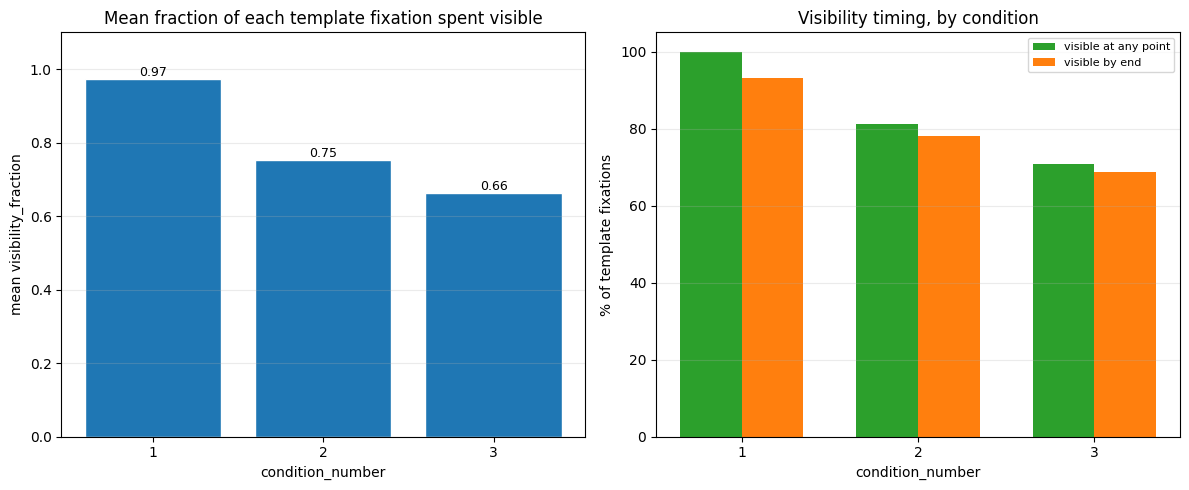

In [ ]:
visibility_summary = visibility_summary_by_condition(brick_fixation_events_df, naive_matches)
plot_visibility_by_condition(visibility_summary)

### 15.7.1 Visibility violations: does the flag behave correctly?

In [ ]:
#Checking for visiblitiy and brick fixations (are there any fixations on template bricks if the model is invisible)
template_runs = fixation_runs_df[fixation_runs_df['fixation_category'] == 'template']

violations_ever = template_runs[template_runs['visibility_ever'] == False]
violations_fraction = template_runs[template_runs['visibility_fraction'] == 0]

print(f'Template fixation runs total: {len(template_runs)}')
print(f'Runs where visibility_ever == False: {len(violations_ever)}')
print(f'Runs where visibility_fraction == 0: {len(violations_fraction)}')

if len(violations_ever):
    print(violations_ever[['participant_id', 'condition_number', 'trial_number',
                            'model_name', 'dominant_group', 'visibility_fraction']].head(10))

Template fixation runs total: 38324
Runs where visibility_ever == False: 6730
Runs where visibility_fraction == 0: 6730
     participant_id  condition_number  trial_number model_name dominant_group  \
1224            001                 2             1      C2M4A       temp_048   
1231            001                 2             1      C2M4A       temp_052   
1256            001                 2             1      C2M4A       temp_050   
1257            001                 2             1      C2M4A       temp_050   
1260            001                 2             1      C2M4A       temp_052   
1273            001                 2             1      C2M4A       temp_048   
1274            001                 2             1      C2M4A       temp_048   
1281            001                 2             1      C2M4A       temp_050   
1289            001                 2             1      C2M4A       temp_050   
1290            001                 2             1      C2M4A       t

In [ ]:
template_runs = fixation_runs_df[fixation_runs_df['fixation_category'] == 'template'].copy()

print('=== Violations by condition ===')
print(
    template_runs.groupby('condition_number')
    .agg(
        n_runs=('visibility_ever', 'size'),
        n_violations=('visibility_ever', lambda s: (~s.astype(bool)).sum()),
    )
    .assign(pct_violations=lambda d: (100 * d['n_violations'] / d['n_runs']).round(2))
)


=== Violations by condition ===
                  n_runs  n_violations  pct_violations
condition_number                                      
1                  10090             0            0.00
2                  14648          2773           18.93
3                  13586          3957           29.13


In [ ]:
print('\n=== Violation runs: duration distribution vs. valid runs ===')
print('Violations:', template_runs.loc[~template_runs['visibility_ever'].astype(bool), 'duration_ms'].describe())
print('\nNon-violations:', template_runs.loc[template_runs['visibility_ever'].astype(bool), 'duration_ms'].describe())

print('\n=== Violations by participant ===')
violation_by_pid = (
    template_runs[~template_runs['visibility_ever'].astype(bool)]
    .groupby('participant_id').size().sort_values(ascending=False)
)
print(violation_by_pid)



=== Violation runs: duration distribution vs. valid runs ===
Violations: count    6730.000000
mean      284.631055
std       282.018353
min        51.000000
25%       110.000000
50%       199.000000
75%       355.000000
max      4778.000000
Name: duration_ms, dtype: float64

Non-violations: count    31594.000000
mean       351.188802
std        389.346255
min         53.000000
25%        133.000000
50%        223.000000
75%        412.000000
max       7523.000000
Name: duration_ms, dtype: float64

=== Violations by participant ===
participant_id
004    496
037    455
031    304
012    286
001    283
050    266
034    256
014    213
042    201
039    200
044    200
033    171
002    157
009    156
038    156
027    155
025    141
007    139
015    131
028    122
018    119
011    117
040    108
020    106
047    103
006     95
021     94
030     93
026     91
048     89
049     87
035     84
051     84
010     82
029     81
008     80
032     79
045     76
043     60
017     57
005    

In [ ]:
def load_preprocessed_participant(participant_id: str) -> pd.DataFrame:
    """Reconstruct preprocessed data for ONE participant on demand, by
    reading their raw CSV and re-running the 6 preprocessing steps. Full
    preprocessed_data for ALL participants is never kept in memory (that
    caused the original memory crash) — this rebuilds it for a single
    participant only, cheaply and safely, for ad-hoc inspection."""
    participant_id = str(participant_id).zfill(3)
    csv_files = sorted(INPUT_FOLDER.glob('*.csv'))
    match = next((f for f in csv_files if participant_id_from_filename(f.name) == participant_id), None)
    if match is None:
        raise FileNotFoundError(f'No raw CSV found for participant {participant_id}')

    frame = pd.read_csv(match, low_memory=False)
    frame = frame.loc[:, ~frame.columns.duplicated()].copy()
    if 'source_file' not in frame.columns:
        frame['source_file'] = match.name
    if 'participant_id' not in frame.columns:
        frame['participant_id'] = participant_id_from_filename(match.name)
    frame['participant_id'] = frame['participant_id'].astype('string').str.zfill(3)

    data = exclude_participants(frame, PARTICIPANT_IDS_TO_EXCLUDE)
    del frame
    data = remove_condition0(data)
    data = remove_specific_models_per_participant(data, MODEL_EXCLUSION_EXCEL, MODEL_EXCLUSION_SHEET)
    data = remove_non_building_models(data)
    data = swap_xz_columns(data)
    data = tech_obj_renaming(data)
    return data

In [ ]:
def verify_no_template_hits_while_invisible(participant_id: str) -> pd.DataFrame:
    """Sample-level check: every raw gaze sample whose raycast hit a
    template brick (hit_obj_group starts with 'temp_'), cross-referenced
    against model_visibility_state at that exact sample. Any row with
    model_visibility_state == False is a genuine violation — the
    raycast registered a hit on something that shouldn't have been
    visible/renderable at that moment."""
    raw = load_preprocessed_participant(participant_id)
    raw = prepare_fixation_sample_columns(raw)

    if 'model_visibility_state' not in raw.columns:
        raise KeyError('model_visibility_state not in raw data for this participant.')

    template_hits = raw[raw['hit_obj_group'].astype(str).str.startswith('temp_', na=False)]
    violations = template_hits[~template_hits['model_visibility_state'].astype(bool)]

    print(f'Participant {participant_id}: {len(template_hits)} template-hit samples, '
          f'{len(violations)} while model_visibility_state was False')
    return violations


# Spot-check a few participants first (full reload is slower, one at a time)
for pid in ['001', '002', '003']:
    violations = verify_no_template_hits_while_invisible(pid)
    if len(violations):
        print(violations[['condition_number', 'trial_number', 'raw_timestamp', 'hit_obj_name']].head())

Excluded participants found and removed: []
[remove_condition0] Removed 93486 rows (condition 0). Remaining: 553478
[model_exclusion] Removed 0 rows via participant/model exclusions.
[remove_non_building_models] Removed 199096 rows (TM/None). Remaining: 354382
[swap_xz_columns] Variables processed: 36 | Actually swapped: 36 | Columns: 141 -> 141
[tech_obj_renaming] Processed object columns: 1
Participant 001: 83315 template-hit samples, 25659 while model_visibility_state was False
        condition_number  trial_number  raw_timestamp  \
293917                 2             1  1778061800180   
293918                 2             1  1778061800192   
293919                 2             1  1778061800192   
293920                 2             1  1778061800192   
293921                 2             1  1778061800202   

                    hit_obj_name  
293917   brick_2x4_pink_temp_047  
293918  brick_2x4_green_temp_048  
293919  brick_2x4_green_temp_048  
293920  brick_2x4_green_temp_04

## 15.8 Appendix demo — grab-classification QA + robustness check

Runs the Section 14 appendix functions once, so their output is visible
without needing a separate pass over the notebook.

In [ ]:
grasp_events = add_grasp_type_detailed(grasp_events)
by_participant_unclassified = unclassified_brick_by_participant(grasp_events)
print(by_participant_unclassified.to_string(index=False))


In [ ]:
naive_matches_visible_c = add_complexity(naive_matches_visible_only)

In [ ]:
_ = plot_match_rate_by_category(naive_matches_visible_c, 'condition_number', 'condition_number', 'match_rate_by_condition_category_visible_only.png')
_ = plot_match_rate_by_category(naive_matches_visible_c, 'complexity', 'complexity', 'match_rate_by_complexity_category_visible_only.png')

In [ ]:
naive_groups_visible_c = naive_matches_visible_c.drop_duplicates(subset=TRIAL_GROUP_COLS + ['grab_group_id'])

counts_cat_x_v, pct_total_cat_x_v, pct_within_cat_x_v = counts_and_pct_table(naive_groups_visible_c, ['complexity', 'group_category'])
print('=== group_category by complexity (VISIBLE_ONLY): counts ===')
print(counts_cat_x_v)
print('\n=== group_category by complexity (VISIBLE_ONLY): % within complexity ===')
print(pct_within_cat_x_v)

plot_grouped_bar(
    counts_cat_x_v.drop(index='total', errors='ignore').drop(columns='total', errors='ignore'),
    'complexity', 'number of grab groups (events)', 'group_category counts by complexity (VISIBLE_ONLY)',
    'group_category', 'group_category_by_complexity_visible_only.png',
)
plot_stacked_pct_bar(
    pct_within_cat_x_v, 'complexity', '% of events within complexity',
    'group_category share, within each complexity level (VISIBLE_ONLY)', 'group_category', 'group_category_by_complexity_pct_visible_only.png',
)